In [ ]:
"""
Task 1.1: Environment Setup & Data Collection
Purpose: Install required packages and download LIAR dataset files
"""

# Install required packages
print("=" * 60)
print("Installing Required Packages")
print("=" *0)

!pip install -q wordcloud textblob nltk scikit-learn pandas numpy matplotlib seaborn tensorflow

# Download NLTK data
import nltk
print("\nDownloading NLTK resources...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print("\n✓ All packages installed successfully")
print("=" * 60)

Installing Required Packages



✓ All packages installed successfully


In [ ]:
"""
Download LIAR Dataset Files (Official Source)
Downloads the ZIP file and extracts: train.tsv, valid.tsv, test.tsv
"""

print("\n" + "=" * 60)
print("Downloading and Extracting LIAR Dataset")
print("=" * 60)

import requests
import os
import zipfile

# Official source URL
url = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
zip_filename = "liar_dataset.zip"

# Download the ZIP file
if not os.path.exists(zip_filename):
    print(f"Downloading {zip_filename}...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes

        with open(zip_filename, 'wb') as f:
            f.write(response.content)
        print(f"✓ {zip_filename} downloaded")
    except Exception as e:
        print(f"Error downloading: {e}")
else:
    print(f"✓ {zip_filename} already exists")

# Extract the files
print("Extracting files...")
try:
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✓ Extraction complete")
except zipfile.BadZipFile:
    print("Error: The downloaded file is not a valid zip file.")

print("\n✓ Dataset setup complete")
print("=" * 60)


✓ liar_dataset.zip already exists
Extracting files...
✓ Extraction complete

✓ Dataset setup complete


In [ ]:
"""
Task 1.2: Data Loading & Initial Inspection
Purpose: Load the three TSV files, merge them, and create a unified dataset
"""

import pandas as pd
import numpy as np
from pathlib import Path

# Define column names for LIAR dataset
LIAR_COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker',
    'speaker_job', 'state', 'party',
    'barely_true_counts', 'false_counts', 'half_true_counts',
    'mostly_true_counts', 'pants_on_fire_counts', 'context'
]

def load_liar_file(file_path):
    """
    Load a single LIAR TSV file

    Parameters:
        file_path (str): Path to the TSV file

    Returns:
        pd.DataFrame: Loaded dataframe with proper column names
    """
    # Check if file exists
    if not Path(file_path).exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    # Read TSV file
    df = pd.read_csv(
        file_path,
        sep='\t',
        header=None,
        names=LIAR_COLUMNS,
        encoding='utf-8'
    )

    return df


def merge_and_prepare_dataset(train_path='train.tsv',
                               valid_path='valid.tsv',
                               test_path='test.tsv'):
    """
    Load all three splits and merge them into one dataset
    IMPORTANT: We merge first, then will create our own random split later

    Parameters:
        train_path (str): Path to training data
        valid_path (str): Path to validation data
        test_path (str): Path to test data

    Returns:
        pd.DataFrame: Merged dataset with original split tracked
    """
    print("\n" + "=" * 60)
    print("PHASE 1: DATA PREPARATION & CLEANING")
    print("=" * 60)

    print("\n[Task 1.2] Loading Data Files...")

    # Load each split
    train_df = load_liar_file(train_path)
    valid_df = load_liar_file(valid_path)
    test_df = load_liar_file(test_path)

    # Track original split (for reference only - we'll create new splits later)
    train_df['original_split'] = 'train'
    valid_df['original_split'] = 'valid'
    test_df['original_split'] = 'test'

    # Merge all data
    merged_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

    # Display basic information
    print(f"\nDataset Sizes:")
    print(f"  Train: {len(train_df):,} samples")
    print(f"  Valid: {len(valid_df):,} samples")
    print(f"  Test:  {len(test_df):,} samples")
    print(f"  Total: {len(merged_df):,} samples")

    print(f"\nDataset Shape: {merged_df.shape}")
    print(f"Columns: {list(merged_df.columns)}")

    # Show first few rows
    print("\nFirst 3 rows:")
    print(merged_df.head(3))

    # Check for missing values
    print("\nMissing Values:")
    missing_counts = merged_df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0]
    if len(missing_counts) > 0:
        print(missing_counts)
    else:
        print("  No missing values detected")

    # Save merged dataset
    merged_df.to_csv('liar_merged.csv', index=False, encoding='utf-8')
    print("\n✓ Merged dataset saved: liar_merged.csv")

    return merged_df


# Execute data loading
df_merged = merge_and_prepare_dataset()


PHASE 1: DATA PREPARATION & CLEANING

[Task 1.2] Loading Data Files...

Dataset Sizes:
  Train: 10,240 samples
  Valid: 1,284 samples
  Test:  1,267 samples
  Total: 12,791 samples

Dataset Shape: (12791, 15)
Columns: ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'original_split']

First 3 rows:
           id        label                                          statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   

                              subject         speaker           speaker_job  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State

In [ ]:
"""
Analyze Feature Distributions
Purpose: Understand the unique values in each categorical column
"""

from collections import Counter

def analyze_feature_distributions(df):
    """
    Analyze and save unique value counts for each feature
    Creates separate CSV files for each feature's distribution

    Parameters:
        df (pd.DataFrame): Input dataframe
    """
    print("\n[Task 1.2] Analyzing Feature Distributions...")

    # Create output directory
    output_dir = Path('feature_frequencies')
    output_dir.mkdir(exist_ok=True)

    # Features to exclude (unique identifiers or text)
    exclude_features = ['id', 'statement', 'original_split']

    all_results = []

    for column in df.columns:
        if column in exclude_features:
            continue

        # Special handling for 'subject' (contains comma-separated values)
        if column == 'subject':
            print(f"\nProcessing '{column}' (extracting individual subjects)...")

            # Extract all individual subjects
            all_subjects = []
            for value in df[column].dropna():
                if pd.notna(value):
                    subjects = [s.strip() for s in str(value).split(',')]
                    all_subjects.extend(subjects)

            # Count frequencies
            subject_counts = Counter(all_subjects)

            # Create DataFrame
            feature_df = pd.DataFrame([
                {'value': subj, 'count': cnt}
                for subj, cnt in subject_counts.most_common()
            ])

            # Save to CSV
            csv_path = output_dir / f'{column}_frequencies.csv'
            feature_df.to_csv(csv_path, index=False, encoding='utf-8')
            print(f"  ✓ Saved {len(feature_df)} unique subjects to {csv_path}")

            # Add to combined results
            for subj, cnt in subject_counts.items():
                all_results.append({
                    'column': column,
                    'value': subj,
                    'count': cnt
                })

        else:
            # Standard value counting for other columns
            value_counts = df[column].value_counts(dropna=False)

            # Create DataFrame
            feature_rows = []
            for value, count in value_counts.items():
                # Handle NA values
                if pd.isna(value):
                    value_str = '<NA>'
                else:
                    value_str = str(value)

                feature_rows.append({'value': value_str, 'count': int(count)})
                all_results.append({
                    'column': column,
                    'value': value_str,
                    'count': int(count)
                })

            # Save to CSV
            feature_df = pd.DataFrame(feature_rows)
            csv_path = output_dir / f'{column}_frequencies.csv'
            feature_df.to_csv(csv_path, index=False, encoding='utf-8')
            print(f"  ✓ Saved {len(feature_df)} unique values for '{column}' to {csv_path}")

    # Save combined results
    combined_df = pd.DataFrame(all_results)
    combined_df.to_csv('unique_values_counts.csv', index=False, encoding='utf-8')

    print(f"\n✓ Feature distribution analysis complete")
    print(f"  - Individual feature CSVs: {output_dir}/")
    print(f"  - Combined results: unique_values_counts.csv")


# Execute feature distribution analysis
analyze_feature_distributions(df_merged)


[Task 1.2] Analyzing Feature Distributions...
  ✓ Saved 6 unique values for 'label' to feature_frequencies/label_frequencies.csv

Processing 'subject' (extracting individual subjects)...
  ✓ Saved 144 unique subjects to feature_frequencies/subject_frequencies.csv
  ✓ Saved 3310 unique values for 'speaker' to feature_frequencies/speaker_frequencies.csv
  ✓ Saved 1355 unique values for 'speaker_job' to feature_frequencies/speaker_job_frequencies.csv
  ✓ Saved 85 unique values for 'state' to feature_frequencies/state_frequencies.csv
  ✓ Saved 25 unique values for 'party' to feature_frequencies/party_frequencies.csv
  ✓ Saved 31 unique values for 'barely_true_counts' to feature_frequencies/barely_true_counts_frequencies.csv
  ✓ Saved 31 unique values for 'false_counts' to feature_frequencies/false_counts_frequencies.csv
  ✓ Saved 30 unique values for 'half_true_counts' to feature_frequencies/half_true_counts_frequencies.csv
  ✓ Saved 28 unique values for 'mostly_true_counts' to feature_fr

In [ ]:
"""
Task 1.3: Data Cleaning
Purpose: Handle missing values, duplicates, outliers, and text cleaning
"""

def handle_missing_values(df):
    """
    Handle missing values in the dataset
    Strategy: Fill categorical with 'unknown', numerical with 0

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with missing values handled
    """
    print("\n[Task 1.3.1] Handling Missing Values...")

    df_clean = df.copy()

    # Convert object columns to string and strip whitespace
    for col in df_clean.columns:
        if df_clean[col].dtype == object or pd.api.types.is_string_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].astype('string').str.strip()
            # Replace empty strings with NA
            df_clean[col] = df_clean[col].replace('', pd.NA)

    # Define fill values for categorical features
    categorical_fills = {
        'subject': 'unknown',
        'speaker': 'unknown',
        'speaker_job': 'unknown',
        'state': 'unknown',
        'party': 'none',
        'context': 'unknown'
    }

    # Fill categorical columns
    for col, fill_value in categorical_fills.items():
        if col in df_clean.columns:
            missing_count = df_clean[col].isna().sum()
            if missing_count > 0:
                df_clean[col] = df_clean[col].fillna(fill_value)
                print(f"  ✓ Filled {missing_count} missing values in '{col}' with '{fill_value}'")

    # Fill numerical columns (credit history counts)
    count_columns = [
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts'
    ]

    for col in count_columns:
        if col in df_clean.columns:
            missing_count = df_clean[col].isna().sum()
            if missing_count > 0:
                df_clean[col] = df_clean[col].fillna(0)
                print(f"  ✓ Filled {missing_count} missing values in '{col}' with 0")

    # Check remaining nulls
    remaining_nulls = df_clean.isna().sum().sum()
    print(f"\n  Remaining missing values: {remaining_nulls}")

    return df_clean


def remove_duplicates(df):
    """
    Remove duplicate statements from the dataset

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with duplicates removed
    """
    print("\n[Task 1.3.2] Checking for Duplicates...")

    # Check for duplicate IDs
    duplicate_ids = df['id'].duplicated().sum()
    print(f"  Duplicate IDs: {duplicate_ids}")

    # Check for duplicate statements
    duplicate_statements = df['statement'].duplicated().sum()
    print(f"  Duplicate statements: {duplicate_statements}")

    if duplicate_statements > 0:
        # Remove duplicates, keeping first occurrence
        df_no_dup = df.drop_duplicates(subset=['statement'], keep='first')
        removed_count = len(df) - len(df_no_dup)
        print(f"  ✓ Removed {removed_count} duplicate statements")
        return df_no_dup
    else:
        print("  ✓ No duplicates found")
        return df


def analyze_outliers(df):
    """
    Analyze outliers in statement length
    Note: We don't remove outliers, just identify them

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with statement_length column added
    """
    print("\n[Task 1.3.3] Analyzing Statement Length Outliers...")

    df_copy = df.copy()

    # Calculate statement length
    df_copy['statement_length'] = df_copy['statement'].str.len()

    # Calculate IQR
    q1 = df_copy['statement_length'].quantile(0.25)
    q3 = df_copy['statement_length'].quantile(0.75)
    iqr = q3 - q1

    # Calculate bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Find outliers
    outliers = df_copy[
        (df_copy['statement_length'] < lower_bound) |
        (df_copy['statement_length'] > upper_bound)
    ]

    # Display statistics
    print(f"  Statement Length Statistics:")
    print(f"    Min: {df_copy['statement_length'].min()}")
    print(f"    Q1: {q1:.0f}")
    print(f"    Median: {df_copy['statement_length'].median():.0f}")
    print(f"    Q3: {q3:.0f}")
    print(f"    Max: {df_copy['statement_length'].max()}")
    print(f"    IQR: {iqr:.0f}")
    print(f"\n  Outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
    print(f"  Outliers found: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  ✓ Keeping all data (outliers are valid statements)")

    return df_copy


def clean_text(df):
    """
    Clean text in statement column
    - Remove URLs
    - Remove special characters (keep basic punctuation)
    - Normalize whitespace

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with cleaned text
    """
    print("\n[Task 1.3.4] Cleaning Text...")

    df_clean = df.copy()

    # Remove URLs
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    df_clean['statement'] = df_clean['statement'].str.replace(url_pattern, '', regex=True)

    # Remove special characters (keep letters, numbers, and basic punctuation)
    special_char_pattern = r'[^\w\s\.,!?\'-]'
    df_clean['statement'] = df_clean['statement'].str.replace(special_char_pattern, '', regex=True)

    # Normalize whitespace
    df_clean['statement'] = df_clean['statement'].str.replace(r'\s+', ' ', regex=True).str.strip()

    print("  ✓ Removed URLs and special characters")
    print("  ✓ Normalized whitespace")

    return df_clean


def normalize_text_globally(df):
    """
    Normalize text across the entire dataset
    - Convert all text to lowercase (GLOBAL standardization)
    - Remove accents from speaker names
    - Standardize state codes

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with normalized text
    """
    import unicodedata

    print("\n[Task 1.3.5] Normalizing Text (Global Lowercasing)...")

    df_norm = df.copy()

    # Helper function to remove accents
    def remove_accents(text):
        if pd.isna(text):
            return text
        nfd = unicodedata.normalize('NFD', str(text))
        return ''.join(char for char in nfd if unicodedata.category(char) != 'Mn')

    # Lowercase text columns (GLOBAL)
    text_columns = ['label', 'statement', 'subject', 'speaker',
                   'speaker_job', 'party', 'context']

    for col in text_columns:
        if col in df_norm.columns:
            df_norm[col] = df_norm[col].str.lower()

    # Remove accents from speaker names
    if 'speaker' in df_norm.columns:
        df_norm['speaker'] = df_norm['speaker'].apply(remove_accents)

    # Standardize state codes (uppercase if 2 chars, lowercase if longer)
    if 'state' in df_norm.columns:
        df_norm['state'] = df_norm['state'].str.strip()
        is_code = df_norm['state'].str.len() <= 2
        df_norm.loc[is_code, 'state'] = df_norm.loc[is_code, 'state'].str.upper()
        df_norm.loc[~is_code, 'state'] = df_norm.loc[~is_code, 'state'].str.lower()

    print("  ✓ Converted all text to lowercase")
    print("  ✓ Removed accents from speaker names")
    print("  ✓ Standardized state codes")

    return df_norm


def save_cleaned_data(df, filename='liar_preprocessed.csv'):
    """
    Save cleaned dataframe to CSV

    Parameters:
        df (pd.DataFrame): Cleaned dataframe
        filename (str): Output filename
    """
    df.to_csv(filename, index=False, encoding='utf-8')
    print(f"\n✓ Cleaned data saved: {filename}")


# Execute all cleaning steps
df_clean = handle_missing_values(df_merged)
df_clean = remove_duplicates(df_clean)
df_clean = analyze_outliers(df_clean)
df_clean = clean_text(df_clean)
df_clean = normalize_text_globally(df_clean)

# Save cleaned data
save_cleaned_data(df_clean)

print("\n" + "=" * 60)
print("DATA CLEANING COMPLETE")
print("=" * 60)
print(f"Final dataset shape: {df_clean.shape}")


[Task 1.3.1] Handling Missing Values...
  ✓ Filled 2 missing values in 'subject' with 'unknown'
  ✓ Filled 2 missing values in 'speaker' with 'unknown'
  ✓ Filled 3568 missing values in 'speaker_job' with 'unknown'
  ✓ Filled 2751 missing values in 'state' with 'unknown'
  ✓ Filled 2 missing values in 'party' with 'none'
  ✓ Filled 131 missing values in 'context' with 'unknown'
  ✓ Filled 2 missing values in 'barely_true_counts' with 0
  ✓ Filled 2 missing values in 'false_counts' with 0
  ✓ Filled 2 missing values in 'half_true_counts' with 0
  ✓ Filled 2 missing values in 'mostly_true_counts' with 0
  ✓ Filled 2 missing values in 'pants_on_fire_counts' with 0

  Remaining missing values: 0

[Task 1.3.2] Checking for Duplicates...
  Duplicate IDs: 0
  Duplicate statements: 26
  ✓ Removed 26 duplicate statements

[Task 1.3.3] Analyzing Statement Length Outliers...
  Statement Length Statistics:
    Min: 11
    Q1: 73
    Median: 99
    Q3: 133
    Max: 3192
    IQR: 60

  Outlier boun

In [ ]:
"""
Task 2.1: Statistical Analysis
Purpose: Compute statistical summaries and save results
"""

import pandas as pd
import numpy as np

def compute_label_distribution(df):
    """
    Analyze label distribution

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Label distribution statistics
    """
    print("\n[Task 2.1.1] Label Distribution:")

    label_counts = df['label'].value_counts()
    label_percentages = (df['label'].value_counts(normalize=True) * 100).round(2)

    label_dist = pd.DataFrame({
        'count': label_counts,
        'percentage': label_percentages
    })

    print(label_dist)

    # Save to CSV
    label_dist.to_csv('stats_label_distribution.csv')
    print("  ✓ Saved: stats_label_distribution.csv")

    return label_dist


def compute_speaker_distribution(df):
    """
    Analyze speaker distribution (top 20)

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.Series: Top 20 speaker counts
    """
    print("\n[Task 2.1.2] Speaker Distribution (Top 20):")

    speaker_dist = df['speaker'].value_counts().head(20)
    print(speaker_dist.head(10))

    # Save to CSV
    speaker_dist.to_csv('stats_speaker_distribution.csv', header=['count'])
    print("  ✓ Saved: stats_speaker_distribution.csv")

    return speaker_dist


def compute_party_distribution(df):
    """
    Analyze party affiliation distribution

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Party distribution statistics
    """
    print("\n[Task 2.1.3] Party Distribution:")

    party_counts = df['party'].value_counts()
    party_percentages = (df['party'].value_counts(normalize=True) * 100).round(2)

    party_dist = pd.DataFrame({
        'count': party_counts,
        'percentage': party_percentages
    })

    print(party_dist)

    # Save to CSV
    party_dist.to_csv('stats_party_distribution.csv')
    print("  ✓ Saved: stats_party_distribution.csv")

    return party_dist


def compute_credit_history_stats(df):
    """
    Analyze credit history count columns

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Credit history statistics
    """
    print("\n[Task 2.1.4] Credit History Statistics:")

    count_cols = ['barely_true_counts', 'false_counts', 'half_true_counts',
                  'mostly_true_counts', 'pants_on_fire_counts']

    summary_stats = df[count_cols].describe()
    print(summary_stats)

    # Save to CSV
    summary_stats.to_csv('stats_credit_history.csv')
    print("  ✓ Saved: stats_credit_history.csv")

    return summary_stats


def compute_statement_length_stats(df):
    """
    Analyze statement length statistics

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Statement length statistics
    """
    print("\n[Task 2.1.5] Statement Length Statistics:")

    if 'statement_length' not in df.columns:
        df['statement_length'] = df['statement'].str.len()

    stats = df['statement_length'].describe()

    stmt_stats = pd.DataFrame({
        'metric': ['min', 'max', 'mean', 'median'],
        'value': [stats['min'], stats['max'], stats['mean'], stats['50%']]
    })

    print(stmt_stats)

    # Save to CSV
    stmt_stats.to_csv('stats_statement_length.csv', index=False)
    print("  ✓ Saved: stats_statement_length.csv")

    return stmt_stats


def compute_correlation_matrix(df):
    """
    Compute correlation matrix for credit history counts

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Correlation matrix
    """
    print("\n[Task 2.1.6] Correlation Matrix:")

    count_cols = ['barely_true_counts', 'false_counts', 'half_true_counts',
                  'mostly_true_counts', 'pants_on_fire_counts']

    corr_matrix = df[count_cols].corr()
    print(corr_matrix.round(3))

    # Save to CSV
    corr_matrix.to_csv('stats_correlation_matrix.csv')
    print("  ✓ Saved: stats_correlation_matrix.csv")

    return corr_matrix


# Execute all statistical analyses
print("\n" + "=" * 60)
print("PHASE 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print("\n[Task 2.1] Statistical Analysis")

label_dist = compute_label_distribution(df_clean)
speaker_dist = compute_speaker_distribution(df_clean)
party_dist = compute_party_distribution(df_clean)
credit_stats = compute_credit_history_stats(df_clean)
stmt_stats = compute_statement_length_stats(df_clean)
corr_matrix = compute_correlation_matrix(df_clean)

print("\n✓ Statistical analysis complete")


PHASE 2: EXPLORATORY DATA ANALYSIS

[Task 2.1] Statistical Analysis

[Task 2.1.1] Label Distribution:
             count  percentage
label                         
half-true     2621       20.53
false         2493       19.53
mostly-true   2452       19.21
barely-true   2102       16.47
true          2050       16.06
pants-fire    1047         8.2
  ✓ Saved: stats_label_distribution.csv

[Task 2.1.2] Speaker Distribution (Top 20):
speaker
barack-obama       608
donald-trump       343
hillary-clinton    296
mitt-romney        212
john-mccain        188
scott-walker       182
chain-email        178
rick-perry         172
marco-rubio        153
rick-scott         150
Name: count, dtype: int64
  ✓ Saved: stats_speaker_distribution.csv

[Task 2.1.3] Party Distribution:
                              count  percentage
party                                          
republican                     5646       44.23
democrat                       4130       32.35
none                           2


[Task 2.2] Creating Visualizations...
  Creating label distribution plot...


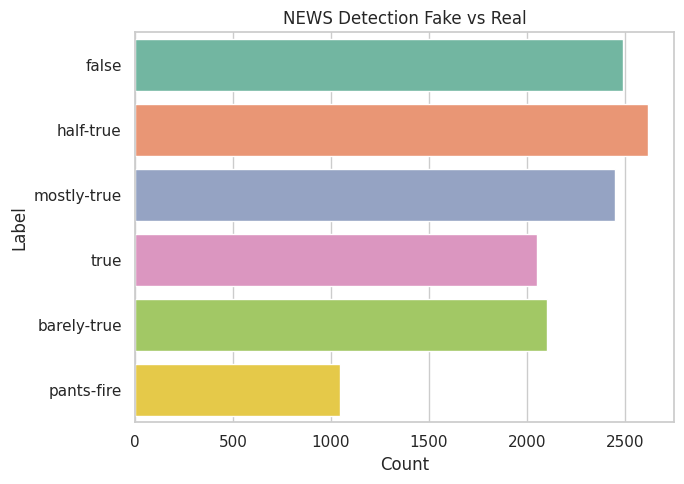

  Creating top speakers plot...


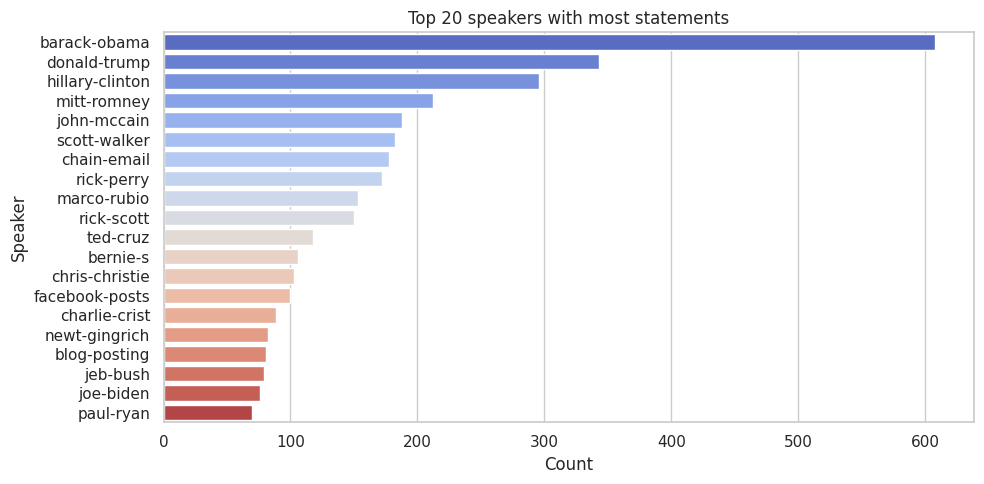

  Creating party distribution plot...


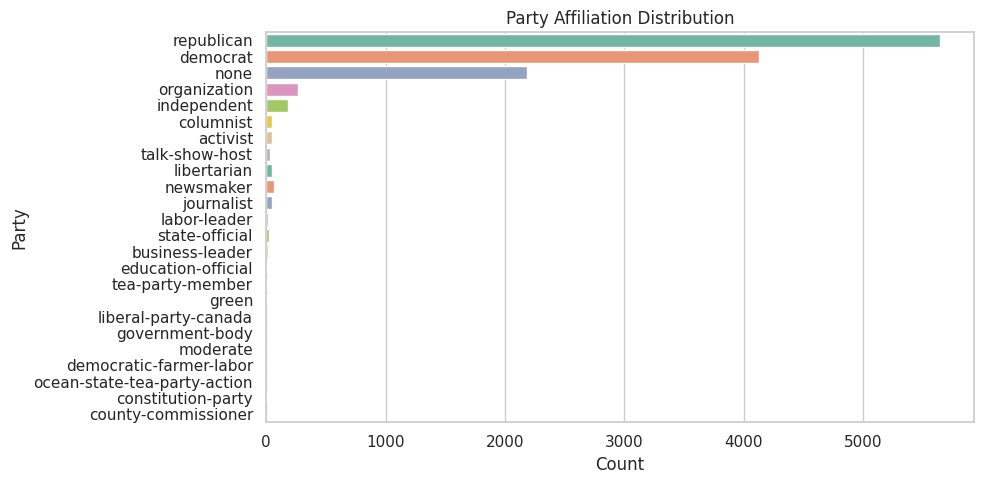

  Creating subject distribution plot...


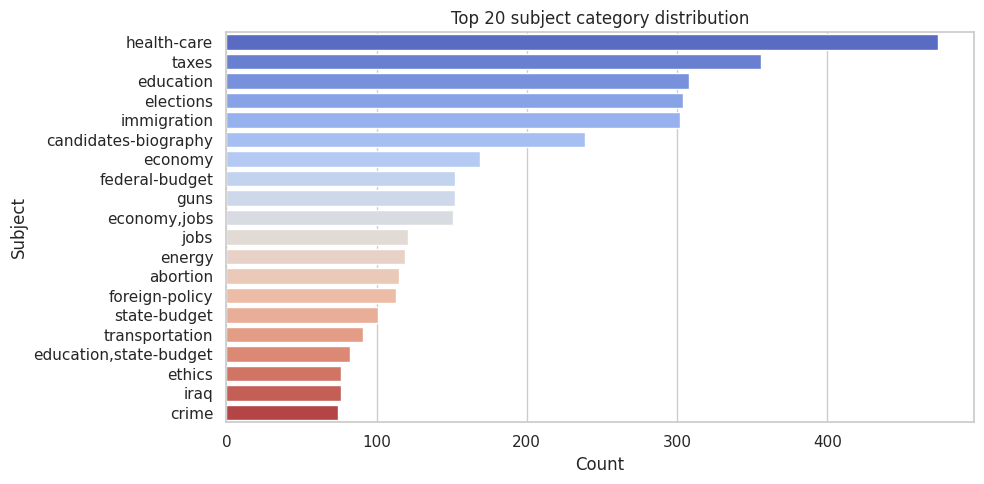

  Creating statement length distribution...


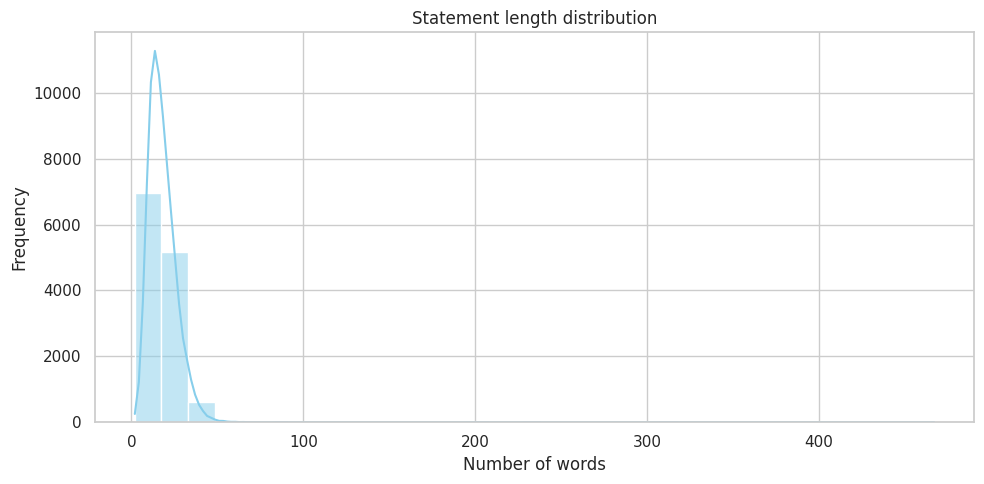

  Creating credit history distribution...


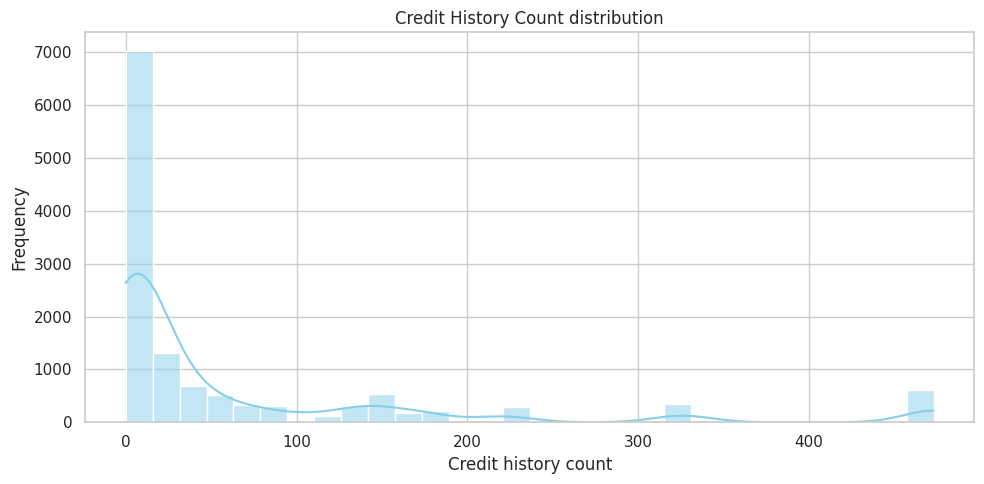

  Creating statement length by label boxplot...


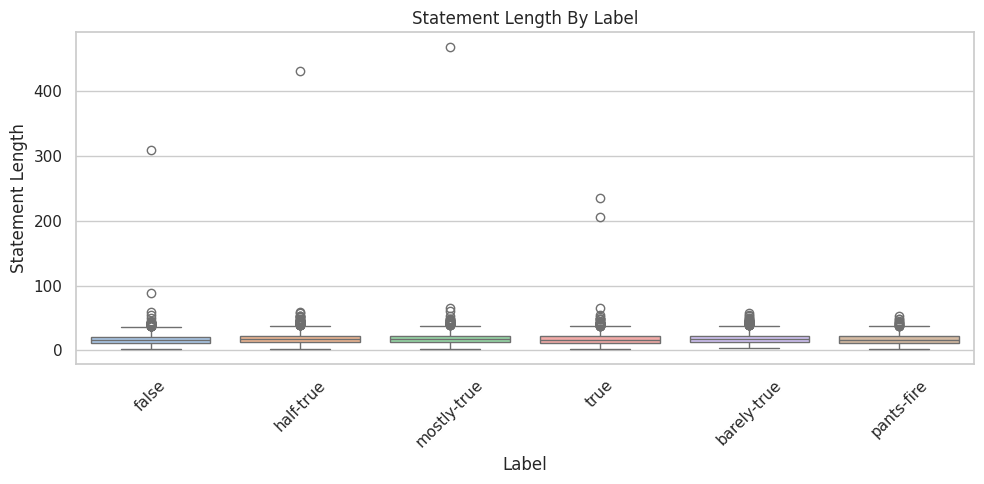

  Creating credit history by label boxplot...


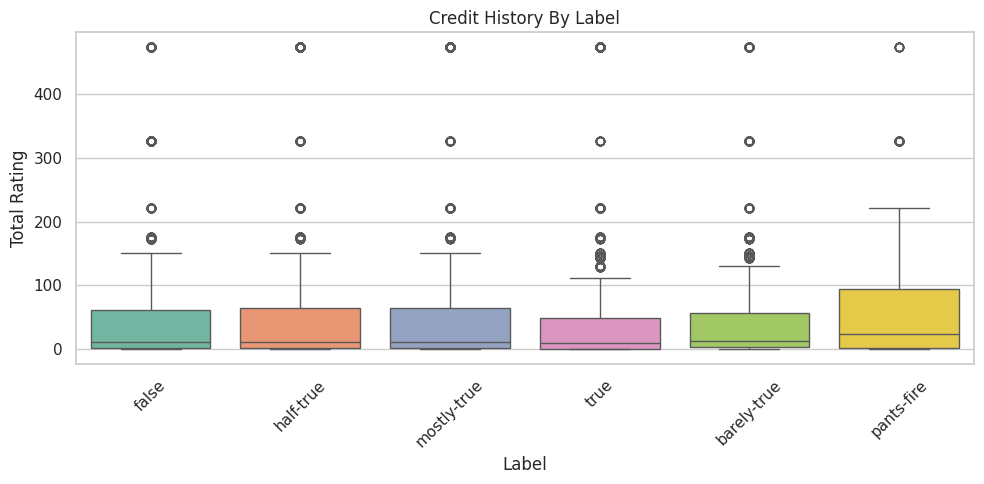

  Creating statement length vs credibility scatter plot...


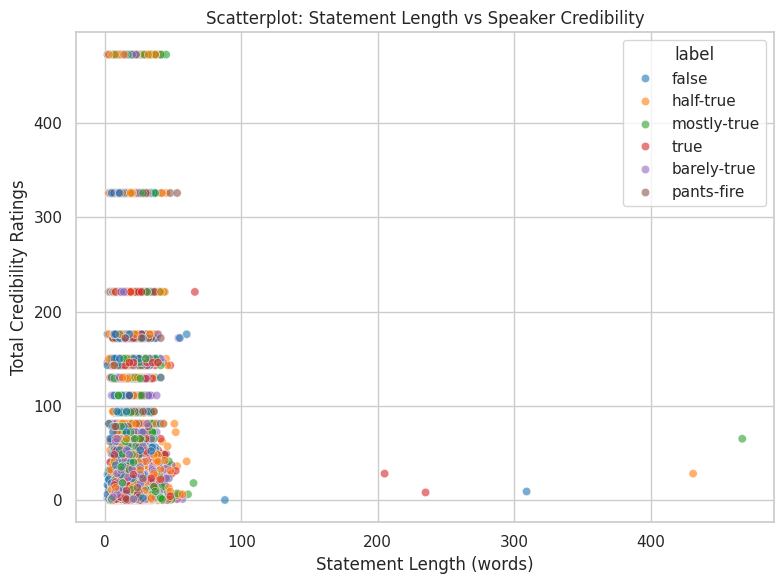

  Creating false vs pants-on-fire scatter plot...


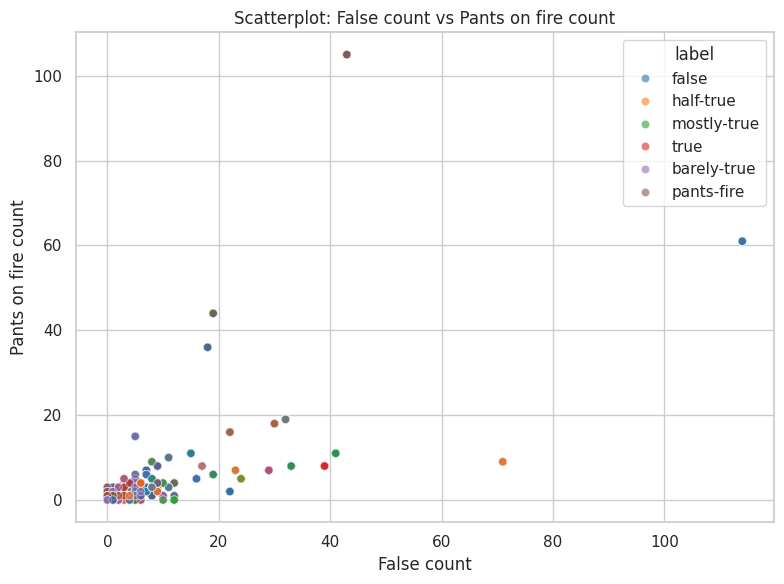

  Creating word clouds for each label...


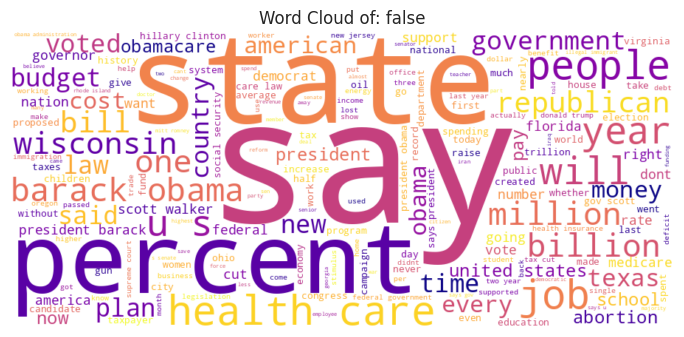

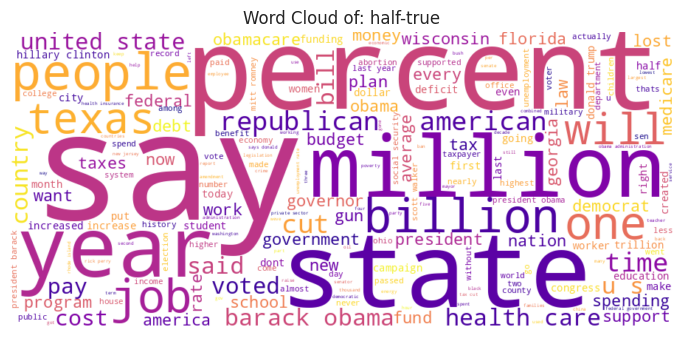

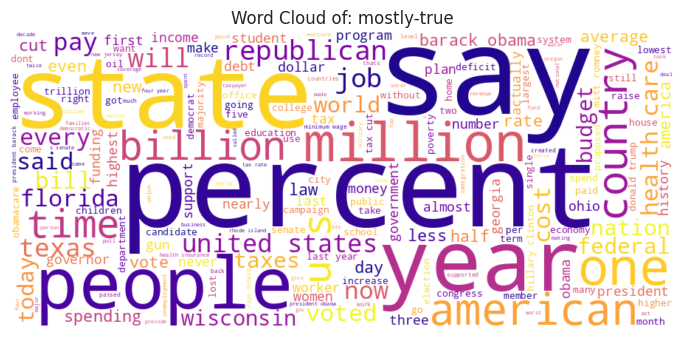

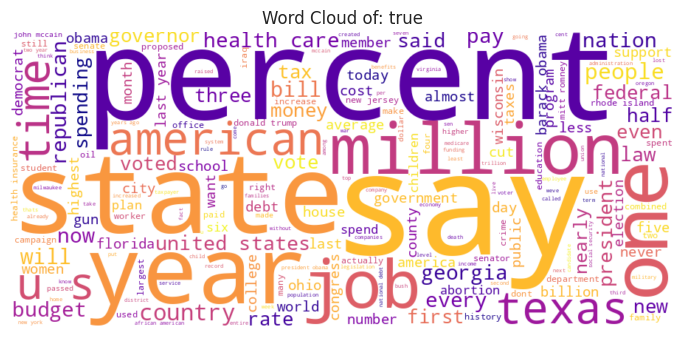

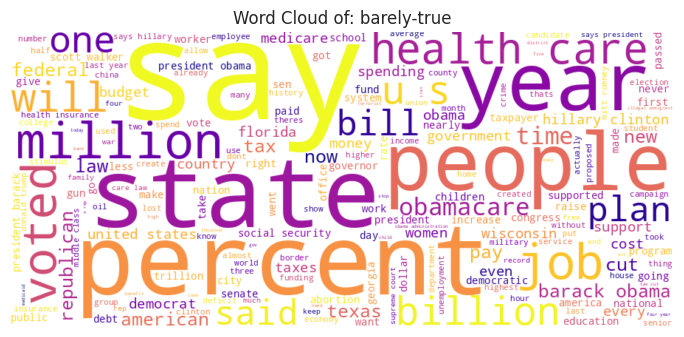

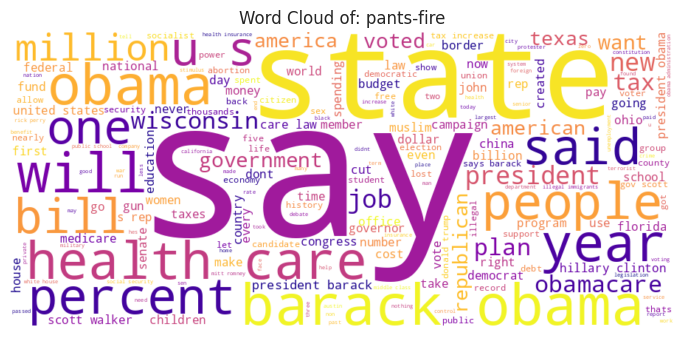

  Creating correlation heatmap...


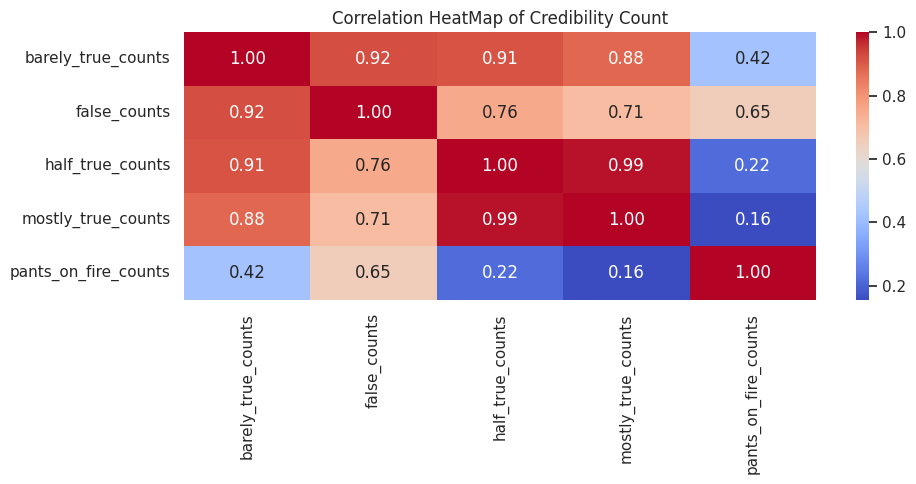


  Creating enhanced EDA visualizations...
  Creating enhanced label distribution...


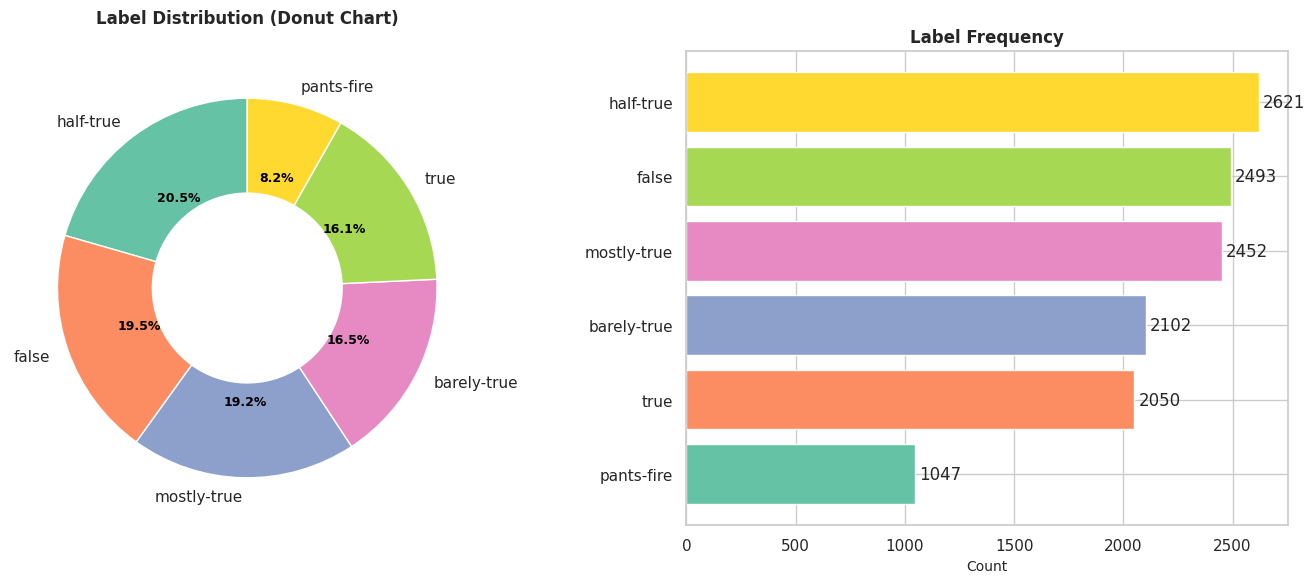

  Creating lollipop chart for speakers...


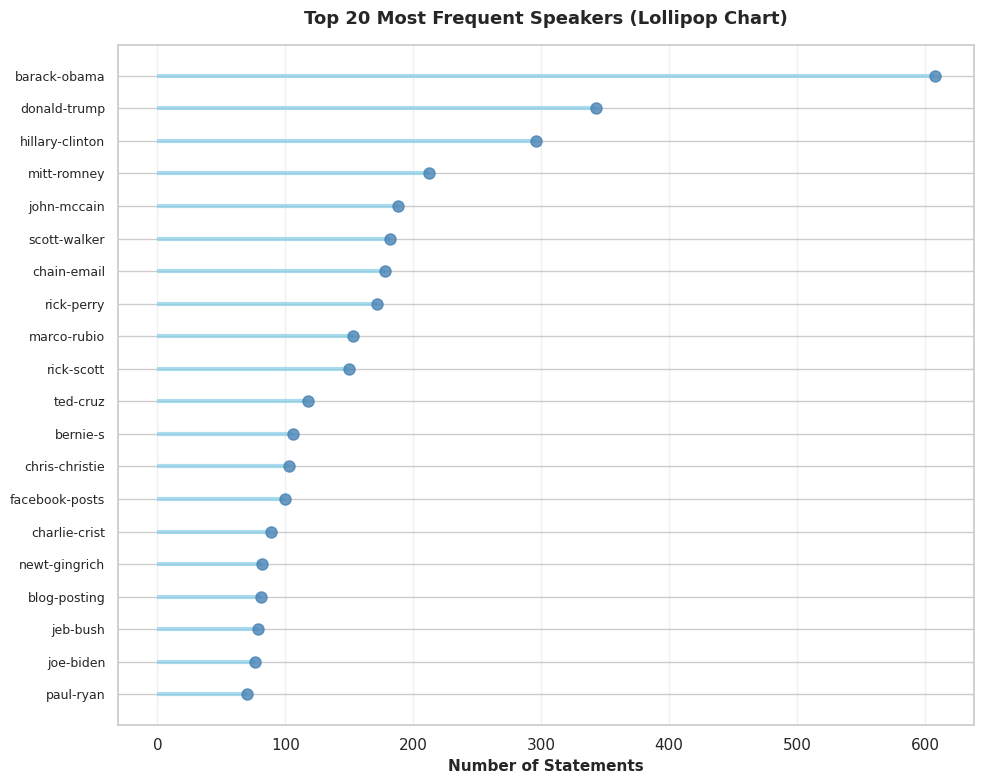

  Creating individual subject distribution...


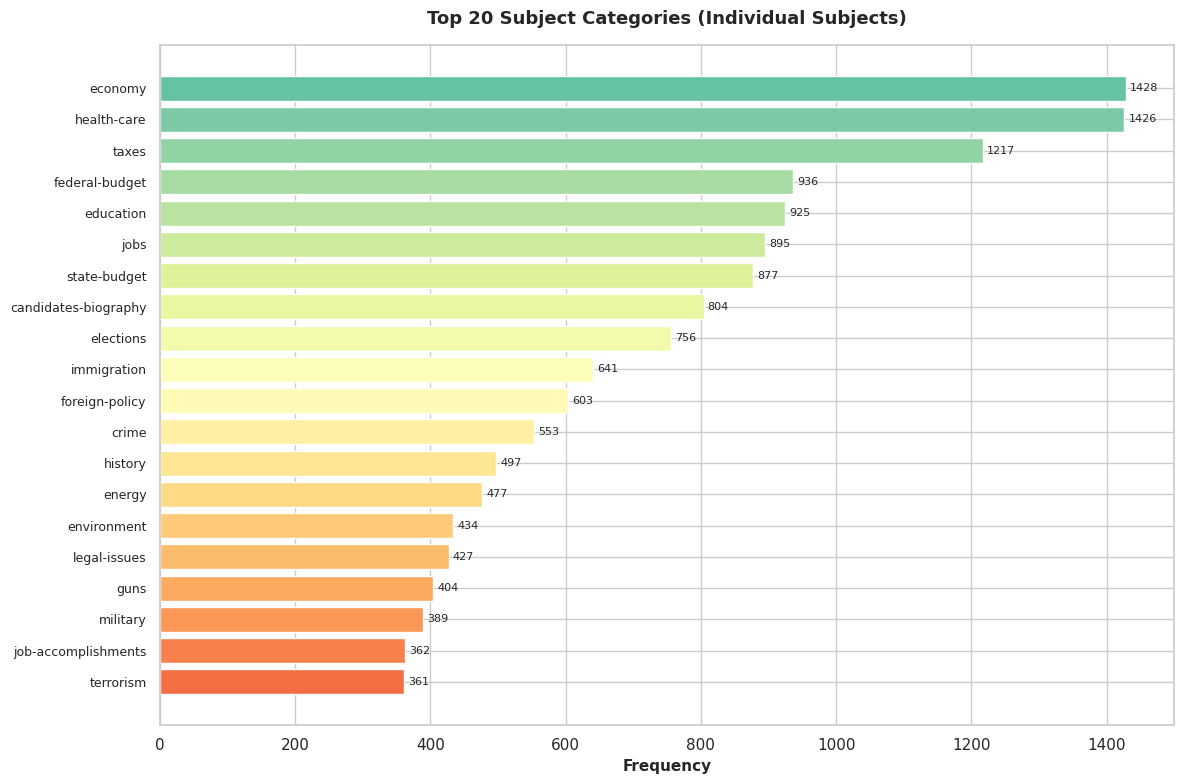

  Creating polar chart for speaker jobs...


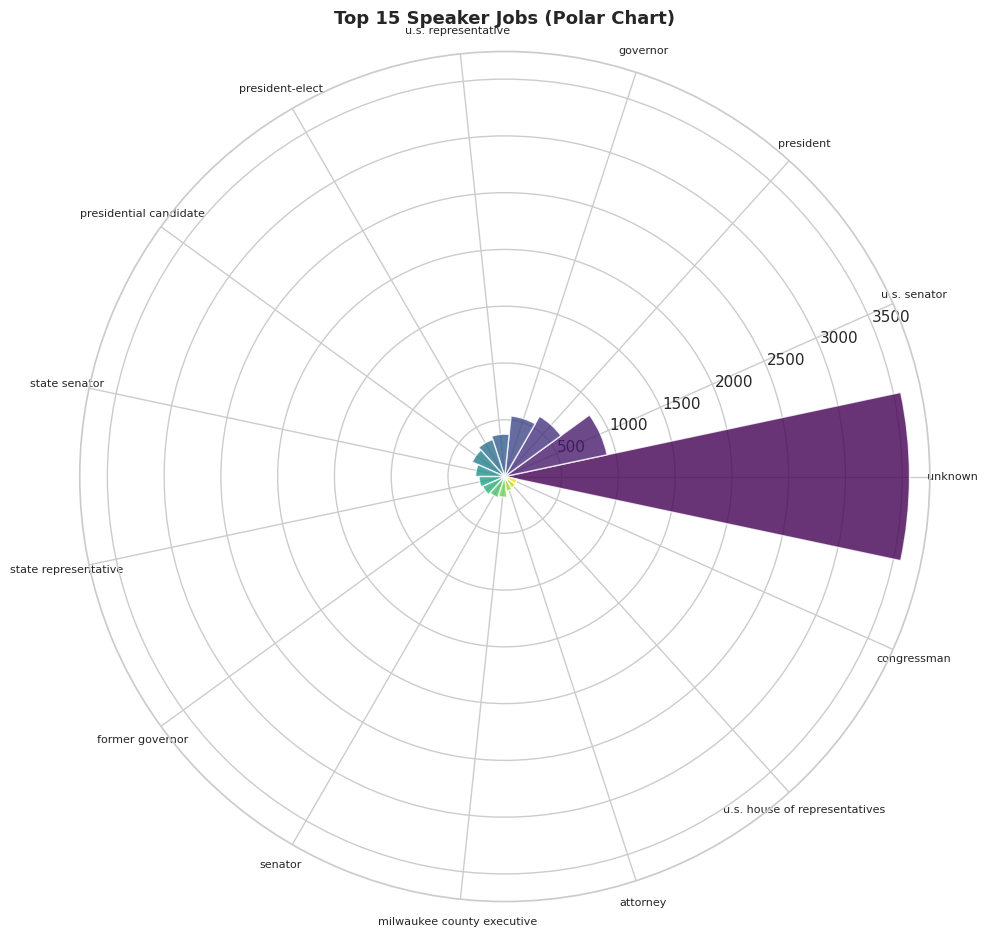

  Creating violin plot for credit history...


/tmp/ipython-input-1336720514.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=count_data, x='Rating Type', y='Count', palette='muted', ax=ax, inner='box')


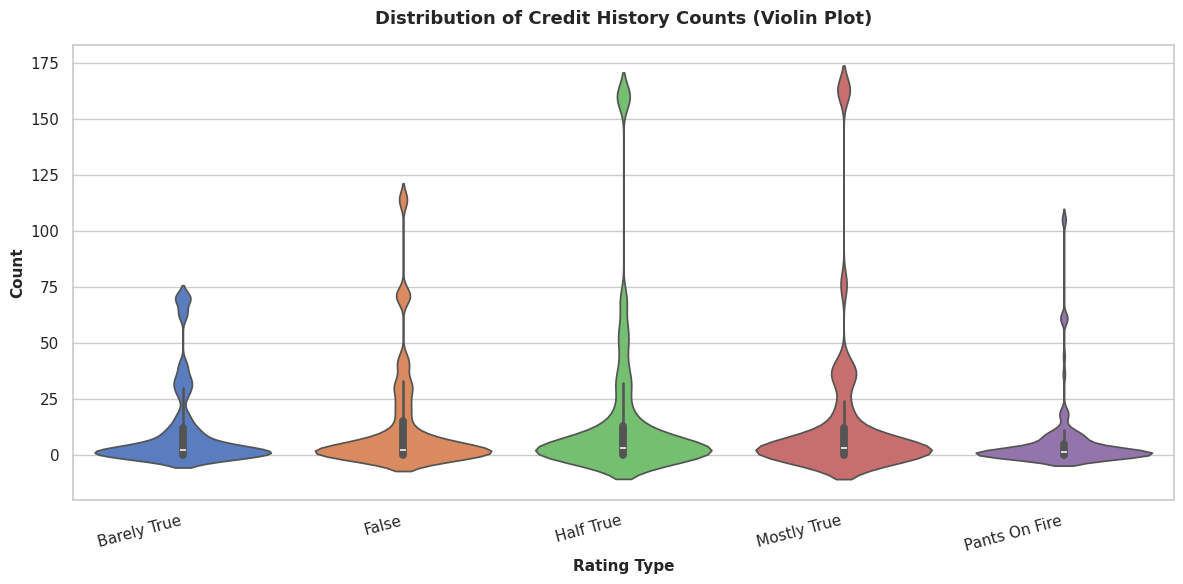

  Creating statement length KDE plot...


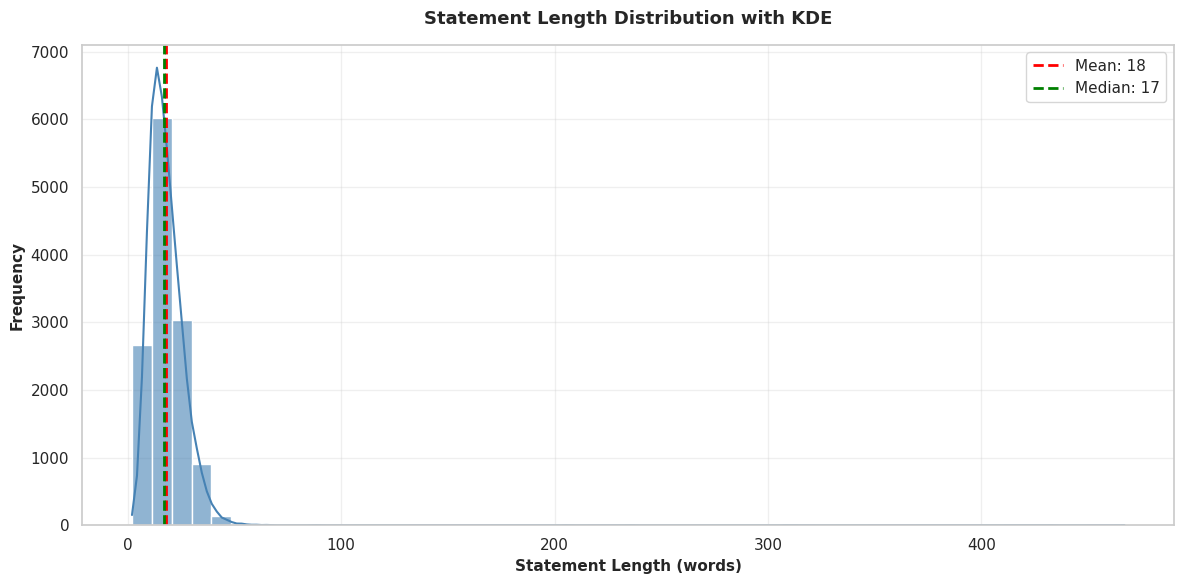

  Creating enhanced correlation matrix...


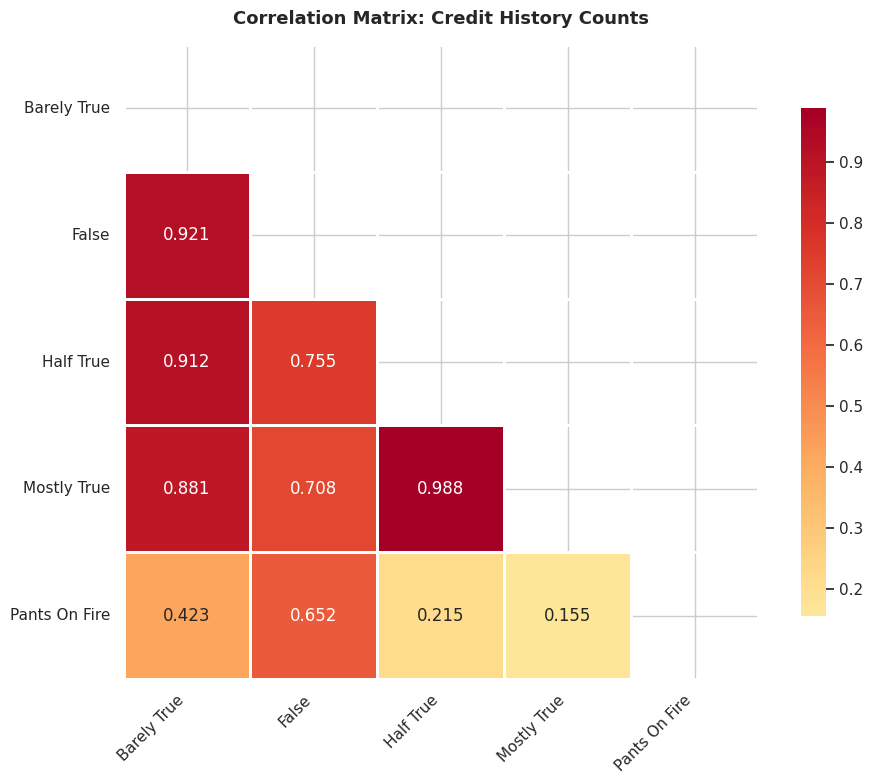


✓ All visualizations created successfully
  Standard visualizations: viz_*.png
  Enhanced visualizations: eda_visualizations/

EXPLORATORY DATA ANALYSIS COMPLETE


In [ ]:
"""
Task 2.2: Visualizations
Purpose: Create comprehensive EDA visualizations
Note: This uses the existing visualization function with enhancements
"""

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

def visualization(df):
    """
    Create comprehensive visualizations for EDA
    This function maintains the original visualization style

    Parameters:
        df (pd.DataFrame): Cleaned dataset
    """
    print("\n[Task 2.2] Creating Visualizations...")

    # Set style
    sns.set(style="whitegrid")

    # Calculate statement length in words
    df["statement_length"] = df["statement"].astype(str).apply(lambda x: len(x.split()))

    # 1. Label Distribution
    print("  Creating label distribution plot...")
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, y='label', hue='label', palette="Set2", legend=False)
    plt.title("NEWS Detection Fake vs Real")
    plt.xlabel('Count')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.savefig('viz_label_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. Top 20 Speakers
    print("  Creating top speakers plot...")
    plt.figure(figsize=(10, 5))
    top_speakers = df['speaker'].value_counts().head(20).reset_index()
    top_speakers.columns = ['speaker', 'count']
    sns.barplot(data=top_speakers, x='count', hue='speaker', y='speaker', palette='coolwarm', dodge=False)
    plt.legend([], [], frameon=False)
    plt.title('Top 20 speakers with most statements')
    plt.xlabel('Count')
    plt.ylabel('Speaker')
    plt.tight_layout()
    plt.savefig('viz_top_speakers.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 3. Party Distribution
    print("  Creating party distribution plot...")
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, y='party', hue='party', palette='Set2', legend=False)
    plt.title('Party Affiliation Distribution')
    plt.xlabel('Count')
    plt.ylabel('Party')
    plt.tight_layout()
    plt.savefig('viz_party_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 4. Subject Distribution
    print("  Creating subject distribution plot...")
    plt.figure(figsize=(10, 5))
    top_subject = df['subject'].value_counts().head(20).reset_index()
    top_subject.columns = ['subject', 'count']
    sns.barplot(data=top_subject, x='count', hue='subject', y='subject', palette='coolwarm', dodge=False)
    plt.legend([], [], frameon=False)
    plt.title('Top 20 subject category distribution')
    plt.xlabel('Count')
    plt.ylabel('Subject')
    plt.tight_layout()
    plt.savefig('viz_subject_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 5. Statement Length Distribution
    print("  Creating statement length distribution...")
    plt.figure(figsize=(10, 5))
    sns.histplot(df['statement_length'], bins=30, kde=True, color='skyblue')
    plt.title('Statement length distribution')
    plt.xlabel('Number of words')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('viz_statement_length.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 6. Credit History Count Distribution
    print("  Creating credit history distribution...")
    df['total_ratings'] = (df['barely_true_counts'] + df['false_counts'] +
                           df['half_true_counts'] + df['mostly_true_counts'] +
                           df['pants_on_fire_counts'])
    plt.figure(figsize=(10, 5))
    sns.histplot(df['total_ratings'], bins=30, kde=True, color='skyblue')
    plt.title('Credit History Count distribution')
    plt.xlabel('Credit history count')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('viz_credit_history.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 7. Statement Length By Label (Outlier Detection)
    print("  Creating statement length by label boxplot...")
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='label', y='statement_length', hue='label', palette='pastel')
    plt.title("Statement Length By Label")
    plt.xlabel('Label')
    plt.ylabel('Statement Length')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('viz_length_by_label.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 8. Credit History By Label
    print("  Creating credit history by label boxplot...")
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='label', y='total_ratings', hue='label', palette='Set2')
    plt.title("Credit History By Label")
    plt.xlabel('Label')
    plt.ylabel('Total Rating')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('viz_credits_by_label.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 9. Statement length vs Total credibility
    print("  Creating statement length vs credibility scatter plot...")
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='statement_length', y='total_ratings', hue='label', alpha=0.6, palette='tab10')
    plt.title('Scatterplot: Statement Length vs Speaker Credibility')
    plt.xlabel('Statement Length (words)')
    plt.ylabel('Total Credibility Ratings')
    plt.tight_layout()
    plt.savefig('viz_length_vs_credibility.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 10. False Counts vs Pants-on-Fire Counts
    print("  Creating false vs pants-on-fire scatter plot...")
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='false_counts', y='pants_on_fire_counts', hue='label', alpha=0.6, palette='tab10')
    plt.title('Scatterplot: False count vs Pants on fire count')
    plt.xlabel('False count')
    plt.ylabel('Pants on fire count')
    plt.tight_layout()
    plt.savefig('viz_false_vs_pants.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # 11. WordCloud for each label
    print("  Creating word clouds for each label...")
    for label in df['label'].unique():
        text = " ".join(df[df['label'] == label]['statement'].astype(str))
        wordcloud = WordCloud(width=900, height=400, background_color='white', colormap='plasma').generate(text)
        plt.figure(figsize=(7, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud of: {label}')
        plt.tight_layout()
        plt.savefig(f'viz_wordcloud_{label}.png', dpi=100, bbox_inches='tight')
        plt.show()
        plt.close()

    # 12. Correlation Heat Map
    print("  Creating correlation heatmap...")
    plt.figure(figsize=(10, 5))
    num_df = df[['barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts']]
    sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation HeatMap of Credibility Count")
    plt.tight_layout()
    plt.savefig('viz_correlation_heatmap.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

    # ENHANCED VISUALIZATIONS (from statistical_analysis function)
    print("\n  Creating enhanced EDA visualizations...")

    # Create EDA output directory
    eda_dir = Path('eda_visualizations')
    eda_dir.mkdir(exist_ok=True)

    # 13. Enhanced Label Distribution (Donut Chart)
    print("  Creating enhanced label distribution...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    label_counts = df['label'].value_counts()
    colors = sns.color_palette('Set2', n_colors=len(label_counts))

    # Donut chart
    wedges, texts, autotexts = ax1.pie(label_counts.values, labels=label_counts.index,
                                         autopct='%1.1f%%', startangle=90, colors=colors,
                                         wedgeprops=dict(width=0.5, edgecolor='white'))
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(9)
        autotext.set_weight('bold')
    ax1.set_title('Label Distribution (Donut Chart)', fontsize=12, weight='bold', pad=20)

    # Horizontal bar with values
    label_counts_sorted = label_counts.sort_values()
    bars = ax2.barh(label_counts_sorted.index, label_counts_sorted.values, color=colors)
    ax2.set_xlabel('Count', fontsize=10)
    ax2.set_title('Label Frequency', fontsize=12, weight='bold')
    ax2.bar_label(bars, padding=3)

    plt.tight_layout()
    plt.savefig(eda_dir / 'label_distribution_enhanced.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # 14. Lollipop Chart for Speakers
    print("  Creating lollipop chart for speakers...")
    fig, ax = plt.subplots(figsize=(10, 8))
    speaker_top20 = df['speaker'].value_counts().head(20).sort_values()
    y_pos = np.arange(len(speaker_top20))

    ax.hlines(y=y_pos, xmin=0, xmax=speaker_top20.values, color='skyblue', alpha=0.7, linewidth=3)
    ax.plot(speaker_top20.values, y_pos, "o", markersize=8, color='steelblue', alpha=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(speaker_top20.index, fontsize=9)
    ax.set_xlabel('Number of Statements', fontsize=11, weight='bold')
    ax.set_title('Top 20 Most Frequent Speakers (Lollipop Chart)', fontsize=13, weight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(eda_dir / 'speaker_lollipop.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # 15. Individual Subject Distribution
    print("  Creating individual subject distribution...")
    all_subjects = []
    for val in df['subject'].dropna():
        subjects = [s.strip() for s in str(val).split(',')]
        all_subjects.extend(subjects)

    subject_counter = Counter(all_subjects)
    subject_top20 = pd.Series(dict(subject_counter.most_common(20)))

    fig, ax = plt.subplots(figsize=(12, 8))
    subject_sorted = subject_top20.sort_values()

    colors_subj = plt.cm.Spectral(np.linspace(0.2, 0.8, len(subject_sorted)))
    bars = ax.barh(range(len(subject_sorted)), subject_sorted.values, color=colors_subj)

    ax.set_yticks(range(len(subject_sorted)))
    ax.set_yticklabels(subject_sorted.index, fontsize=9)
    ax.set_xlabel('Frequency', fontsize=11, weight='bold')
    ax.set_title('Top 20 Subject Categories (Individual Subjects)', fontsize=13, weight='bold', pad=15)
    ax.bar_label(bars, padding=3, fontsize=8)

    plt.tight_layout()
    plt.savefig(eda_dir / 'subject_individual.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # 16. Polar Chart for Speaker Jobs
    print("  Creating polar chart for speaker jobs...")
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='polar')

    job_top15 = df['speaker_job'].value_counts().head(15)
    theta = np.linspace(0.0, 2 * np.pi, len(job_top15), endpoint=False)
    radii = job_top15.values
    width = 2 * np.pi / len(job_top15)

    colors_job = plt.cm.viridis(np.linspace(0, 1, len(job_top15)))
    bars = ax.bar(theta, radii, width=width, bottom=0.0, color=colors_job, alpha=0.8)

    ax.set_xticks(theta)
    ax.set_xticklabels(job_top15.index, fontsize=8)
    ax.set_title('Top 15 Speaker Jobs (Polar Chart)', fontsize=13, weight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(eda_dir / 'speaker_job_polar.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # 17. Violin Plot for Credit History
    print("  Creating violin plot for credit history...")
    fig, ax = plt.subplots(figsize=(12, 6))

    count_cols = ['barely_true_counts', 'false_counts', 'half_true_counts',
                  'mostly_true_counts', 'pants_on_fire_counts']
    count_data = df[count_cols].melt(var_name='Rating Type', value_name='Count')
    count_data['Rating Type'] = count_data['Rating Type'].str.replace('_counts', '').str.replace('_', ' ').str.title()

    sns.violinplot(data=count_data, x='Rating Type', y='Count', palette='muted', ax=ax, inner='box')
    ax.set_xlabel('Rating Type', fontsize=11, weight='bold')
    ax.set_ylabel('Count', fontsize=11, weight='bold')
    ax.set_title('Distribution of Credit History Counts (Violin Plot)', fontsize=13, weight='bold', pad=15)
    plt.xticks(rotation=15, ha='right')

    plt.tight_layout()
    plt.savefig(eda_dir / 'credit_history_violin.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # 18. Statement Length with KDE
    print("  Creating statement length KDE plot...")
    fig, ax = plt.subplots(figsize=(12, 6))

    stmt_stats = df['statement_length'].describe()
    sns.histplot(df['statement_length'], bins=50, kde=True, color='steelblue', alpha=0.6, ax=ax)
    ax.axvline(stmt_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {stmt_stats['mean']:.0f}")
    ax.axvline(stmt_stats['50%'], color='green', linestyle='--', linewidth=2, label=f"Median: {stmt_stats['50%']:.0f}")

    ax.set_xlabel('Statement Length (words)', fontsize=11, weight='bold')
    ax.set_ylabel('Frequency', fontsize=11, weight='bold')
    ax.set_title('Statement Length Distribution with KDE', fontsize=13, weight='bold', pad=15)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(eda_dir / 'statement_length_kde.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # 19. Enhanced Correlation Matrix
    print("  Creating enhanced correlation matrix...")
    fig, ax = plt.subplots(figsize=(10, 8))

    correlation_matrix = df[count_cols].corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f',
                cmap='RdYlBu_r', center=0, square=True, linewidths=1,
                cbar_kws={"shrink": 0.8}, ax=ax)

    ax.set_title('Correlation Matrix: Credit History Counts', fontsize=13, weight='bold', pad=15)

    labels = [col.replace('_counts', '').replace('_', ' ').title() for col in count_cols]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)

    plt.tight_layout()
    plt.savefig(eda_dir / 'correlation_enhanced.png', bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    print("\n✓ All visualizations created successfully")
    print(f"  Standard visualizations: viz_*.png")
    print(f"  Enhanced visualizations: {eda_dir}/")


# Execute visualization
visualization(df_clean)

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS COMPLETE")
print("=" * 60)

In [ ]:
"""
Task 3.1: Text Feature Extraction
Purpose: Process text and extract meaningful features from statements
"""

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Try to import TextBlob for sentiment analysis
try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except ImportError:
    print("Warning: TextBlob not installed. Sentiment analysis will be skipped.")
    print("Install with: pip install textblob")
    TEXTBLOB_AVAILABLE = False

def preprocess_text_with_lemmatization(text):
    """
    Preprocess text for machine learning
    - Tokenize
    - Convert to lowercase
    - Remove stopwords
    - Lemmatize words

    Parameters:
        text (str): Input text

    Returns:
        str: Processed text
    """
    if pd.isna(text):
        return ""

    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()

    # Initialize stopwords
    stop_words = set(stopwords.words('english'))

    # Tokenize
    tokens = word_tokenize(str(text).lower())

    # Remove stopwords and non-alphabetic tokens
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

    # Lemmatize (better than stemming for preserving word meaning)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


def extract_text_features(df):
    """
    Extract comprehensive text features from statements

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with additional text features
    """
    print("\n[Task 3.1] Text Feature Extraction...")

    df_fe = df.copy()

    # 1. Preprocess text (lemmatization)
    print("\n  Step 1: Text preprocessing with lemmatization...")
    df_fe['statement_processed'] = df_fe['statement'].apply(preprocess_text_with_lemmatization)

    # Show sample comparison
    print("\n  Sample preprocessing comparison:")
    for i in range(2):
        print(f"\n    Original: {df_fe['statement'].iloc[i][:80]}...")
        print(f"    Processed: {df_fe['statement_processed'].iloc[i][:80]}...")

    # 2. Basic text features
    print("\n  Step 2: Extracting basic text features...")

    # Word count
    df_fe['word_count'] = df_fe['statement'].apply(lambda x: len(str(x).split()))

    # Character count
    df_fe['char_count'] = df_fe['statement'].apply(lambda x: len(str(x)))

    # Average word length
    df_fe['avg_word_length'] = df_fe['statement'].apply(
        lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
    )

    # Sentence count (approximate by counting periods)
    df_fe['sentence_count'] = df_fe['statement'].apply(lambda x: len(str(x).split('.')))

    # 3. Punctuation features
    print("  Step 3: Extracting punctuation features...")

    # Exclamation marks (may indicate emotional content)
    df_fe['exclamation_count'] = df_fe['statement'].apply(lambda x: str(x).count('!'))

    # Question marks
    df_fe['question_count'] = df_fe['statement'].apply(lambda x: str(x).count('?'))

    # Uppercase words (may indicate emphasis)
    df_fe['uppercase_count'] = df_fe['statement'].apply(
        lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) > 1)
    )

    # 4. Sentiment analysis
    if TEXTBLOB_AVAILABLE:
        print("  Step 4: Computing sentiment scores...")
        df_fe['sentiment_polarity'] = df_fe['statement'].apply(
            lambda x: TextBlob(str(x)).sentiment.polarity
        )
        df_fe['sentiment_subjectivity'] = df_fe['statement'].apply(
            lambda x: TextBlob(str(x)).sentiment.subjectivity
        )
        print(f"    ✓ Created 9 text features")
    else:
        print("  Step 4: Skipping sentiment analysis (TextBlob not available)")
        df_fe['sentiment_polarity'] = 0.0
        df_fe['sentiment_subjectivity'] = 0.0
        print(f"    ✓ Created 7 text features (without sentiment)")

    print("\n✓ Text feature extraction complete")

    return df_fe


# Execute text feature extraction
print("\n" + "=" * 60)
print("PHASE 3: FEATURE ENGINEERING")
print("=" * 60)

df_with_text_features = extract_text_features(df_clean)

print(f"\nNew columns added: {len(df_with_text_features.columns) - len(df_clean.columns)}")


PHASE 3: FEATURE ENGINEERING

[Task 3.1] Text Feature Extraction...

  Step 1: Text preprocessing with lemmatization...

  Sample preprocessing comparison:

    Original: says the annies list political group supports third-trimester abortions on deman...
    Processed: say annies list political group support abortion demand...

    Original: when did the decline of coal start? it started when natural gas took off that st...
    Processed: decline coal start started natural gas took started begin president george bush ...

  Step 2: Extracting basic text features...
  Step 3: Extracting punctuation features...
  Step 4: Computing sentiment scores...
    ✓ Created 9 text features

✓ Text feature extraction complete

New columns added: 10


In [ ]:
"""
Task 3.2: Metadata Feature Engineering
Purpose: Create features from categorical metadata and credit history
"""

def engineer_credit_history_features(df):
    """
    Engineer features from credit history counts

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with credit history features
    """
    print("\n[Task 3.2.1] Engineering Credit History Features...")

    df_fe = df.copy()

    count_cols = ['barely_true_counts', 'false_counts', 'half_true_counts',
                  'mostly_true_counts', 'pants_on_fire_counts']

    # Total credit count
    df_fe['total_credit_count'] = df_fe[count_cols].sum(axis=1)

    # Ratio features (handle division by zero)
    for col in count_cols:
        ratio_col = col.replace('_counts', '_ratio')
        df_fe[ratio_col] = df_fe.apply(
            lambda row: row[col] / row['total_credit_count'] if row['total_credit_count'] > 0 else 0,
            axis=1
        )

    # Credibility score (weighted average favoring truthfulness)
    # Scale: 0 (pants-fire) to 5 (mostly-true)
    df_fe['credibility_score'] = df_fe.apply(
        lambda row: (
            row['pants_on_fire_counts'] * 0 +
            row['false_counts'] * 1 +
            row['barely_true_counts'] * 2 +
            row['half_true_counts'] * 3 +
            row['mostly_true_counts'] * 4
        ) / row['total_credit_count'] if row['total_credit_count'] > 0 else 0,
        axis=1
    )

    # False-to-True ratio (indicator of speaker reliability)
    df_fe['false_to_true_ratio'] = df_fe.apply(
        lambda row: (row['false_counts'] + row['pants_on_fire_counts']) /
                    (row['mostly_true_counts'] + 1),  # +1 to avoid division by zero
        axis=1
    )

    print(f"  ✓ Created {len(count_cols) + 3} credit history features")

    return df_fe


def generalize_context_feature(df):
    """
    Generalize context into broader categories

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with generalized context
    """
    print("\n[Task 3.2.2] Generalizing Context Feature...")

    df_fe = df.copy()

    def categorize_context(context_str):
        """Helper function to categorize context"""
        if pd.isna(context_str) or context_str == 'unknown':
            return 'unknown'

        context_lower = str(context_str).lower()

        # Define generalization rules
        if 'interview' in context_lower:
            return 'interview'
        elif 'broadcast' in context_lower or 'tv' in context_lower or 'television' in context_lower:
            return 'broadcast'
        elif 'debate' in context_lower:
            return 'debate'
        elif 'speech' in context_lower or 'address' in context_lower:
            return 'speech'
        elif 'news conference' in context_lower or 'press conference' in context_lower:
            return 'news conference'
        elif 'tweet' in context_lower or 'twitter' in context_lower or 'social media' in context_lower:
            return 'social media'
        elif 'facebook' in context_lower:
            return 'social media'
        elif 'ad' in context_lower or 'advertisement' in context_lower or 'commercial' in context_lower:
            return 'advertisement'
        elif 'radio' in context_lower:
            return 'radio'
        elif 'email' in context_lower or 'letter' in context_lower:
            return 'written communication'
        elif 'campaign' in context_lower:
            return 'campaign event'
        elif 'hearing' in context_lower or 'testimony' in context_lower:
            return 'hearing'
        elif 'article' in context_lower or 'blog' in context_lower or 'website' in context_lower:
            return 'online publication'
        else:
            return 'other'

    df_fe['context_generalized'] = df_fe['context'].apply(categorize_context)

    print("  Context categories after generalization:")
    print(df_fe['context_generalized'].value_counts())

    return df_fe


def encode_target_label(df):
    """
    Encode target label as ordinal variable

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with encoded label
    """
    print("\n[Task 3.2.3] Encoding Target Label...")

    df_fe = df.copy()

    # Define ordinal mapping (0 = most false, 5 = most true)
    label_mapping = {
        'pants-fire': 0,
        'false': 1,
        'barely-true': 2,
        'half-true': 3,
        'mostly-true': 4,
        'true': 5
    }

    df_fe['label_encoded'] = df_fe['label'].map(label_mapping)

    print(f"  Label mapping: {label_mapping}")
    print(f"\n  Label distribution:")
    print(df_fe['label_encoded'].value_counts().sort_index())

    return df_fe


def select_top_categories_for_encoding(df, column, top_n=15, min_coverage=0.8):
    """
    Select top N categories based on frequency and coverage

    Parameters:
        df (pd.DataFrame): Input dataframe
        column (str): Column name
        top_n (int): Maximum number of categories to select
        min_coverage (float): Minimum data coverage threshold

    Returns:
        list: Selected category names
    """
    # Get value counts
    value_counts = df[column].value_counts()
    cumulative_coverage = value_counts.cumsum() / len(df)

    # Get categories covering minimum data
    categories_for_coverage = cumulative_coverage[cumulative_coverage <= min_coverage].index.tolist()

    # If we haven't reached min_coverage, add one more
    if cumulative_coverage.iloc[len(categories_for_coverage)] < min_coverage:
        if len(categories_for_coverage) < len(value_counts):
            categories_for_coverage.append(value_counts.index[len(categories_for_coverage)])

    # Limit to top_n
    selected = categories_for_coverage[:top_n]

    coverage = value_counts[selected].sum() / len(df)
    print(f"  {column}: Selected {len(selected)} categories covering {coverage:.2%} of data")

    return selected


def create_categorical_features(df):
    """
    Create one-hot encoded features for top categories

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with categorical features
    """
    print("\n[Task 3.2.4] Creating Categorical Features...")

    df_fe = df.copy()

    # Party
    print("\n  Encoding party...")
    top_parties = select_top_categories_for_encoding(df_fe, 'party', top_n=10)
    for party in top_parties:
        df_fe[f'party_{party}'] = (df_fe['party'] == party).astype(int)

    # State
    print("\n  Encoding state...")
    top_states = select_top_categories_for_encoding(df_fe, 'state', top_n=15)
    for state in top_states:
        df_fe[f'state_{state}'] = (df_fe['state'] == state).astype(int)

    # Speaker Job
    print("\n  Encoding speaker_job...")
    top_jobs = select_top_categories_for_encoding(df_fe, 'speaker_job', top_n=15)
    for job in top_jobs:
        df_fe[f'job_{job}'] = (df_fe['speaker_job'] == job).astype(int)

    # Context (generalized)
    print("\n  Encoding context_generalized...")
    top_contexts = select_top_categories_for_encoding(df_fe, 'context_generalized', top_n=10)
    for ctx in top_contexts:
        df_fe[f'context_{ctx}'] = (df_fe['context_generalized'] == ctx).astype(int)

    # Subject (extract individual subjects)
    print("\n  Encoding subject (individual subjects)...")

    # Extract all individual subjects
    all_subjects = []
    for val in df_fe['subject'].dropna():
        subjects = [s.strip() for s in str(val).split(',')]
        all_subjects.extend(subjects)

    subject_counts = Counter(all_subjects)
    top_subjects = [subj for subj, _ in subject_counts.most_common(20)]

    print(f"  subject: Creating binary features for top 20 subjects")

    for subject in top_subjects:
        df_fe[f'subject_{subject}'] = df_fe['subject'].apply(
            lambda x: 1 if pd.notna(x) and subject in str(x) else 0
        )

    categorical_feature_count = (
        len(top_parties) + len(top_states) + len(top_jobs) +
        len(top_contexts) + len(top_subjects)
    )

    print(f"\n  ✓ Created {categorical_feature_count} categorical features")

    return df_fe


def create_speaker_features(df):
    """
    Create speaker-based aggregate features

    Parameters:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with speaker features
    """
    print("\n[Task 3.2.5] Creating Speaker Features...")

    df_fe = df.copy()

    # Is speaker in top N most frequent?
    top_speakers = df_fe['speaker'].value_counts().head(30).index
    df_fe['is_frequent_speaker'] = df_fe['speaker'].isin(top_speakers).astype(int)

    # Speaker statement count
    speaker_counts = df_fe['speaker'].value_counts()
    df_fe['speaker_statement_count'] = df_fe['speaker'].map(speaker_counts).fillna(0)

    print(f"  ✓ Created 2 speaker-based features")

    return df_fe


# Execute all metadata feature engineering
df_with_credit = engineer_credit_history_features(df_with_text_features)
df_with_context = generalize_context_feature(df_with_credit)
df_with_label = encode_target_label(df_with_context)
df_with_categorical = create_categorical_features(df_with_label)
df_feature_engineered = create_speaker_features(df_with_categorical)

# Save feature-engineered dataset
df_feature_engineered.to_csv('liar_feature_engineered.csv', index=False, encoding='utf-8')
print("\n✓ Feature-engineered dataset saved: liar_feature_engineered.csv")

# Summary
print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"Original features: {len(df_clean.columns)}")
print(f"Engineered features: {len(df_feature_engineered.columns)}")
print(f"New features created: {len(df_feature_engineered.columns) - len(df_clean.columns)}")

print("\n" + "=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)


[Task 3.2.1] Engineering Credit History Features...
  ✓ Created 8 credit history features

[Task 3.2.2] Generalizing Context Feature...
  Context categories after generalization:
context_generalized
other                    3954
interview                2152
speech                   1468
debate                    933
broadcast                 853
advertisement             835
social media              580
campaign event            494
online publication        476
written communication     414
news conference           318
hearing                   159
unknown                   129
Name: count, dtype: int64

[Task 3.2.3] Encoding Target Label...
  Label mapping: {'pants-fire': 0, 'false': 1, 'barely-true': 2, 'half-true': 3, 'mostly-true': 4, 'true': 5}

  Label distribution:
label_encoded
0    1047
1    2493
2    2102
3    2621
4    2452
5    2050
Name: count, dtype: int64

[Task 3.2.4] Creating Categorical Features...

  Encoding party...
  party: Selected 2 categories covering 76.5

In [ ]:
"""
Task 3.3: Create Fresh Train/Validation/Test Splits
Purpose: Create properly shuffled, unbiased splits for model training
IMPORTANT: This replaces the original split to avoid any potential bias
"""

from sklearn.model_selection import train_test_split

def create_fresh_data_splits(df, test_size=0.15, valid_size=0.15, random_state=42):
    """
    Create fresh train/validation/test splits with proper shuffling

    Parameters:
        df (pd.DataFrame): Feature-engineered dataframe
        test_size (float): Proportion for test set
        valid_size (float): Proportion for validation set
        random_state (int): Random seed for reproducibility

    Returns:
        tuple: (train_df, valid_df, test_df)
    """
    print("\n[Task 3.3] Creating Fresh Data Splits...")
    print(f"  Test size: {test_size:.1%}, Valid size: {valid_size:.1%}, Train size: {1-test_size-valid_size:.1%}")

    # First, shuffle the entire dataset
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    print(f"  ✓ Dataset shuffled (random_state={random_state})")

    # Split: First separate test set
    train_valid_df, test_df = train_test_split(
        df_shuffled,
        test_size=test_size,
        random_state=random_state,
        stratify=df_shuffled['label_encoded']  # Maintain label distribution
    )

    # Split: Separate validation from remaining data
    # Adjust valid_size to be relative to remaining data
    adjusted_valid_size = valid_size / (1 - test_size)

    train_df, valid_df = train_test_split(
        train_valid_df,
        test_size=adjusted_valid_size,
        random_state=random_state,
        stratify=train_valid_df['label_encoded']
    )

    # Add split identifier
    train_df['split'] = 'train'
    valid_df['split'] = 'valid'
    test_df['split'] = 'test'

    # Display split information
    print(f"\n  Split sizes:")
    print(f"    Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"    Valid: {len(valid_df):,} ({len(valid_df)/len(df)*100:.1f}%)")
    print(f"    Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")
    print(f"    Total: {len(df):,}")

    # Check label distribution in each split
    print(f"\n  Label distribution check:")
    print(f"    Train: {train_df['label_encoded'].value_counts().sort_index().to_dict()}")
    print(f"    Valid: {valid_df['label_encoded'].value_counts().sort_index().to_dict()}")
    print(f"    Test:  {test_df['label_encoded'].value_counts().sort_index().to_dict()}")

    print("\n  ✓ Fresh splits created with stratification")

    return train_df, valid_df, test_df


# Create fresh splits
train_df, valid_df, test_df = create_fresh_data_splits(df_feature_engineered)

# Save individual splits
train_df.to_csv('data_train.csv', index=False, encoding='utf-8')
valid_df.to_csv('data_valid.csv', index=False, encoding='utf-8')
test_df.to_csv('data_test.csv', index=False, encoding='utf-8')

print("\n✓ Split datasets saved:")
print("  - data_train.csv")
print("  - data_valid.csv")
print("  - data_test.csv")


[Task 3.3] Creating Fresh Data Splits...
  Test size: 15.0%, Valid size: 15.0%, Train size: 70.0%
  ✓ Dataset shuffled (random_state=42)

  Split sizes:
    Train: 8,935 (70.0%)
    Valid: 1,915 (15.0%)
    Test:  1,915 (15.0%)
    Total: 12,765

  Label distribution check:
    Train: {0: 733, 1: 1745, 2: 1472, 3: 1835, 4: 1716, 5: 1434}
    Valid: {0: 157, 1: 374, 2: 315, 3: 393, 4: 368, 5: 308}
    Test:  {0: 157, 1: 374, 2: 315, 3: 393, 4: 368, 5: 308}

  ✓ Fresh splits created with stratification

✓ Split datasets saved:
  - data_train.csv
  - data_valid.csv
  - data_test.csv


In [ ]:
"""
Task 3.4: Prepare Data for Logistic Regression
Purpose: Vectorize text and prepare final feature matrices for training
"""

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import joblib

def prepare_logistic_regression_data(train_df, valid_df, test_df):
    """
    Prepare data specifically for Logistic Regression
    - TF-IDF vectorization for text
    - Standard scaling for numerical features
    - Combine text and metadata features

    Parameters:
        train_df (pd.DataFrame): Training data
        valid_df (pd.DataFrame): Validation data
        test_df (pd.DataFrame): Test data

    Returns:
        dict: Dictionary containing prepared data and transformers
    """
    print("\n[Task 3.4] Preparing Data for Logistic Regression...")

    # Define feature columns
    text_feature = 'statement_processed'
    target = 'label_encoded'

    # Numerical features (these should all be numeric)
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_polarity', 'sentiment_subjectivity',
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]

    # Filter to only include features that exist in the dataframe
    numerical_features = [f for f in numerical_features if f in train_df.columns]

    # Categorical binary features (these should all be 0 or 1)
    categorical_features = [col for col in train_df.columns if any(
        col.startswith(prefix) for prefix in ['party_', 'state_', 'job_', 'context_', 'subject_']
    )]

    # Combine all metadata features
    metadata_features = numerical_features + categorical_features

    print(f"\n  Feature composition:")
    print(f"    Text feature: {text_feature}")
    print(f"    Numerical features: {len(numerical_features)}")
    print(f"    Categorical features: {len(categorical_features)}")
    print(f"    Total metadata features: {len(metadata_features)}")

    # Verify all metadata features are numeric
    print("\n  Verifying feature data types...")
    non_numeric_cols = []
    for col in metadata_features:
        if col in train_df.columns:
            # Check if column can be converted to numeric
            try:
                train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
                valid_df[col] = pd.to_numeric(valid_df[col], errors='coerce')
                test_df[col] = pd.to_numeric(test_df[col], errors='coerce')
            except Exception as e:
                non_numeric_cols.append(col)
                print(f"    ⚠ Warning: Could not convert '{col}' to numeric: {e}")

    if non_numeric_cols:
        print(f"\n  Removing {len(non_numeric_cols)} non-numeric columns:")
        for col in non_numeric_cols:
            print(f"    - {col}")
            metadata_features.remove(col)
    else:
        print("    ✓ All features are numeric")

    # Extract text data
    X_train_text = train_df[text_feature].values
    X_valid_text = valid_df[text_feature].values
    X_test_text = test_df[text_feature].values

    # Extract metadata with proper handling
    print("\n  Extracting metadata features...")
    X_train_meta = train_df[metadata_features].fillna(0).astype(np.float64).values
    X_valid_meta = valid_df[metadata_features].fillna(0).astype(np.float64).values
    X_test_meta = test_df[metadata_features].fillna(0).astype(np.float64).values

    print(f"    ✓ Metadata shape: {X_train_meta.shape}")

    # Extract target
    y_train = train_df[target].values
    y_valid = valid_df[target].values
    y_test = test_df[target].values

    # Step 1: TF-IDF Vectorization
    print("\n  Step 1: TF-IDF vectorization...")
    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )

    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_valid_tfidf = tfidf.transform(X_valid_text)
    X_test_tfidf = tfidf.transform(X_test_text)

    print(f"    ✓ TF-IDF shape: {X_train_tfidf.shape}")
    print(f"    ✓ Vocabulary size: {len(tfidf.get_feature_names_out())}")

    # Step 2: Standardize metadata features
    print("\n  Step 2: Standardizing metadata features...")
    scaler = StandardScaler()

    X_train_meta_scaled = scaler.fit_transform(X_train_meta)
    X_valid_meta_scaled = scaler.transform(X_valid_meta)
    X_test_meta_scaled = scaler.transform(X_test_meta)

    print(f"    ✓ Scaled metadata shape: {X_train_meta_scaled.shape}")

    # Step 3: Combine TF-IDF and metadata features
    print("\n  Step 3: Combining TF-IDF and metadata features...")

    X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta_scaled)])
    X_valid_final = hstack([X_valid_tfidf, csr_matrix(X_valid_meta_scaled)])
    X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_meta_scaled)])

    print(f"    ✓ Final feature matrix shape: {X_train_final.shape}")

    # Create feature names list
    feature_names = list(tfidf.get_feature_names_out()) + metadata_features

    # Package everything
    prepared_data = {
        'X_train': X_train_final,
        'X_valid': X_valid_final,
        'X_test': X_test_final,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'tfidf_vectorizer': tfidf,
        'scaler': scaler,
        'feature_names': feature_names,
        'metadata_features': metadata_features
    }

    # Save prepared data
    print("\n  Step 4: Saving prepared data...")
    joblib.dump(prepared_data, 'logistic_regression_data.pkl')
    print("    ✓ Saved: logistic_regression_data.pkl")

    print("\n✓ Data preparation for Logistic Regression complete")

    return prepared_data


# Prepare data for Logistic Regression
lr_data = prepare_logistic_regression_data(train_df, valid_df, test_df)

print("\n" + "=" * 60)
print("DATA PREPARATION FOR MODELING COMPLETE")
print("=" * 60)


[Task 3.4] Preparing Data for Logistic Regression...

  Feature composition:
    Text feature: statement_processed
    Numerical features: 24
    Categorical features: 55
    Total metadata features: 79

  Verifying feature data types...
    ✓ All features are numeric

  Extracting metadata features...
    ✓ Metadata shape: (8935, 79)

  Step 1: TF-IDF vectorization...
    ✓ TF-IDF shape: (8935, 10000)
    ✓ Vocabulary size: 10000

  Step 2: Standardizing metadata features...
    ✓ Scaled metadata shape: (8935, 79)

  Step 3: Combining TF-IDF and metadata features...
    ✓ Final feature matrix shape: (8935, 10079)

  Step 4: Saving prepared data...
    ✓ Saved: logistic_regression_data.pkl

✓ Data preparation for Logistic Regression complete

DATA PREPARATION FOR MODELING COMPLETE


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_logistic_regression(X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names):
    """
    Train Logistic Regression models with different configurations

    Parameters:
        X_train: Training features (sparse matrix)
        X_valid: Validation features (sparse matrix)
        X_test: Test features (sparse matrix)
        y_train: Training labels
        y_valid: Validation labels
        y_test: Test labels
        feature_names: List of feature names
    """
    print("\n" + "=" * 60)
    print("PHASE 4: LOGISTIC REGRESSION MODEL TRAINING")
    print("=" * 60)

    # 1. Baseline Logistic Regression
    print("\n[Model 1] Training Baseline Logistic Regression...")
    lr_baseline = LogisticRegression(
        solver='lbfgs',
        max_iter=5000,
        C=1.0,
        class_weight='balanced',
        random_state=42,
        verbose=0  # Suppress iteration messages
    )
    lr_baseline.fit(X_train, y_train)

    # Predictions
    y_train_pred = lr_baseline.predict(X_train)
    y_valid_pred = lr_baseline.predict(X_valid)
    y_test_pred = lr_baseline.predict(X_test)

    # Evaluation
    print("\n=== Logistic Regression (Baseline) ===")
    print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_valid_pred))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_valid_pred))

    # 2. Logistic Regression with L1 Regularization
    print("\n[Model 2] Training Logistic Regression with L1 Regularization...")
    lr_l1 = LogisticRegression(
        solver='saga',
        penalty='l1',
        C=1.0,
        max_iter=5000,
        random_state=42,
        verbose=0
    )
    lr_l1.fit(X_train, y_train)

    y_valid_pred_l1 = lr_l1.predict(X_valid)
    print(f"Validation Accuracy (L1): {accuracy_score(y_valid, y_valid_pred_l1):.4f}")

    # 3. Logistic Regression with L2 Regularization
    print("\n[Model 3] Training Logistic Regression with L2 Regularization...")
    lr_l2 = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        C=1.0,
        max_iter=5000,
        random_state=42,
        verbose=0
    )
    lr_l2.fit(X_train, y_train)

    y_valid_pred_l2 = lr_l2.predict(X_valid)
    print(f"Validation Accuracy (L2): {accuracy_score(y_valid, y_valid_pred_l2):.4f}")

    # 4. Coefficient Interpretation
    print("\n" + "=" * 60)
    print("COEFFICIENT INTERPRETATION")
    print("=" * 60)

    coef = lr_baseline.coef_
    rows = []

    for idx, class_label in enumerate(lr_baseline.classes_):
        # Top 10 positive coefficients
        top_pos_indices = coef[idx].argsort()[-10:][::-1]
        for feat_idx in top_pos_indices:
            rows.append({
                "class": class_label,
                "feature": feature_names[feat_idx],
                "weight": coef[idx][feat_idx],
                "type": "positive"
            })

        # Top 10 negative coefficients
        top_neg_indices = coef[idx].argsort()[:10]
        for feat_idx in top_neg_indices:
            rows.append({
                "class": class_label,
                "feature": feature_names[feat_idx],
                "weight": coef[idx][feat_idx],
                "type": "negative"
            })

    coef_df = pd.DataFrame(rows)
    coef_df.to_csv("logistic_coefficients.csv", index=False)
    print("✓ Exported top positive/negative features per class to 'logistic_coefficients.csv'")

    # Display sample coefficients
    print("\nSample Top Features for Class 0 (Pants-Fire):")
    print(coef_df[coef_df['class'] == 0].head(10))

    # Save models
    print("\n" + "=" * 60)
    print("SAVING MODELS")
    print("=" * 60)

    joblib.dump(lr_baseline, 'model_lr_baseline.pkl')
    joblib.dump(lr_l1, 'model_lr_l1.pkl')
    joblib.dump(lr_l2, 'model_lr_l2.pkl')

    print("✓ Models saved:")
    print("  - model_lr_baseline.pkl")
    print("  - model_lr_l1.pkl")
    print("  - model_lr_l2.pkl")

    print("\n" + "=" * 60)
    print("LOGISTIC REGRESSION TRAINING COMPLETE")
    print("=" * 60)

    return {
        'baseline': lr_baseline,
        'l1': lr_l1,
        'l2': lr_l2,
        'coefficients': coef_df
    }

lr_models = train_logistic_regression(
    lr_data['X_train'], lr_data['X_valid'], lr_data['X_test'],
    lr_data['y_train'], lr_data['y_valid'], lr_data['y_test'],
    lr_data['feature_names']
)


PHASE 4: LOGISTIC REGRESSION MODEL TRAINING

[Model 1] Training Baseline Logistic Regression...

=== Logistic Regression (Baseline) ===
Training Accuracy:   0.7279
Validation Accuracy: 0.4585
Test Accuracy:       0.4564

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.43      0.57      0.49       157
           1       0.50      0.42      0.45       374
           2       0.44      0.47      0.45       315
           3       0.50      0.48      0.49       393
           4       0.47      0.51      0.49       368
           5       0.38      0.36      0.37       308

    accuracy                           0.46      1915
   macro avg       0.45      0.47      0.46      1915
weighted avg       0.46      0.46      0.46      1915


Confusion Matrix (Validation):
[[ 89  21  18  18   6   5]
 [ 37 156  54  40  44  43]
 [ 24  42 147  38  38  26]
 [ 22  37  58 187  53  36]
 [ 17  27  29  40 189  66]
 [ 20  29  30  50  69 110]]

[Mo

In [ ]:
"""
EXPERIMENT: Binary Classification (Simplified Problem)
Convert 6-class problem to binary: False (0,1,2) vs True (3,4,5)
"""

print("\n" + "=" * 80)
print(" " * 20 + "BINARY CLASSIFICATION EXPERIMENT")
print("=" * 80)

# Convert labels to binary
def convert_to_binary(y):
    """
    Convert ordinal labels to binary:
    - False: 0, 1, 2 (pants-fire, false, barely-true) → 0
    - True: 3, 4, 5 (half-true, mostly-true, true) → 1
    """
    return (y >= 3).astype(int)

# FIX: Extract data from lr_data dictionary
y_train = lr_data['y_train']
y_valid = lr_data['y_valid']
y_test = lr_data['y_test']
X_train = lr_data['X_train']
X_valid = lr_data['X_valid']
X_test = lr_data['X_test']

y_train_binary = convert_to_binary(y_train)
y_valid_binary = convert_to_binary(y_valid)
y_test_binary = convert_to_binary(y_test)

print("\n[Info] Label Distribution:")
print(f"  Training:   False={sum(y_train_binary==0)} ({sum(y_train_binary==0)/len(y_train_binary)*100:.1f}%), "
      f"True={sum(y_train_binary==1)} ({sum(y_train_binary==1)/len(y_train_binary)*100:.1f}%)")
print(f"  Validation: False={sum(y_valid_binary==0)} ({sum(y_valid_binary==0)/len(y_valid_binary)*100:.1f}%), "
      f"True={sum(y_valid_binary==1)} ({sum(y_valid_binary==1)/len(y_valid_binary)*100:.1f}%)")

# Train binary classifier
print("\n[Training] Binary Logistic Regression...")
lr_binary = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    C=0.1,  # Use stronger regularization
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr_binary.fit(X_train, y_train_binary)

# Evaluate
y_train_pred_bin = lr_binary.predict(X_train)
y_valid_pred_bin = lr_binary.predict(X_valid)
y_test_pred_bin = lr_binary.predict(X_test)

print("\n=== BINARY CLASSIFICATION RESULTS ===")
print(f"Training Accuracy:   {accuracy_score(y_train_binary, y_train_pred_bin):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_valid_binary, y_valid_pred_bin):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test_binary, y_test_pred_bin):.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_valid_binary, y_valid_pred_bin,
                          target_names=['False (0-2)', 'True (3-5)']))

print("\nConfusion Matrix (Validation):")
cm = confusion_matrix(y_valid_binary, y_valid_pred_bin)
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]} | False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]} | True Positives:  {cm[1,1]}")

# Save binary model
joblib.dump(lr_binary, 'model_lr_binary.pkl')
print("\n✓ Binary model saved: model_lr_binary.pkl")


                    BINARY CLASSIFICATION EXPERIMENT

[Info] Label Distribution:
  Training:   False=3950 (44.2%), True=4985 (55.8%)
  Validation: False=846 (44.2%), True=1069 (55.8%)

[Training] Binary Logistic Regression...

=== BINARY CLASSIFICATION RESULTS ===
Training Accuracy:   0.7580
Validation Accuracy: 0.7363
Test Accuracy:       0.7363

Classification Report (Validation):
              precision    recall  f1-score   support

 False (0-2)       0.70      0.70      0.70       846
  True (3-5)       0.77      0.76      0.76      1069

    accuracy                           0.74      1915
   macro avg       0.73      0.73      0.73      1915
weighted avg       0.74      0.74      0.74      1915


Confusion Matrix (Validation):
[[596 250]
 [255 814]]

True Negatives:  596 | False Positives: 250
False Negatives: 255 | True Positives:  814

✓ Binary model saved: model_lr_binary.pkl


In [ ]:
"""
EXPERIMENT: Improved Logistic Regression with Better Hyperparameters
"""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("\n" + "=" * 80)
print(" " * 20 + "HYPERPARAMETER TUNING EXPERIMENT")
print("=" * 80)

# Load the prepared data
lr_data = joblib.load('logistic_regression_data.pkl')

X_train = lr_data['X_train']
X_valid = lr_data['X_valid']
X_test = lr_data['X_test']
y_train = lr_data['y_train']
y_valid = lr_data['y_valid']
y_test = lr_data['y_test']

# Experiment with different C values (regularization strength)
C_values = [10.0, 1.0, 0.1, 0.01, 0.001]
results = []

print("\n[Experiment 1] Testing Different Regularization Strengths (C parameter)")
print("-" * 80)
print(f"{'C Value':<12} {'Train Acc':<12} {'Valid Acc':<12} {'Test Acc':<12} {'Overfit Gap':<12}")
print("-" * 80)

for C in C_values:
    # Train model
    lr = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        C=C,
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        verbose=0
    )

    lr.fit(X_train, y_train)

    # Evaluate
    train_acc = accuracy_score(y_train, lr.predict(X_train))
    valid_acc = accuracy_score(y_valid, lr.predict(X_valid))
    test_acc = accuracy_score(y_test, lr.predict(X_test))
    overfit_gap = train_acc - valid_acc

    results.append({
        'C': C,
        'train_acc': train_acc,
        'valid_acc': valid_acc,
        'test_acc': test_acc,
        'overfit_gap': overfit_gap
    })

    print(f"{C:<12.3f} {train_acc:<12.4f} {valid_acc:<12.4f} {test_acc:<12.4f} {overfit_gap:<12.4f}")

# Find best C value
results_df = pd.DataFrame(results)
best_idx = results_df['valid_acc'].idxmax()
best_C = results_df.loc[best_idx, 'C']
best_valid_acc = results_df.loc[best_idx, 'valid_acc']

print("\n" + "=" * 80)
print(f"🏆 BEST REGULARIZATION: C = {best_C}")
print(f"   Validation Accuracy: {best_valid_acc:.4f}")
print(f"   Overfitting Gap: {results_df.loc[best_idx, 'overfit_gap']:.4f}")
print("=" * 80)

# Train final model with best C
print("\n[Final Model] Training with Best Hyperparameters...")
lr_improved = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    C=best_C,
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr_improved.fit(X_train, y_train)

# Final evaluation
y_train_pred = lr_improved.predict(X_train)
y_valid_pred = lr_improved.predict(X_valid)
y_test_pred = lr_improved.predict(X_test)

print("\n=== IMPROVED LOGISTIC REGRESSION ===")
print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_valid, y_valid_pred))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_valid, y_valid_pred))

# Save improved model
joblib.dump(lr_improved, 'model_lr_improved.pkl')
print("\n✓ Improved model saved: model_lr_improved.pkl")

# Save results
results_df.to_csv('hyperparameter_tuning_results.csv', index=False)
print("✓ Tuning results saved: hyperparameter_tuning_results.csv")


                    HYPERPARAMETER TUNING EXPERIMENT

[Experiment 1] Testing Different Regularization Strengths (C parameter)
--------------------------------------------------------------------------------
C Value      Train Acc    Valid Acc    Test Acc     Overfit Gap 
--------------------------------------------------------------------------------
10.000       0.9794       0.4381       0.4428       0.5413      
1.000        0.7279       0.4585       0.4564       0.2694      
0.100        0.5171       0.4559       0.4554       0.0612      
0.010        0.4758       0.4569       0.4517       0.0189      
0.001        0.4693       0.4527       0.4548       0.0165      

🏆 BEST REGULARIZATION: C = 1.0
   Validation Accuracy: 0.4585
   Overfitting Gap: 0.2694

[Final Model] Training with Best Hyperparameters...

=== IMPROVED LOGISTIC REGRESSION ===
Training Accuracy:   0.7279
Validation Accuracy: 0.4585
Test Accuracy:       0.4564

Classification Report (Validation):
              preci

In [ ]:
"""
Task 4.1: Prepare Data for Random Forest
Purpose: Prepare numeric/categorical features for Random Forest
"""

from sklearn.preprocessing import StandardScaler
import joblib

def prepare_random_forest_data(train_df, valid_df, test_df):
    """
    Prepare data specifically for Random Forest
    - Only numeric and one-hot encoded categorical features
    - Standard scaling optional (RF can work without scaling)
    - Combine features into final matrices

    Parameters:
        train_df (pd.DataFrame): Training data
        valid_df (pd.DataFrame): Validation data
        test_df (pd.DataFrame): Test data

    Returns:
        dict: Dictionary containing prepared data and feature names
    """
    print("\n[Task 4.1] Preparing Data for Random Forest...")

    target = 'label_encoded'

    # Select numeric features
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_polarity', 'sentiment_subjectivity',
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]
    numerical_features = [f for f in numerical_features if f in train_df.columns]

    # Select one-hot categorical features
    categorical_features = [col for col in train_df.columns if any(
        col.startswith(prefix) for prefix in ['party_', 'state_', 'job_', 'context_', 'subject_']
    )]

    # Combine features
    feature_columns = numerical_features + categorical_features
    print(f"\n  Total features: {len(feature_columns)} (Numeric: {len(numerical_features)}, Categorical: {len(categorical_features)})")

    # Convert all features to numeric
    print("\n  Verifying feature data types...")
    non_numeric_cols = []
    for col in feature_columns:
        if col in train_df.columns:
            try:
                train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
                valid_df[col] = pd.to_numeric(valid_df[col], errors='coerce')
                test_df[col] = pd.to_numeric(test_df[col], errors='coerce')
            except Exception as e:
                non_numeric_cols.append(col)
                print(f"    ⚠ Warning: Could not convert '{col}' to numeric: {e}")

    if non_numeric_cols:
        print(f"\n  Removing {len(non_numeric_cols)} non-numeric columns: {non_numeric_cols}")
        feature_columns = [f for f in feature_columns if f not in non_numeric_cols]
    else:
        print("    ✓ All features are numeric")

    # Extract feature matrices
    X_train = train_df[feature_columns].fillna(0).values
    X_valid = valid_df[feature_columns].fillna(0).values
    X_test  = test_df[feature_columns].fillna(0).values

    # Extract targets
    y_train = train_df[target].values
    y_valid = valid_df[target].values
    y_test  = test_df[target].values

    # Optional: standardize numeric features (RF does not require it)
    scaler = StandardScaler()
    X_train[:, :len(numerical_features)] = scaler.fit_transform(X_train[:, :len(numerical_features)])
    X_valid[:, :len(numerical_features)] = scaler.transform(X_valid[:, :len(numerical_features)])
    X_test[:, :len(numerical_features)]  = scaler.transform(X_test[:, :len(numerical_features)])

    print(f"\n  ✓ Feature matrices shapes:")
    print(f"    X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")
    print(f"    y_train: {y_train.shape}, y_valid: {y_valid.shape}, y_test: {y_test.shape}")

    # Package everything
    prepared_data = {
        'X_train': X_train,
        'X_valid': X_valid,
        'X_test': X_test,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'feature_names': feature_columns,
        'scaler': scaler
    }

    # Save prepared data
    joblib.dump(prepared_data, 'random_forest_data.pkl')
    print("\n  ✓ Saved prepared Random Forest data: random_forest_data.pkl")

    print("\n✓ Data preparation for Random Forest complete")
    return prepared_data


# Execute preparation
rf_data = prepare_random_forest_data(train_df, valid_df, test_df)

print("\n" + "="*60)
print("RANDOM FOREST DATA PREPARATION COMPLETE")
print("="*60)



[Task 4.1] Preparing Data for Random Forest...

  Total features: 79 (Numeric: 24, Categorical: 55)

  Verifying feature data types...
    ✓ All features are numeric

  ✓ Feature matrices shapes:
    X_train: (8935, 79), X_valid: (1915, 79), X_test: (1915, 79)
    y_train: (8935,), y_valid: (1915,), y_test: (1915,)

  ✓ Saved prepared Random Forest data: random_forest_data.pkl

✓ Data preparation for Random Forest complete

RANDOM FOREST DATA PREPARATION COMPLETE


In [ ]:
"""
Training Random Forest – 6-class LIAR dataset
"""

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

def train_random_forest(X_train, X_valid, X_test, y_train, y_valid, y_test):

    print("\n" + "="*60)
    print("RANDOM FOREST – 6 CLASS CLASSIFICATION")
    print("="*60)

    print("\nTraining Random Forest (n=500 trees)...")
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=40,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred_train = rf.predict(X_train)
    pred_valid = rf.predict(X_valid)
    pred_test = rf.predict(X_test)

    print("\n=== Results ===")
    print("Train Accuracy:", accuracy_score(y_train, pred_train))
    print("Valid Accuracy:", accuracy_score(y_valid, pred_valid))
    print("Test Accuracy:", accuracy_score(y_test, pred_test))

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, pred_valid))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, pred_valid))

    joblib.dump(rf, "model_rf_6class.pkl")
    print("\n✓ Saved: model_rf_6class.pkl")

    return rf

rf_model_multiclass = train_random_forest(
    X_train = rf_data['X_train'],
    X_valid = rf_data['X_valid'],
    X_test  = rf_data['X_test'],
    y_train = rf_data['y_train'],
    y_valid = rf_data['y_valid'],
    y_test  = rf_data['y_test']
)




RANDOM FOREST – 6 CLASS CLASSIFICATION

Training Random Forest (n=500 trees)...

=== Results ===
Train Accuracy: 0.999888080581981
Valid Accuracy: 0.42036553524804177
Test Accuracy: 0.4057441253263708

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.48      0.34      0.40       157
           1       0.41      0.44      0.43       374
           2       0.44      0.39      0.41       315
           3       0.39      0.49      0.44       393
           4       0.43      0.49      0.46       368
           5       0.41      0.30      0.35       308

    accuracy                           0.42      1915
   macro avg       0.43      0.41      0.41      1915
weighted avg       0.42      0.42      0.42      1915


Confusion Matrix (Validation):
[[ 53  39  16  34   5  10]
 [ 16 166  37  69  52  34]
 [ 12  56 122  53  46  26]
 [  9  52  42 192  64  34]
 [ 10  45  29  73 179  32]
 [ 10  43  29  67  66  93]]

✓ Saved: model_rf_6cla

In [ ]:
"""
Training Random Forest – Binary Classification
"""

def train_random_forest_binary(X_train, X_valid, X_test, y_train, y_valid, y_test):

    print("\n" + "="*60)
    print("RANDOM FOREST – BINARY CLASSIFICATION")
    print("="*60)

    # Convert 0–2 → 0, 3–5 → 1
    def convert(y):
        return (y >= 3).astype(int)

    y_train_bin = convert(y_train)
    y_valid_bin = convert(y_valid)
    y_test_bin = convert(y_test)

    print("\nTraining Random Forest...")
    rf_bin = RandomForestClassifier(
        n_estimators=500,
        max_depth=30,
        random_state=42,
        n_jobs=-1
    )

    rf_bin.fit(X_train, y_train_bin)

    pred_valid = rf_bin.predict(X_valid)

    print("Validation Accuracy:", accuracy_score(y_valid_bin, pred_valid))
    print("\nClassification Report:")
    print(classification_report(y_valid_bin, pred_valid))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_valid_bin, pred_valid))

    joblib.dump(rf_bin, "model_rf_binary.pkl")
    print("\n✓ Saved: model_rf_binary.pkl")

    return rf_bin
rf_model_binary = train_random_forest_binary(
    X_train = rf_data['X_train'],
    X_valid = rf_data['X_valid'],
    X_test  = rf_data['X_test'],
    y_train = rf_data['y_train'],
    y_valid = rf_data['y_valid'],
    y_test  = rf_data['y_test']
)



RANDOM FOREST – BINARY CLASSIFICATION

Training Random Forest...
Validation Accuracy: 0.7028720626631854

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.59      0.64       846
           1       0.71      0.79      0.75      1069

    accuracy                           0.70      1915
   macro avg       0.70      0.69      0.69      1915
weighted avg       0.70      0.70      0.70      1915


Confusion Matrix:
[[499 347]
 [222 847]]

✓ Saved: model_rf_binary.pkl


In [ ]:
"""
Data Preparation for Naive Bayes
Naive Bayes works best with count-based features (not TF-IDF)
"""

from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
import joblib

def prepare_naive_bayes_data(train_df, valid_df, test_df):
    """
    Prepare data specifically for Naive Bayes
    - Count Vectorization (not TF-IDF) for text
    - No scaling needed for metadata (Naive Bayes handles different scales)

    Parameters:
        train_df (pd.DataFrame): Training data
        valid_df (pd.DataFrame): Validation data
        test_df (pd.DataFrame): Test data

    Returns:
        dict: Dictionary containing prepared data and transformers
    """
    print("\n[Naive Bayes] Preparing Data...")

    # Define features
    text_feature = 'statement_processed'
    target = 'label_encoded'

    # Numerical features (ONLY non-negative features for MultinomialNB)
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_subjectivity',  # Removed sentiment_polarity (can be negative)
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]

    # Filter existing features
    numerical_features = [f for f in numerical_features if f in train_df.columns]

    # Categorical features (only one-hot encoded binary columns)
    categorical_features = [col for col in train_df.columns if any(
        col.startswith(prefix) for prefix in ['party_', 'state_', 'job_', 'context_', 'subject_']
    )]

    metadata_features = numerical_features + categorical_features

    # Filter out non-numeric columns
    print(f"\n  Filtering numeric features...")
    numeric_metadata_features = []
    for col in metadata_features:
        try:
            # Test if column can be converted to numeric
            pd.to_numeric(train_df[col], errors='raise')
            numeric_metadata_features.append(col)
        except (ValueError, TypeError):
            print(f"    ⚠ Skipping non-numeric column: {col}")

    metadata_features = numeric_metadata_features

    print(f"\n  Feature composition:")
    print(f"    Count Vectorizer features")
    print(f"    Metadata features: {len(metadata_features)}")

    # Extract text
    X_train_text = train_df[text_feature].values
    X_valid_text = valid_df[text_feature].values
    X_test_text = test_df[text_feature].values

    # Extract metadata with proper conversion
    X_train_meta = train_df[metadata_features].apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64).values
    X_valid_meta = valid_df[metadata_features].apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64).values
    X_test_meta = test_df[metadata_features].apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64).values

    # Extract target
    y_train = train_df[target].values
    y_valid = valid_df[target].values
    y_test = test_df[target].values

    # Count Vectorization (better for Naive Bayes than TF-IDF)
    print("\n  Step 1: Count vectorization...")
    count_vec = CountVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )

    X_train_count = count_vec.fit_transform(X_train_text)
    X_valid_count = count_vec.transform(X_valid_text)
    X_test_count = count_vec.transform(X_test_text)

    print(f"    ✓ Count vector shape: {X_train_count.shape}")

    # Combine features (no scaling needed for Naive Bayes)
    print("\n  Step 2: Combining count vectors and metadata...")

    X_train_final = hstack([X_train_count, csr_matrix(X_train_meta)])
    X_valid_final = hstack([X_valid_count, csr_matrix(X_valid_meta)])
    X_test_final = hstack([X_test_count, csr_matrix(X_test_meta)])

    print(f"    ✓ Final feature matrix shape: {X_train_final.shape}")

    # Package data
    prepared_data = {
        'X_train': X_train_final,
        'X_valid': X_valid_final,
        'X_test': X_test_final,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'vectorizer': count_vec,
        'feature_names': list(count_vec.get_feature_names_out()) + metadata_features,
        'metadata_features': metadata_features
    }

    # Save
    joblib.dump(prepared_data, 'naive_bayes_data.pkl')
    print("\n  ✓ Saved: naive_bayes_data.pkl")

    return prepared_data


# Prepare data
nb_data = prepare_naive_bayes_data(train_df, valid_df, test_df)


[Naive Bayes] Preparing Data...

  Filtering numeric features...

  Feature composition:
    Count Vectorizer features
    Metadata features: 78

  Step 1: Count vectorization...
    ✓ Count vector shape: (8935, 5000)

  Step 2: Combining count vectors and metadata...
    ✓ Final feature matrix shape: (8935, 5078)

  ✓ Saved: naive_bayes_data.pkl


In [ ]:
"""
Training Naive Bayes Models (6-class classification)
"""

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_naive_bayes(X_train, X_valid, X_test, y_train, y_valid, y_test):
    """
    Train Naive Bayes models

    Parameters:
        X_train, X_valid, X_test: Feature matrices
        y_train, y_valid, y_test: Labels

    Returns:
        dict: Trained models
    """
    print("\n" + "=" * 60)
    print("NAIVE BAYES MODEL TRAINING (6-CLASS)")
    print("=" * 60)

    # 1. Multinomial Naive Bayes
    print("\n[Model 1] Training Multinomial Naive Bayes...")
    nb_multi = MultinomialNB(alpha=1.0)
    nb_multi.fit(X_train, y_train)

    y_train_pred = nb_multi.predict(X_train)
    y_valid_pred = nb_multi.predict(X_valid)
    y_test_pred = nb_multi.predict(X_test)

    print("\n=== Multinomial Naive Bayes ===")
    print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_valid_pred))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_valid_pred))

    # 2. Complement Naive Bayes (better for imbalanced data)
    print("\n[Model 2] Training Complement Naive Bayes...")
    nb_comp = ComplementNB(alpha=1.0)
    nb_comp.fit(X_train, y_train)

    y_valid_pred_comp = nb_comp.predict(X_valid)
    print(f"Validation Accuracy (Complement NB): {accuracy_score(y_valid, y_valid_pred_comp):.4f}")

    # 3. Hyperparameter Tuning (alpha)
    print("\n[Tuning] Testing different alpha values...")
    alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0]

    print(f"{'Alpha':<12} {'Train Acc':<12} {'Valid Acc':<12} {'Overfit Gap':<12}")
    print("-" * 60)

    best_alpha = 1.0
    best_acc = 0

    for alpha in alpha_values:
        nb = MultinomialNB(alpha=alpha)
        nb.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, nb.predict(X_train))
        valid_acc = accuracy_score(y_valid, nb.predict(X_valid))

        print(f"{alpha:<12.2f} {train_acc:<12.4f} {valid_acc:<12.4f} {train_acc-valid_acc:<12.4f}")

        if valid_acc > best_acc:
            best_acc = valid_acc
            best_alpha = alpha

    print(f"\n🏆 Best alpha: {best_alpha} (Validation Accuracy: {best_acc:.4f})")

    # Train final model with best alpha
    nb_best = MultinomialNB(alpha=best_alpha)
    nb_best.fit(X_train, y_train)

    # Save models
    print("\n" + "=" * 60)
    print("SAVING MODELS")
    print("=" * 60)

    joblib.dump(nb_multi, 'model_nb_multinomial.pkl')
    joblib.dump(nb_comp, 'model_nb_complement.pkl')
    joblib.dump(nb_best, 'model_nb_best.pkl')

    print("✓ Models saved:")
    print("  - model_nb_multinomial.pkl")
    print("  - model_nb_complement.pkl")
    print("  - model_nb_best.pkl")

    print("\n" + "=" * 60)
    print("NAIVE BAYES TRAINING COMPLETE")
    print("=" * 60)

    return {
        'multinomial': nb_multi,
        'complement': nb_comp,
        'best': nb_best
    }


# Load data and train
nb_data = joblib.load('naive_bayes_data.pkl')
nb_models = train_naive_bayes(
    nb_data['X_train'], nb_data['X_valid'], nb_data['X_test'],
    nb_data['y_train'], nb_data['y_valid'], nb_data['y_test']
)


NAIVE BAYES MODEL TRAINING (6-CLASS)

[Model 1] Training Multinomial Naive Bayes...

=== Multinomial Naive Bayes ===
Training Accuracy:   0.2660
Validation Accuracy: 0.2057
Test Accuracy:       0.2198

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.29      0.24      0.26       157
           1       0.29      0.09      0.14       374
           2       0.16      0.65      0.26       315
           3       0.25      0.05      0.08       393
           4       0.29      0.21      0.25       368
           5       0.28      0.06      0.10       308

    accuracy                           0.21      1915
   macro avg       0.26      0.22      0.18      1915
weighted avg       0.26      0.21      0.17      1915


Confusion Matrix (Validation):
[[ 37  16  92   5   6   1]
 [ 31  35 244  17  41   6]
 [ 19  35 206  11  39   5]
 [ 17  16 266  20  61  13]
 [ 13   8 237  11  78  21]
 [ 10  12 210  15  43  18]]

[Model 2] Training Com

In [ ]:
"""
Training Naive Bayes - Binary Classification
"""

def train_naive_bayes_binary(X_train, X_valid, X_test, y_train, y_valid, y_test):
    """
    Train Naive Bayes for binary classification

    Parameters:
        X_train, X_valid, X_test: Feature matrices
        y_train, y_valid, y_test: Labels
    """
    print("\n" + "=" * 60)
    print("NAIVE BAYES - BINARY CLASSIFICATION")
    print("=" * 60)

    # Convert to binary labels
    def convert_to_binary(y):
        return (y >= 3).astype(int)

    y_train_bin = convert_to_binary(y_train)
    y_valid_bin = convert_to_binary(y_valid)
    y_test_bin = convert_to_binary(y_test)

    print("\n[Info] Label Distribution:")
    print(f"  Training:   False={sum(y_train_bin==0)} ({sum(y_train_bin==0)/len(y_train_bin)*100:.1f}%), "
          f"True={sum(y_train_bin==1)} ({sum(y_train_bin==1)/len(y_train_bin)*100:.1f}%)")

    # Train binary classifier
    print("\n[Training] Binary Multinomial Naive Bayes...")
    nb_binary = MultinomialNB(alpha=1.0)
    nb_binary.fit(X_train, y_train_bin)

    # Evaluate
    y_train_pred = nb_binary.predict(X_train)
    y_valid_pred = nb_binary.predict(X_valid)
    y_test_pred = nb_binary.predict(X_test)

    print("\n=== BINARY NAIVE BAYES RESULTS ===")
    print(f"Training Accuracy:   {accuracy_score(y_train_bin, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid_bin, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test_bin, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid_bin, y_valid_pred,
                              target_names=['False (0-2)', 'True (3-5)']))

    print("\nConfusion Matrix (Validation):")
    cm = confusion_matrix(y_valid_bin, y_valid_pred)
    print(cm)

    # Save
    joblib.dump(nb_binary, 'model_nb_binary.pkl')
    print("\n✓ Binary model saved: model_nb_binary.pkl")

    return nb_binary


# Train binary model
nb_binary = train_naive_bayes_binary(
    nb_data['X_train'], nb_data['X_valid'], nb_data['X_test'],
    nb_data['y_train'], nb_data['y_valid'], nb_data['y_test']
)


NAIVE BAYES - BINARY CLASSIFICATION

[Info] Label Distribution:
  Training:   False=3950 (44.2%), True=4985 (55.8%)

[Training] Binary Multinomial Naive Bayes...

=== BINARY NAIVE BAYES RESULTS ===
Training Accuracy:   0.7198
Validation Accuracy: 0.6444
Test Accuracy:       0.6611

Classification Report (Validation):
              precision    recall  f1-score   support

 False (0-2)       0.58      0.73      0.64       846
  True (3-5)       0.73      0.58      0.65      1069

    accuracy                           0.64      1915
   macro avg       0.65      0.65      0.64      1915
weighted avg       0.66      0.64      0.64      1915


Confusion Matrix (Validation):
[[614 232]
 [449 620]]

✓ Binary model saved: model_nb_binary.pkl


In [ ]:
"""
ORDINAL RIDGE - Data Preparation
Ordinal regression for ordinal labels (pants-fire=0 to true=5)
"""

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import joblib

def prepare_ordinal_ridge_data(train_df, valid_df, test_df):
    """
    Prepare data for Ordinal Ridge Regression
    - TF-IDF vectorization
    - Standard scaling (important for ridge regression)

    Parameters:
        train_df, valid_df, test_df: DataFrames with splits

    Returns:
        dict: Prepared data
    """
    print("\n" + "=" * 60)
    print("ORDINAL RIDGE - DATA PREPARATION")
    print("=" * 60)

    text_feature = 'statement_processed'
    target = 'label_encoded'

    # Numerical features
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_polarity', 'sentiment_subjectivity',
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]

    numerical_features = [f for f in numerical_features if f in train_df.columns]

    # Categorical features
    categorical_features = [col for col in train_df.columns if any(
        col.startswith(prefix) for prefix in ['party_', 'state_', 'job_', 'context_', 'subject_']
    )]

    metadata_features = numerical_features + categorical_features

    print(f"\nFeature composition:")
    print(f"  Text feature: {text_feature}")
    print(f"  Metadata features: {len(metadata_features)}")

    # Extract text
    X_train_text = train_df[text_feature].values
    X_valid_text = valid_df[text_feature].values
    X_test_text = test_df[text_feature].values

    # Extract metadata
    for col in metadata_features:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
        valid_df[col] = pd.to_numeric(valid_df[col], errors='coerce')
        test_df[col] = pd.to_numeric(test_df[col], errors='coerce')

    X_train_meta = train_df[metadata_features].fillna(0).values
    X_valid_meta = valid_df[metadata_features].fillna(0).values
    X_test_meta = test_df[metadata_features].fillna(0).values

    # Extract target
    y_train = train_df[target].values
    y_valid = valid_df[target].values
    y_test = test_df[target].values

    # TF-IDF
    print("\nStep 1: TF-IDF vectorization...")
    tfidf_vec = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )

    X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
    X_valid_tfidf = tfidf_vec.transform(X_valid_text)
    X_test_tfidf = tfidf_vec.transform(X_test_text)

    print(f"  ✓ TF-IDF shape: {X_train_tfidf.shape}")

    # Scale metadata
    print("\nStep 2: Scaling metadata...")
    scaler = StandardScaler()
    X_train_meta_scaled = scaler.fit_transform(X_train_meta)
    X_valid_meta_scaled = scaler.transform(X_valid_meta)
    X_test_meta_scaled = scaler.transform(X_test_meta)

    print(f"  ✓ Scaled metadata shape: {X_train_meta_scaled.shape}")

    # Combine features
    print("\nStep 3: Combining features...")
    X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta_scaled)])
    X_valid_final = hstack([X_valid_tfidf, csr_matrix(X_valid_meta_scaled)])
    X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_meta_scaled)])

    print(f"  ✓ Final shape: {X_train_final.shape}")

    # Package data
    prepared_data = {
        'X_train': X_train_final,
        'X_valid': X_valid_final,
        'X_test': X_test_final,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'vectorizer': tfidf_vec,
        'scaler': scaler,
        'feature_names': list(tfidf_vec.get_feature_names_out()) + metadata_features,
        'metadata_features': metadata_features
    }

    # Save
    joblib.dump(prepared_data, 'ordinal_ridge_data.pkl')
    print("\n✓ Saved: ordinal_ridge_data.pkl")

    return prepared_data


# Prepare data
ordinal_data = prepare_ordinal_ridge_data(train_df, valid_df, test_df)


ORDINAL RIDGE - DATA PREPARATION

Feature composition:
  Text feature: statement_processed
  Metadata features: 79

Step 1: TF-IDF vectorization...
  ✓ TF-IDF shape: (8935, 5000)

Step 2: Scaling metadata...
  ✓ Scaled metadata shape: (8935, 79)

Step 3: Combining features...
  ✓ Final shape: (8935, 5079)

✓ Saved: ordinal_ridge_data.pkl


In [ ]:
"""
ORDINAL RIDGE - DATA PREPARATION
TF-IDF -> TruncatedSVD -> scaled metadata -> dense feature matrices saved to ordinal_ridge_data.pkl
"""
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

def prepare_ordinal_ridge_data(train_df, valid_df, test_df,
                               text_col='statement_processed',
                               target_col='label_encoded',
                               tfidf_max_features=10000,
                               svd_components=300):
    """
    Prepare dense features for Ridge-based ordinal models.

    Steps:
      - TF-IDF on training text (max_features)
      - Dimensionality reduction with TruncatedSVD -> dense matrix
      - Scale metadata (StandardScaler)
      - Concatenate text-SVD features with metadata to dense X arrays
    """
    print("\n[ORDINAL RIDGE] Preparing data...")

    # Basic checks
    for df_name, df in [('train', train_df), ('valid', valid_df), ('test', test_df)]:
        if text_col not in df.columns:
            raise ValueError(f"'{text_col}' not found in {df_name}_df")
        if target_col not in df.columns:
            raise ValueError(f"'{target_col}' not found in {df_name}_df")

    # Determine metadata features (same prefixes as you used elsewhere)
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_polarity', 'sentiment_subjectivity',
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]
    numerical_features = [f for f in numerical_features if f in train_df.columns]

    categorical_features = [
        col for col in train_df.columns
        if any(col.startswith(prefix) for prefix in ['party_', 'state_', 'job_', 'context_', 'subject_'])
    ]

    metadata_features = numerical_features + categorical_features
    print(f"  Metadata features used: {len(metadata_features)}")

    # TEXT: TF-IDF
    print("  Step 1: TF-IDF vectorization...")
    tfidf = TfidfVectorizer(max_features=tfidf_max_features, ngram_range=(1,2), min_df=2, max_df=0.95)
    X_train_text = train_df[text_col].astype(str).values
    X_valid_text = valid_df[text_col].astype(str).values
    X_test_text  = test_df[text_col].astype(str).values

    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_valid_tfidf = tfidf.transform(X_valid_text)
    X_test_tfidf  = tfidf.transform(X_test_text)
    print(f"    TF-IDF shape (train): {X_train_tfidf.shape}")

    # SVD -> dense
    svd_n = min(svd_components, X_train_tfidf.shape[1]-1) if X_train_tfidf.shape[1] > 1 else 1
    print(f"  Step 2: TruncatedSVD -> n_components={svd_n}")
    svd = TruncatedSVD(n_components=svd_n, random_state=42)
    X_train_svd = svd.fit_transform(X_train_tfidf)
    X_valid_svd = svd.transform(X_valid_tfidf)
    X_test_svd  = svd.transform(X_test_tfidf)
    print(f"    SVD output shape (train): {X_train_svd.shape}")

    # METADATA -> scale to mean=0, std=1
    print("  Step 3: Metadata scaling...")
    if metadata_features:
        X_train_meta = train_df[metadata_features].fillna(0).astype(np.float32).values
        X_valid_meta = valid_df[metadata_features].fillna(0).astype(np.float32).values
        X_test_meta  = test_df[metadata_features].fillna(0).astype(np.float32).values

        scaler = StandardScaler()
        X_train_meta_scaled = scaler.fit_transform(X_train_meta)
        X_valid_meta_scaled = scaler.transform(X_valid_meta)
        X_test_meta_scaled  = scaler.transform(X_test_meta)

        # Concatenate
        X_train = np.hstack([X_train_svd, X_train_meta_scaled])
        X_valid = np.hstack([X_valid_svd, X_valid_meta_scaled])
        X_test  = np.hstack([X_test_svd,  X_test_meta_scaled])
    else:
        X_train, X_valid, X_test = X_train_svd, X_valid_svd, X_test_svd
        scaler = None

    # Targets
    y_train = train_df[target_col].values
    y_valid = valid_df[target_col].values
    y_test  = test_df[target_col].values

    data = {
        'X_train': X_train.astype(np.float32),
        'X_valid': X_valid.astype(np.float32),
        'X_test': X_test.astype(np.float32),
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'tfidf': tfidf,
        'svd': svd,
        'scaler': scaler,
        'metadata_features': metadata_features
    }

    joblib.dump(data, 'ordinal_ridge_data.pkl')
    print("\n  ✓ Saved: ordinal_ridge_data.pkl")
    return data

# Usage: run this cell with train_df, valid_df, test_df in scope
ordinal_data = prepare_ordinal_ridge_data(train_df, valid_df, test_df,
                                         tfidf_max_features=10000, svd_components=300)



[ORDINAL RIDGE] Preparing data...
  Metadata features used: 79
  Step 1: TF-IDF vectorization...
    TF-IDF shape (train): (8935, 10000)
  Step 2: TruncatedSVD -> n_components=300
    SVD output shape (train): (8935, 300)
  Step 3: Metadata scaling...

  ✓ Saved: ordinal_ridge_data.pkl


In [ ]:
"""
ORDINAL RIDGE - 6-Class Training & Evaluation
"""
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error
import numpy as np
import joblib

def train_ordinal_ridge_6class(data, alpha=1.0):
    print("\n" + "="*60)
    print("ORDINAL RIDGE - 6-CLASS")
    print("="*60)
    X_train = data['X_train']; X_valid = data['X_valid']; X_test = data['X_test']
    y_train = data['y_train']; y_valid = data['y_valid']; y_test = data['y_test']

    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train, y_train)

    # Continuous predictions -> round & clip
    def cont_to_class(arr):
        return np.clip(np.round(arr), 0, 5).astype(int)

    y_train_cont = ridge.predict(X_train)
    y_valid_cont = ridge.predict(X_valid)
    y_test_cont  = ridge.predict(X_test)

    y_train_pred = cont_to_class(y_train_cont)
    y_valid_pred = cont_to_class(y_valid_cont)
    y_test_pred  = cont_to_class(y_test_cont)

    print("\n=== 6-Class Ordinal Ridge ===")
    print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

    print(f"\nTraining MAE:   {mean_absolute_error(y_train, y_train_pred):.4f}")
    print(f"Validation MAE: {mean_absolute_error(y_valid, y_valid_pred):.4f}")
    print(f"Test MAE:       {mean_absolute_error(y_test, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_valid_pred, target_names=[f"label_{i}" for i in np.unique(y_train)]))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_valid_pred))

    joblib.dump(ridge, 'model_ordinal_ridge_6class.pkl')
    print("\n✓ Saved: model_ordinal_ridge_6class.pkl")

    return ridge

# Train 6-class model (example alpha=1.0)
ridge_6class = train_ordinal_ridge_6class(ordinal_data, alpha=1.0)



ORDINAL RIDGE - 6-CLASS

=== 6-Class Ordinal Ridge ===
Training Accuracy:   0.3566
Validation Accuracy: 0.3483
Test Accuracy:       0.3520

Training MAE:   0.9154
Validation MAE: 0.9749
Test MAE:       0.9598

Classification Report (Validation):
              precision    recall  f1-score   support

     label_0       0.88      0.19      0.31       157
     label_1       0.42      0.16      0.23       374
     label_2       0.25      0.43      0.32       315
     label_3       0.30      0.64      0.41       393
     label_4       0.47      0.38      0.42       368
     label_5       0.72      0.17      0.28       308

    accuracy                           0.35      1915
   macro avg       0.51      0.33      0.33      1915
weighted avg       0.46      0.35      0.33      1915


Confusion Matrix (Validation):
[[ 30  41  55  30   1   0]
 [  3  58 171 122  17   3]
 [  1  15 136 144  19   0]
 [  0  11  78 252  50   2]
 [  0   5  47 162 138  16]
 [  0   7  47 131  70  53]]

✓ Saved: model

In [ ]:
"""
ORDINAL RIDGE - Binary (0-2 vs 3-5)
Train as regression, then find best validation threshold for binarization.
"""
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import joblib

def train_ordinal_ridge_binary_with_threshold(data, alpha=1.0, thresholds=None):
    """
    Trains Ridge(regression) on binary labels and searches validation thresholds to binarize.
    Returns: model, best_threshold, metrics
    """
    print("\n" + "="*60)
    print("ORDINAL RIDGE - BINARY (with threshold tuning)")
    print("="*60)

    X_train = data['X_train']; X_valid = data['X_valid']; X_test = data['X_test']
    y_train_raw = data['y_train']; y_valid_raw = data['y_valid']; y_test_raw = data['y_test']

    # Convert to binary 0/1
    y_train = (y_train_raw >= 3).astype(int)
    y_valid = (y_valid_raw >= 3).astype(int)
    y_test  = (y_test_raw >= 3).astype(int)

    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train, y_train)

    # Predict continuous scores in [~0,~1] (not guaranteed) and search threshold on validation
    y_valid_scores = ridge.predict(X_valid)
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 81)  # step=0.01

    best_thresh = 0.5
    best_val_acc = -1.0
    for t in thresholds:
        y_valid_pred = (y_valid_scores >= t).astype(int)
        acc = accuracy_score(y_valid, y_valid_pred)
        if acc > best_val_acc:
            best_val_acc = acc
            best_thresh = t

    # Evaluate using best threshold
    y_train_pred = (ridge.predict(X_train) >= best_thresh).astype(int)
    y_valid_pred = (ridge.predict(X_valid) >= best_thresh).astype(int)
    y_test_pred  = (ridge.predict(X_test) >= best_thresh).astype(int)

    print(f"\nSelected threshold: {best_thresh:.3f} (Validation acc: {best_val_acc:.4f})")
    print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_valid_pred, target_names=['False (0-2)', 'True (3-5)']))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_valid_pred))

    # Save model + threshold
    joblib.dump(ridge, 'model_ordinal_ridge_binary.pkl')
    joblib.dump({'threshold': best_thresh, 'alpha': alpha}, 'model_ordinal_ridge_binary_meta.pkl')
    print("\n✓ Saved: model_ordinal_ridge_binary.pkl & model_ordinal_ridge_binary_meta.pkl")

    return ridge, best_thresh

# Train binary and auto-select threshold
ridge_binary, chosen_threshold = train_ordinal_ridge_binary_with_threshold(ordinal_data, alpha=1.0)



ORDINAL RIDGE - BINARY (with threshold tuning)

Selected threshold: 0.500 (Validation acc: 0.7305)
Training Accuracy:   0.7656
Validation Accuracy: 0.7305
Test Accuracy:       0.7462

Classification Report (Validation):
              precision    recall  f1-score   support

 False (0-2)       0.72      0.64      0.68       846
  True (3-5)       0.74      0.80      0.77      1069

    accuracy                           0.73      1915
   macro avg       0.73      0.72      0.72      1915
weighted avg       0.73      0.73      0.73      1915


Confusion Matrix (Validation):
[[540 306]
 [210 859]]

✓ Saved: model_ordinal_ridge_binary.pkl & model_ordinal_ridge_binary_meta.pkl


In [ ]:
"""
ORDINAL RIDGE - Hyperparameter tuning using RidgeCV
We tune alpha (L2) using neg_mean_absolute_error (so lower MAE -> better alpha).
Uses RidgeCV for efficient closed-form CV across alphas.
"""
import numpy as np
import joblib
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.model_selection import KFold

def tune_ridge_alpha(data, alphas=None, cv=5):
    if alphas is None:
        alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

    X_train = data['X_train']; X_valid = data['X_valid']; X_test = data['X_test']
    y_train = data['y_train']; y_valid = data['y_valid']; y_test = data['y_test']

    print("\n[Hyperparam Tuning] RidgeCV over alphas:", alphas)
    # RidgeCV allows specifying scoring and cv folds
    # We'll use KFold and scoring by negative MAE so that RidgeCV picks alpha minimizing MAE.
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    ridgecv = RidgeCV(alphas=alphas, scoring='neg_mean_absolute_error', cv=kf)
    ridgecv.fit(X_train, y_train)

    best_alpha = ridgecv.alpha_
    print(f"Best alpha (RidgeCV): {best_alpha}")

    # Fit final model on full training set with best alpha
    final = Ridge(alpha=best_alpha, random_state=42)
    final.fit(X_train, y_train)

    # Evaluate (rounding to classes for ordinal quality)
    def cont_to_class(arr):
        return np.clip(np.round(arr), 0, 5).astype(int)

    y_valid_pred_cls = cont_to_class(final.predict(X_valid))
    y_test_pred_cls  = cont_to_class(final.predict(X_test))
    val_mae = mean_absolute_error(y_valid, y_valid_pred_cls)
    test_mae = mean_absolute_error(y_test, y_test_pred_cls)
    val_acc = accuracy_score(y_valid, y_valid_pred_cls)
    test_acc = accuracy_score(y_test, y_test_pred_cls)

    print("\nFinal model evaluation (after RidgeCV):")
    print(f"Validation MAE: {val_mae:.4f}, Validation Acc: {val_acc:.4f}")
    print(f"Test MAE:       {test_mae:.4f}, Test Acc:       {test_acc:.4f}")

    # Save
    joblib.dump({'alphas_tested': alphas, 'cv': cv, 'best_alpha': best_alpha}, 'ridgecv_meta.pkl')
    joblib.dump(final, 'model_ordinal_ridge_best.pkl')
    print("\n✓ Saved: ridgecv_meta.pkl and model_ordinal_ridge_best.pkl")

    return final, best_alpha, {'val_mae': val_mae, 'val_acc': val_acc, 'test_mae': test_mae, 'test_acc': test_acc}

# Run tuning
final_ridge, best_alpha, tune_metrics = tune_ridge_alpha(ordinal_data, alphas=[0.01, 0.1, 0.5, 1.0, 2.0, 5.0], cv=5)


[Hyperparam Tuning] RidgeCV over alphas: [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.21397e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.21469e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Best alpha (RidgeCV): 5.0

Final model evaluation (after RidgeCV):
Validation MAE: 0.9713, Validation Acc: 0.3488
Test MAE:       0.9551, Test Acc:       0.3603

✓ Saved: ridgecv_meta.pkl and model_ordinal_ridge_best.pkl


In [ ]:
"""
Data Preparation for SVM
SVM needs:
- TF-IDF for text
- Scaling for metadata
"""

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import numpy as np
import joblib

def prepare_svm_data(train_df, valid_df, test_df):
    """
    Prepare data specifically for SVM
    - TF-IDF vectorization for text
    - Standard Scaling for metadata

    Parameters:
        train_df, valid_df, test_df: DataFrames

    Returns:
        dict: Prepared dataset and transformers
    """
    print("\n[SVM] Preparing Data...")

    text_feature = 'statement_processed'
    target = 'label_encoded'

    # Numerical metadata (all allowed; SVM can handle negatives)
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_polarity', 'sentiment_subjectivity',
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]
    numerical_features = [f for f in numerical_features if f in train_df.columns]

    categorical_features = [
        col for col in train_df.columns
        if any(col.startswith(prefix) for prefix in
               ['party_', 'state_', 'job_', 'context_', 'subject_'])
    ]

    metadata_features = numerical_features + categorical_features

    print("\n  Feature composition:")
    print(f"    TF-IDF text features")
    print(f"    Metadata features: {len(metadata_features)}")

    # Extract text
    X_train_text = train_df[text_feature].values
    X_valid_text = valid_df[text_feature].values
    X_test_text  = test_df[text_feature].values

    # Extract metadata
    X_train_meta = train_df[metadata_features].fillna(0).astype(np.float64).values
    X_valid_meta = valid_df[metadata_features].fillna(0).astype(np.float64).values
    X_test_meta  = test_df[metadata_features].fillna(0).astype(np.float64).values

    # Extract targets
    y_train = train_df[target].values
    y_valid = valid_df[target].values
    y_test  = test_df[target].values

    # Step 1: TF-IDF
    print("\n  Step 1: TF-IDF vectorization...")
    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )

    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_valid_tfidf = tfidf.transform(X_valid_text)
    X_test_tfidf  = tfidf.transform(X_test_text)

    print(f"    ✓ TF-IDF shape: {X_train_tfidf.shape}")

    # Step 2: Scale metadata
    print("\n  Step 2: Scaling metadata...")
    scaler = StandardScaler(with_mean=False)
    X_train_meta_scaled = scaler.fit_transform(X_train_meta)
    X_valid_meta_scaled = scaler.transform(X_valid_meta)
    X_test_meta_scaled  = scaler.transform(X_test_meta)

    # Step 3: Combine
    print("\n  Step 3: Combining TF-IDF and metadata...")
    X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta_scaled)])
    X_valid_final = hstack([X_valid_tfidf, csr_matrix(X_valid_meta_scaled)])
    X_test_final  = hstack([X_test_tfidf,  csr_matrix(X_test_meta_scaled)])

    print(f"    ✓ Final shape: {X_train_final.shape}")

    # Package
    data = {
        'X_train': X_train_final,
        'X_valid': X_valid_final,
        'X_test': X_test_final,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'vectorizer': tfidf,
        'scaler': scaler,
        'metadata_features': metadata_features
    }

    joblib.dump(data, 'svm_data.pkl')
    print("\n  ✓ Saved: svm_data.pkl")

    return data


# Prepare SVM data
svm_data = prepare_svm_data(train_df, valid_df, test_df)



[SVM] Preparing Data...

  Feature composition:
    TF-IDF text features
    Metadata features: 79

  Step 1: TF-IDF vectorization...
    ✓ TF-IDF shape: (8935, 10000)

  Step 2: Scaling metadata...

  Step 3: Combining TF-IDF and metadata...
    ✓ Final shape: (8935, 10079)

  ✓ Saved: svm_data.pkl


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import numpy as np

def train_svm_multiclass(X_train, X_valid, X_test, y_train, y_valid, y_test):
    print("\n" + "=" * 60)
    print("SVM - MULTICLASS (6 labels)")
    print("=" * 60)

    # train LinearSVC (supports sparse input)
    svm_multi = LinearSVC(C=1.0, max_iter=10000)
    print("\n[Training] LinearSVC (multiclass, C=1.0)...")
    svm_multi.fit(X_train, y_train)

    # predictions
    y_train_pred = svm_multi.predict(X_train)
    y_valid_pred = svm_multi.predict(X_valid)
    y_test_pred  = svm_multi.predict(X_test)

    unique_labels = np.unique(y_train)
    target_names = [f"label_{int(l)}" for l in unique_labels]

    print("\n=== MULTICLASS SVM RESULTS ===")
    print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_valid_pred, target_names=target_names))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_valid_pred))

    # Save model
    joblib.dump(svm_multi, 'model_svm_multiclass.pkl')
    print("\n✓ Multiclass SVM model saved: model_svm_multiclass.pkl")

    return svm_multi

# Train and evaluate multiclass SVM
svm_multiclass = train_svm_multiclass(
    svm_data['X_train'], svm_data['X_valid'], svm_data['X_test'],
    svm_data['y_train'], svm_data['y_valid'], svm_data['y_test']
)



SVM - MULTICLASS (6 labels)

[Training] LinearSVC (multiclass, C=1.0)...

=== MULTICLASS SVM RESULTS ===
Training Accuracy:   0.9700
Validation Accuracy: 0.4339
Test Accuracy:       0.4392

Classification Report (Validation):
              precision    recall  f1-score   support

     label_0       0.49      0.46      0.48       157
     label_1       0.48      0.45      0.46       374
     label_2       0.41      0.41      0.41       315
     label_3       0.42      0.49      0.45       393
     label_4       0.42      0.48      0.45       368
     label_5       0.41      0.31      0.35       308

    accuracy                           0.43      1915
   macro avg       0.44      0.43      0.43      1915
weighted avg       0.43      0.43      0.43      1915


Confusion Matrix (Validation):
[[ 73  24  15  29  12   4]
 [ 27 167  33  55  50  42]
 [ 15  42 129  60  47  22]
 [ 14  39  60 191  64  25]
 [ 11  42  37  57 176  45]
 [ 10  34  37  62  70  95]]

✓ Multiclass SVM model saved: mode

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

"""
SVM - Binary Classification
"""

def train_svm_binary(X_train, X_valid, X_test, y_train, y_valid, y_test):
    print("\n" + "=" * 60)
    print("SVM - BINARY CLASSIFICATION")
    print("=" * 60)

    # Convert to binary
    convert = lambda y: (y >= 3).astype(int)

    y_train_bin = convert(y_train)
    y_valid_bin = convert(y_valid)
    y_test_bin  = convert(y_test)

    print("\n[Info] Label Distribution:")
    print(f"  Training: False={sum(y_train_bin==0)}, True={sum(y_train_bin==1)}")

    # Train Linear SVM
    print("\n[Training] Linear SVM (binary)...")
    svm_binary = LinearSVC(C=1.0, max_iter=10000)
    svm_binary.fit(X_train, y_train_bin)

    y_train_pred = svm_binary.predict(X_train)
    y_valid_pred = svm_binary.predict(X_valid)
    y_test_pred  = svm_binary.predict(X_test)

    print("\n=== BINARY SVM RESULTS ===")
    print(f"Training Accuracy:   {accuracy_score(y_train_bin, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid_bin, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test_bin, y_test_pred):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid_bin, y_valid_pred,
                               target_names=['False (0-2)', 'True (3-5)']))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid_bin, y_valid_pred))

    # Save
    joblib.dump(svm_binary, 'model_svm_binary.pkl')
    print("\n✓ Binary SVM model saved: model_svm_binary.pkl")

    return svm_binary


# Train
svm_binary = train_svm_binary(
    svm_data['X_train'], svm_data['X_valid'], svm_data['X_test'],
    svm_data['y_train'], svm_data['y_valid'], svm_data['y_test']
)



SVM - BINARY CLASSIFICATION

[Info] Label Distribution:
  Training: False=3950, True=4985

[Training] Linear SVM (binary)...

=== BINARY SVM RESULTS ===
Training Accuracy:   0.9581
Validation Accuracy: 0.7159
Test Accuracy:       0.7258

Classification Report (Validation):
              precision    recall  f1-score   support

 False (0-2)       0.69      0.64      0.67       846
  True (3-5)       0.73      0.77      0.75      1069

    accuracy                           0.72      1915
   macro avg       0.71      0.71      0.71      1915
weighted avg       0.71      0.72      0.71      1915


Confusion Matrix (Validation):
[[543 303]
 [241 828]]

✓ Binary SVM model saved: model_svm_binary.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
"""
SVM - FAST Hyperparameter Tuning (LinearSVC only)
Note: Kernel SVMs are too slow for this dataset size.
"""

print("\n" + "=" * 80)
print(" " * 15 + "SVM FAST HYPERPARAMETER TUNING (LinearSVC)")
print("=" * 80)
print("\nNote: Using LinearSVC instead of kernel SVM for computational efficiency")
print("LinearSVC is much faster and often performs similarly on text data")

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import time

# Test different C values and penalties
configs = [
    {'C': 0.001, 'penalty': 'l2', 'max_iter': 2000},
    {'C': 0.01, 'penalty': 'l2', 'max_iter': 2000},
    {'C': 0.1, 'penalty': 'l2', 'max_iter': 2000},
    {'C': 1.0, 'penalty': 'l2', 'max_iter': 2000},
    {'C': 10.0, 'penalty': 'l2', 'max_iter': 2000},
    {'C': 0.01, 'penalty': 'l1', 'max_iter': 3000, 'dual': False},
    {'C': 0.1, 'penalty': 'l1', 'max_iter': 3000, 'dual': False},
    {'C': 1.0, 'penalty': 'l1', 'max_iter': 3000, 'dual': False},
]

results = []

print("\nTesting Different Configurations (This will be fast!)")
print("-" * 100)
print(f"{'C':<10} {'Penalty':<10} {'Train Acc':<12} {'Valid Acc':<12} {'Test Acc':<12} {'Time (s)':<12}")
print("-" * 100)

for config in configs:
    start_time = time.time()

    # Handle dual parameter
    if 'dual' in config:
        svm = LinearSVC(
            C=config['C'],
            penalty=config['penalty'],
            max_iter=config['max_iter'],
            dual=config['dual'],
            class_weight='balanced',
            random_state=42,
            verbose=0
        )
    else:
        svm = LinearSVC(
            C=config['C'],
            penalty=config['penalty'],
            max_iter=config['max_iter'],
            class_weight='balanced',
            random_state=42,
            verbose=0
        )

    svm.fit(svm_data['X_train'], svm_data['y_train'])

    train_time = time.time() - start_time

    train_acc = accuracy_score(svm_data['y_train'], svm.predict(svm_data['X_train']))
    valid_acc = accuracy_score(svm_data['y_valid'], svm.predict(svm_data['X_valid']))
    test_acc = accuracy_score(svm_data['y_test'], svm.predict(svm_data['X_test']))

    results.append({
        'C': config['C'],
        'penalty': config['penalty'],
        'max_iter': config['max_iter'],
        'train_acc': train_acc,
        'valid_acc': valid_acc,
        'test_acc': test_acc,
        'train_time': train_time
    })

    print(f"{config['C']:<10.3f} {config['penalty']:<10} {train_acc:<12.4f} {valid_acc:<12.4f} {test_acc:<12.4f} {train_time:<12.2f}")

# Find best configuration
results_df = pd.DataFrame(results)
best_idx = results_df['valid_acc'].idxmax()

print("\n" + "=" * 80)
print(f"🏆 BEST CONFIGURATION:")
print(f"   C = {results_df.loc[best_idx, 'C']}")
print(f"   Penalty = {results_df.loc[best_idx, 'penalty']}")
print(f"   Validation Accuracy: {results_df.loc[best_idx, 'valid_acc']:.4f}")
print(f"   Training Time: {results_df.loc[best_idx, 'train_time']:.2f}s")
print("=" * 80)

# Train final model with best parameters
print("\nTraining final model with best parameters...")
best_svm = LinearSVC(
    C=results_df.loc[best_idx, 'C'],
    penalty=results_df.loc[best_idx, 'penalty'],
    max_iter=int(results_df.loc[best_idx, 'max_iter']),
    dual=(results_df.loc[best_idx, 'penalty'] != 'l1'),
    class_weight='balanced',
    random_state=42,
    verbose=0
)

best_svm.fit(svm_data['X_train'], svm_data['y_train'])

# Final evaluation
y_train_pred = best_svm.predict(svm_data['X_train'])
y_valid_pred = best_svm.predict(svm_data['X_valid'])
y_test_pred = best_svm.predict(svm_data['X_test'])

print("\n=== FINAL BEST SVM MODEL ===")
print(f"Training Accuracy:   {accuracy_score(svm_data['y_train'], y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(svm_data['y_valid'], y_valid_pred):.4f}")
print(f"Test Accuracy:       {accuracy_score(svm_data['y_test'], y_test_pred):.4f}")

print("\nClassification Report (Validation):")
print(classification_report(svm_data['y_valid'], y_valid_pred))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(svm_data['y_valid'], y_valid_pred))

# Save best model and results
joblib.dump(best_svm, 'model_svm_best_tuned.pkl')
results_df.to_csv('svm_hyperparameter_tuning_results.csv', index=False)

print("\n✓ Best tuned model saved: model_svm_best_tuned.pkl")
print("✓ Tuning results saved: svm_hyperparameter_tuning_results.csv")

print("\n" + "=" * 80)


               SVM FAST HYPERPARAMETER TUNING (LinearSVC)

Note: Using LinearSVC instead of kernel SVM for computational efficiency
LinearSVC is much faster and often performs similarly on text data

Testing Different Configurations (This will be fast!)
----------------------------------------------------------------------------------------------------
C          Penalty    Train Acc    Valid Acc    Test Acc     Time (s)    
----------------------------------------------------------------------------------------------------
0.001      l2         0.4761       0.4517       0.4538       0.41        
0.010      l2         0.5233       0.4611       0.4632       4.12        


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.100      l2         0.7330       0.4648       0.4705       18.61       


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


1.000      l2         0.9681       0.4366       0.4413       15.60       


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.100      l1         0.4782       0.4585       0.4585       9.58        


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


1.000      l1         0.8409       0.4350       0.4329       37.11       

🏆 BEST CONFIGURATION:
   C = 0.1
   Penalty = l2
   Validation Accuracy: 0.4648
   Training Time: 18.61s

Training final model with best parameters...

=== FINAL BEST SVM MODEL ===
Training Accuracy:   0.7330
Validation Accuracy: 0.4648
Test Accuracy:       0.4705

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.42      0.57      0.48       157
           1       0.49      0.44      0.47       374
           2       0.44      0.48      0.46       315
           3       0.50      0.51      0.50       393
           4       0.46      0.52      0.49       368
           5       0.45      0.31      0.36       308

    accuracy                           0.46      1915
   macro avg       0.46      0.47      0.46      1915
weighted avg       0.47      0.46      0.46      1915


Confusion Matrix (Validation):
[[ 89  21  18  16   9   4]
 [ 38 165  51  44  51

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
"""
Data Preparation for LSTM
LSTM requires:
- Tokenization (integer encoded text)
- Padding sequences
- Dense metadata kept separate
"""

import numpy as np
import joblib
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def prepare_lstm_data(train_df, valid_df, test_df, max_words=20000, max_len=200):
    print("\n[LSTM] Preparing data...")

    text_feature = 'statement_processed'
    target = 'label_encoded'

    # Metadata features (same as NB pipeline)
    numerical_features = [
        'word_count', 'char_count', 'avg_word_length', 'sentence_count',
        'exclamation_count', 'question_count', 'uppercase_count',
        'sentiment_subjectivity',
        'barely_true_counts', 'false_counts', 'half_true_counts',
        'mostly_true_counts', 'pants_on_fire_counts',
        'total_credit_count', 'credibility_score', 'false_to_true_ratio',
        'barely_true_ratio', 'false_ratio', 'half_true_ratio',
        'mostly_true_ratio', 'pants_on_fire_ratio',
        'is_frequent_speaker', 'speaker_statement_count'
    ]

    numerical_features = [f for f in numerical_features if f in train_df.columns]

    categorical_features = [
        col for col in train_df.columns
        if any(col.startswith(prefix)
        for prefix in ['party_', 'state_', 'job_', 'context_', 'subject_'])
    ]

    metadata_features = numerical_features + categorical_features

    # Extract text
    X_train_text = train_df[text_feature].astype(str).tolist()
    X_valid_text = valid_df[text_feature].astype(str).tolist()
    X_test_text  = test_df[text_feature].astype(str).tolist()

    # Tokenizer
    print("\n  Step 1: Tokenizing text...")
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_valid_seq = tokenizer.texts_to_sequences(X_valid_text)
    X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

    # Padding
    print("\n  Step 2: Padding sequences...")
    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
    X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len, padding='post')
    X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

    # Metadata
    print("\n  Step 3: Metadata processing...")
    X_train_meta = train_df[metadata_features].fillna(0).astype(np.float32).values
    X_valid_meta = valid_df[metadata_features].fillna(0).astype(np.float32).values
    X_test_meta  = test_df[metadata_features].fillna(0).astype(np.float32).values

    # Labels
    y_train = train_df[target].values
    y_valid = valid_df[target].values
    y_test  = test_df[target].values

    data = {
        'X_train_text': X_train_pad,
        'X_valid_text': X_valid_pad,
        'X_test_text': X_test_pad,
        'X_train_meta': X_train_meta,
        'X_valid_meta': X_valid_meta,
        'X_test_meta': X_test_meta,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'tokenizer': tokenizer,
        'metadata_features': metadata_features,
        'max_len': max_len,
        'max_words': max_words
    }

    joblib.dump(data, 'lstm_data.pkl')
    print("\n  ✓ Saved: lstm_data.pkl")

    return data

# Prepare data for LSTM
lstm_data = prepare_lstm_data(train_df, valid_df, test_df)


In [ ]:
"""
Training LSTM - Multiclass (6 labels)
"""
import numpy as np
import joblib
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_lstm_multiclass(data, embedding_dim=128, lstm_units=128, meta_dense=64,
                          epochs=8, batch_size=64):
    print("\n" + "=" * 60)
    print("LSTM - MULTICLASS")
    print("=" * 60)

    y_train = data['y_train']
    y_valid = data['y_valid']
    y_test  = data['y_test']

    num_classes = len(np.unique(y_train))
    print(f"[Info] Detected classes: {num_classes}")

    X_train_text = data['X_train_text']
    X_valid_text = data['X_valid_text']
    X_test_text  = data['X_test_text']

    X_train_meta = data['X_train_meta']
    X_valid_meta = data['X_valid_meta']
    X_test_meta  = data['X_test_meta']

    max_len = data['max_len']
    max_words = data['max_words']

    # Build model
    text_input = Input(shape=(max_len,), name='text_input')
    embed = Embedding(max_words, embedding_dim, name='embed')(text_input)
    lstm_out = LSTM(lstm_units, name='lstm')(embed)

    meta_input = Input(shape=(X_train_meta.shape[1],), name='meta_input')
    meta_dense_layer = Dense(meta_dense, activation='relu', name='meta_dense')(meta_input)

    merged = Concatenate(name='concat')([lstm_out, meta_dense_layer])
    dense = Dense(64, activation='relu', name='dense1')(merged)
    output = Dense(num_classes, activation='softmax', name='output')(dense)

    model = Model(inputs=[text_input, meta_input], outputs=output)
    model.compile(
        optimizer=Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1)

    model.fit(
        [X_train_text, X_train_meta], y_train,
        validation_data=([X_valid_text, X_valid_meta], y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=2
    )

    # Predictions
    y_train_pred = np.argmax(model.predict([X_train_text, X_train_meta]), axis=1)
    y_valid_pred = np.argmax(model.predict([X_valid_text, X_valid_meta]), axis=1)
    y_test_pred  = np.argmax(model.predict([X_test_text, X_test_meta]), axis=1)

    print("\n=== MULTICLASS LSTM RESULTS ===")
    print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")

    target_names = [f"label_{int(l)}" for l in np.unique(y_train)]
    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_valid_pred, target_names=target_names))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_valid_pred))

    model.save("model_lstm_multiclass.h5")
    print("\n✓ Saved multiclass model: model_lstm_multiclass.h5")

    return model

# Train multiclass LSTM (runs first)
lstm_multiclass = train_lstm_multiclass(lstm_data, epochs=6, batch_size=64)



LSTM - MULTICLASS
[Info] Detected classes: 6
Epoch 1/6
140/140 - 84s - 600ms/step - accuracy: 0.2208 - loss: 2.6599 - val_accuracy: 0.2355 - val_loss: 1.8125
Epoch 2/6
140/140 - 74s - 531ms/step - accuracy: 0.3076 - loss: 1.7709 - val_accuracy: 0.3217 - val_loss: 1.7435
Epoch 3/6
140/140 - 76s - 544ms/step - accuracy: 0.3666 - loss: 1.6483 - val_accuracy: 0.3687 - val_loss: 1.6499
Epoch 4/6
140/140 - 80s - 568ms/step - accuracy: 0.3996 - loss: 1.6071 - val_accuracy: 0.4303 - val_loss: 1.6038
Epoch 5/6
140/140 - 79s - 566ms/step - accuracy: 0.4285 - loss: 1.5067 - val_accuracy: 0.4439 - val_loss: 1.5028
Epoch 6/6
140/140 - 75s - 532ms/step - accuracy: 0.4387 - loss: 1.4833 - val_accuracy: 0.4366 - val_loss: 1.4934
Restoring model weights from the end of the best epoch: 5.
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step



=== MULTICLASS LSTM RESULTS ===
Training Accuracy:   0.4515
Validation Accuracy: 0.4439
Test Accuracy:       0.4319

Classification Report (Validation):
              precision    recall  f1-score   support

     label_0       0.85      0.22      0.35       157
     label_1       0.41      0.53      0.46       374
     label_2       0.36      0.53      0.43       315
     label_3       0.50      0.49      0.50       393
     label_4       0.55      0.42      0.48       368
     label_5       0.40      0.33      0.36       308

    accuracy                           0.44      1915
   macro avg       0.51      0.42      0.43      1915
weighted avg       0.48      0.44      0.44      1915


Confusion Matrix (Validation):
[[ 34  65  33  18   2   5]
 [  3 199  60  48  26  38]
 [  2  67 167  27  23  29]
 [  0  63  77 194  21  38]
 [  1  43  73  54 154  43]
 [  0  50  56  48  52 102]]

✓ Saved multiclass model: model_lstm_multiclass.h5


In [83]:
"""
Training LSTM - Binary Classification
"""

from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_lstm_binary(data):
    print("\n" + "=" * 60)
    print("LSTM - BINARY CLASSIFICATION")
    print("=" * 60)

    def convert_to_binary(y):
        return (y >= 3).astype(int)

    y_train = convert_to_binary(data['y_train'])
    y_valid = convert_to_binary(data['y_valid'])
    y_test  = convert_to_binary(data['y_test'])

    X_train_text = data['X_train_text']
    X_valid_text = data['X_valid_text']
    X_test_text  = data['X_test_text']

    X_train_meta = data['X_train_meta']
    X_valid_meta = data['X_valid_meta']
    X_test_meta  = data['X_test_meta']

    max_len = data['max_len']
    max_words = data['max_words']

    text_input = Input(shape=(max_len,))
    embed = Embedding(max_words, 128)(text_input)
    lstm = LSTM(128)(embed)

    meta_input = Input(shape=(X_train_meta.shape[1],))
    meta_dense = Dense(64, activation='relu')(meta_input)

    merged = Concatenate()([lstm, meta_dense])
    dense = Dense(64, activation='relu')(merged)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=[text_input, meta_input], outputs=output)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        [X_train_text, X_train_meta], y_train,
        validation_data=([X_valid_text, X_valid_meta], y_valid),
        epochs=5,
        batch_size=64
    )

    y_pred_valid = (model.predict([X_valid_text, X_valid_meta]) > 0.5).astype(int)
    y_pred_test  = (model.predict([X_test_text, X_test_meta]) > 0.5).astype(int)

    print(f"\nValidation Accuracy: {accuracy_score(y_valid, y_pred_valid):.4f}")
    print(f"Test Accuracy:       {accuracy_score(y_test, y_pred_test):.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(y_valid, y_pred_valid))

    print("\nConfusion Matrix (Validation):")
    print(confusion_matrix(y_valid, y_pred_valid))

    model.save("model_lstm_binary.h5")
    print("\n✓ Saved binary model: model_lstm_binary.h5")

    return model

# Train binary model
lstm_binary = train_lstm_binary(lstm_data)



LSTM - BINARY CLASSIFICATION
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 544ms/step - accuracy: 0.5429 - loss: 3.1733 - val_accuracy: 0.6021 - val_loss: 0.7114
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 531ms/step - accuracy: 0.6521 - loss: 0.6681 - val_accuracy: 0.6851 - val_loss: 0.5908
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 574ms/step - accuracy: 0.6795 - loss: 0.6126 - val_accuracy: 0.6956 - val_loss: 0.5645
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 547ms/step - accuracy: 0.7008 - loss: 0.5731 - val_accuracy: 0.6736 - val_loss: 0.7212
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 538ms/step - accuracy: 0.7177 - loss: 0.5710 - val_accuracy: 0.6841 - val_loss: 0.5639
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step



Validation Accuracy: 0.6841
Test Accuracy:       0.6903

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.61      0.77      0.68       846
           1       0.77      0.62      0.69      1069

    accuracy                           0.68      1915
   macro avg       0.69      0.69      0.68      1915
weighted avg       0.70      0.68      0.68      1915


Confusion Matrix (Validation):
[[650 196]
 [409 660]]

✓ Saved binary model: model_lstm_binary.h5


In [84]:
"""
Hyperparameter tuning for LSTM:
- dropout rate
- weight decay (L2)
- learning rate
Simple grid search loop; keeps best model by validation accuracy.
"""
import itertools
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def build_lstm_model(max_len, max_words, num_meta, num_classes=None,
                     embedding_dim=128, lstm_units=128, meta_dense=64,
                     dropout_rate=0.2, weight_decay=0.0, learning_rate=1e-3):
    """
    If num_classes is None => binary (sigmoid); else multiclass softmax.
    weight_decay is L2 coefficient applied to kernel_regularizer for LSTM and Dense layers.
    """
    text_input = Input(shape=(max_len,), name='text_input')
    embed = Embedding(max_words, embedding_dim, name='embed')(text_input)
    # apply L2 regularizer to LSTM kernel
    lstm_layer = LSTM(lstm_units, kernel_regularizer=regularizers.l2(weight_decay), name='lstm')(embed)
    x = Dropout(dropout_rate)(lstm_layer)

    meta_input = Input(shape=(num_meta,), name='meta_input')
    meta_dense = Dense(meta_dense, activation='relu', kernel_regularizer=regularizers.l2(weight_decay), name='meta_dense')(meta_input)
    meta_x = Dropout(dropout_rate)(meta_dense)

    merged = Concatenate(name='concat')([x, meta_x])
    dense = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(weight_decay), name='dense1')(merged)
    dense = Dropout(dropout_rate)(dense)

    if num_classes is None:
        output = Dense(1, activation='sigmoid', name='output')(dense)
        loss = 'binary_crossentropy'
        metrics = ['accuracy']
    else:
        output = Dense(num_classes, activation='softmax', name='output')(dense)
        loss = 'sparse_categorical_crossentropy'
        metrics = ['accuracy']

    model = Model(inputs=[text_input, meta_input], outputs=output)
    opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss=loss, metrics=metrics)
    return model

def tune_lstm(data, param_grid, multiclass=True,
              n_epochs=6, batch_size=64, verbose=2):
    """
    param_grid: dict with lists for 'dropout', 'weight_decay', 'learning_rate'
    multiclass: True => tune for multiclass; False => binary
    """
    X_train_text = data['X_train_text']
    X_valid_text = data['X_valid_text']
    X_test_text  = data['X_test_text']

    X_train_meta = data['X_train_meta']
    X_valid_meta = data['X_valid_meta']
    X_test_meta  = data['X_test_meta']

    if multiclass:
        y_train = data['y_train']
        y_valid = data['y_valid']
        y_test  = data['y_test']
        num_classes = len(np.unique(y_train))
    else:
        y_train = (data['y_train'] >= 3).astype(int)
        y_valid = (data['y_valid'] >= 3).astype(int)
        y_test  = (data['y_test'] >= 3).astype(int)
        num_classes = None

    max_len = data['max_len']
    max_words = data['max_words']
    num_meta = X_train_meta.shape[1]

    combos = list(itertools.product(param_grid['dropout'], param_grid['weight_decay'], param_grid['learning_rate']))
    results = []
    best_val_acc = -1.0
    best_model = None
    best_params = None

    for i, (dropout, wd, lr) in enumerate(combos):
        print(f"\n--- Grid {i+1}/{len(combos)}: dropout={dropout}, weight_decay={wd}, lr={lr} ---")
        model = build_lstm_model(max_len, max_words, num_meta,
                                 num_classes=num_classes,
                                 dropout_rate=dropout,
                                 weight_decay=wd,
                                 learning_rate=lr)

        es = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1)

        history = model.fit(
            [X_train_text, X_train_meta], y_train,
            validation_data=([X_valid_text, X_valid_meta], y_valid),
            epochs=n_epochs,
            batch_size=batch_size,
            callbacks=[es],
            verbose=verbose
        )

        # evaluate on validation & test
        if multiclass:
            y_val_pred = np.argmax(model.predict([X_valid_text, X_valid_meta]), axis=1)
            y_test_pred = np.argmax(model.predict([X_test_text, X_test_meta]), axis=1)
            y_train_pred = np.argmax(model.predict([X_train_text, X_train_meta]), axis=1)
        else:
            y_val_pred = (model.predict([X_valid_text, X_valid_meta]) > 0.5).astype(int).squeeze()
            y_test_pred = (model.predict([X_test_text, X_test_meta]) > 0.5).astype(int).squeeze()
            y_train_pred = (model.predict([X_train_text, X_train_meta]) > 0.5).astype(int).squeeze()

        train_acc = accuracy_score(y_train, y_train_pred)
        val_acc   = accuracy_score(y_valid, y_val_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)

        print(f"Result -> train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, test_acc: {test_acc:.4f}")

        results.append({
            'dropout': dropout, 'weight_decay': wd, 'learning_rate': lr,
            'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc
        })

        # keep best by validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            best_params = {'dropout': dropout, 'weight_decay': wd, 'learning_rate': lr}

    results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False)
    print("\n=== GRID SEARCH RESULTS (top rows) ===")
    print(results_df.head(10))

    print("\nBest params:", best_params)
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    # Save results and best model
    results_df.to_csv('lstm_tuning_results.csv', index=False)
    joblib.dump(best_params, 'lstm_best_params.pkl')
    if best_model is not None:
        best_model.save('model_lstm_best.h5')
        print("\n✓ Saved best LSTM model: model_lstm_best.h5")
    print("\n✓ Saved grid results: lstm_tuning_results.csv and lstm_best_params.pkl")

    return results_df, best_model, best_params

# Define grid (adjust as needed)
param_grid = {
    'dropout': [0.2, 0.4],
    'weight_decay': [0.0, 1e-5, 1e-4],
    'learning_rate': [1e-3, 5e-4, 1e-4]
}

# Run tuning for multiclass LSTM (set multiclass=True) — adjust n_epochs for runtime
results_df, best_model, best_params = tune_lstm(
    lstm_data,
    param_grid,
    multiclass=True,
    n_epochs=6,
    batch_size=64,
    verbose=2
)


--- Grid 1/18: dropout=0.2, weight_decay=0.0, lr=0.001 ---
Epoch 1/6
140/140 - 78s - 557ms/step - accuracy: 0.1890 - loss: 3.4430 - val_accuracy: 0.1927 - val_loss: 1.7823
Epoch 2/6
140/140 - 74s - 531ms/step - accuracy: 0.1955 - loss: 1.8331 - val_accuracy: 0.1932 - val_loss: 1.7709
Epoch 3/6
140/140 - 79s - 564ms/step - accuracy: 0.2046 - loss: 1.7789 - val_accuracy: 0.2104 - val_loss: 1.7594
Epoch 4/6
140/140 - 75s - 533ms/step - accuracy: 0.2141 - loss: 1.7655 - val_accuracy: 0.2125 - val_loss: 1.7516
Epoch 5/6
140/140 - 73s - 524ms/step - accuracy: 0.2173 - loss: 1.7515 - val_accuracy: 0.2157 - val_loss: 1.7478
Epoch 6/6
140/140 - 75s - 533ms/step - accuracy: 0.2159 - loss: 1.7466 - val_accuracy: 0.2178 - val_loss: 1.7459
Restoring model weights from the end of the best epoch: 6.
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step
Result -> train_acc: 0.2207, val_acc: 0.2178, test_acc: 0.2146

--- Grid 2/18:

Result -> train_acc: 0.2151, val_acc: 0.2204, test_acc: 0.2198

=== GRID SEARCH RESULTS (top rows) ===
    dropout  weight_decay  learning_rate  train_acc   val_acc  test_acc
6       0.2       0.00010         0.0010   0.229547  0.222977  0.227154
17      0.4       0.00010         0.0001   0.215109  0.220366  0.219843
2       0.2       0.00000         0.0001   0.210968  0.218799  0.210966
0       0.2       0.00000         0.0010   0.220705  0.217755  0.214621
1       0.2       0.00000         0.0005   0.205708  0.209399  0.204700
8       0.2       0.00010         0.0001   0.209961  0.207311  0.206266
13      0.4       0.00001         0.0005   0.200224  0.206789  0.196867
9       0.4       0.00000         0.0010   0.207163  0.206789  0.208355
7       0.2       0.00010         0.0005   0.213095  0.205744  0.209922
12      0.4       0.00001         0.0010   0.205596  0.205222  0.205744

Best params: {'dropout': 0.2, 'weight_decay': 0.0001, 'learning_rate': 0.001}
Best validation accuracy: 


                         MODEL COMPARISON PIPELINE

[Section 1] Loading Models and Data...
  ✓ Loaded LR_Binary
  ✓ Loaded LR_6Class
  ✓ Loaded LR_Improved
  ✓ Loaded RF_Binary
  ✓ Loaded RF_6Class
  ✓ Loaded NB_Binary
  ✓ Loaded NB_6Class
  ✓ Loaded Ridge_Binary
  ✓ Loaded Ridge_6Class
  ✓ Loaded SVM_Binary
  ✓ Loaded SVM_6Class


  ✓ Loaded LSTM_Binary


  ✓ Loaded LSTM_6Class

  Total models loaded: 13

[Section 2] Calculating Comprehensive Metrics...

  Evaluating LR_Binary...

  Evaluating LR_6Class...

  Evaluating LR_Improved...

  Evaluating RF_Binary...

  Evaluating RF_6Class...

  Evaluating NB_Binary...

  Evaluating NB_6Class...

  Evaluating Ridge_Binary...

  Evaluating Ridge_6Class...

  Evaluating SVM_Binary...

  Evaluating SVM_6Class...

  Evaluating LSTM_Binary...

  Evaluating LSTM_6Class...

PERFORMANCE METRICS SUMMARY
       Model                   Description       Type  Train Acc  Valid Acc  Test Acc  Overfit Gap  Precision   Recall  F1 Score  MAE Valid  MAE Test  Pred Time (s)  Model Size (MB)
   LR_Binary  Logistic Regression (Binary)     binary   0.758030   0.736292  0.736292     0.021738   0.765038 0.761459  0.763244   0.263708  0.263708       0.001094          0.00000
   LR_6Class Logistic Regression (6-Class) multiclass   0.727924   0.458486  0.456397     0.269438   0.460299 0.458486  0.457457   1.059008  1

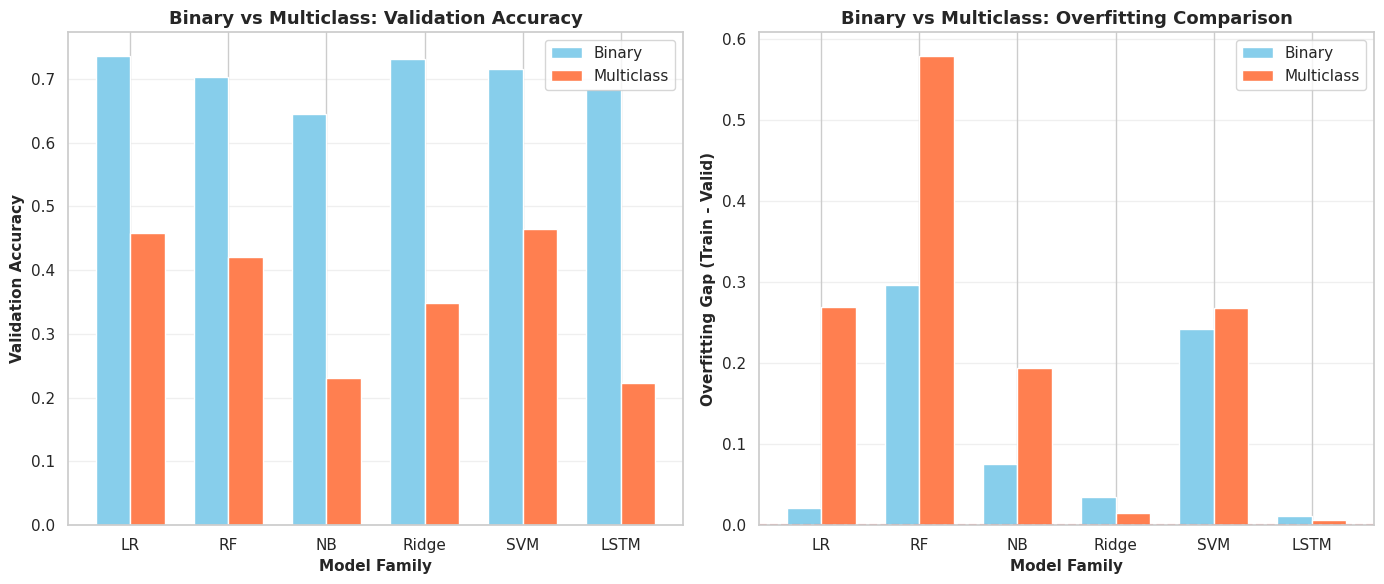


[Section 4] Per-Class Performance Analysis (Multiclass Models)...


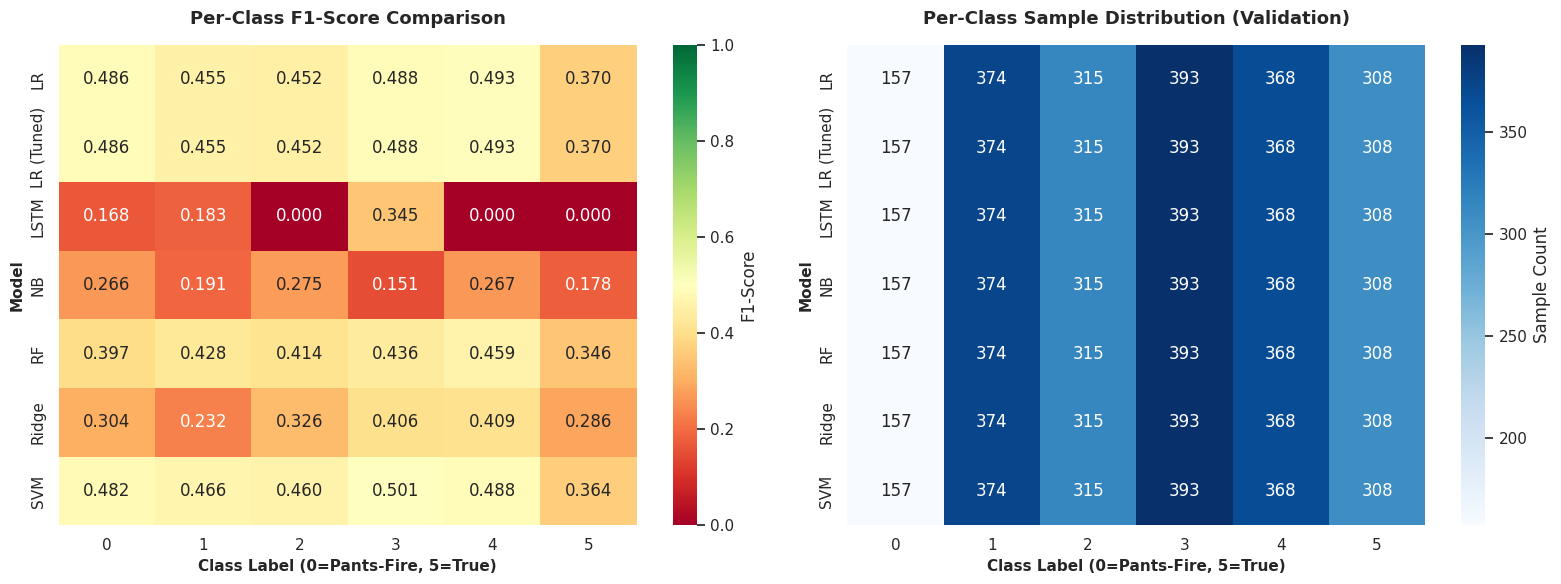


BEST MODEL PER CLASS (by F1-Score)
  Class 0: LR (F1=0.4863)
  Class 1: SVM (F1=0.4661)
  Class 2: SVM (F1=0.4604)
  Class 3: SVM (F1=0.5013)
  Class 4: LR (F1=0.4928)
  Class 5: LR (F1=0.3704)

[Section 5] Resource Usage & Efficiency Analysis...


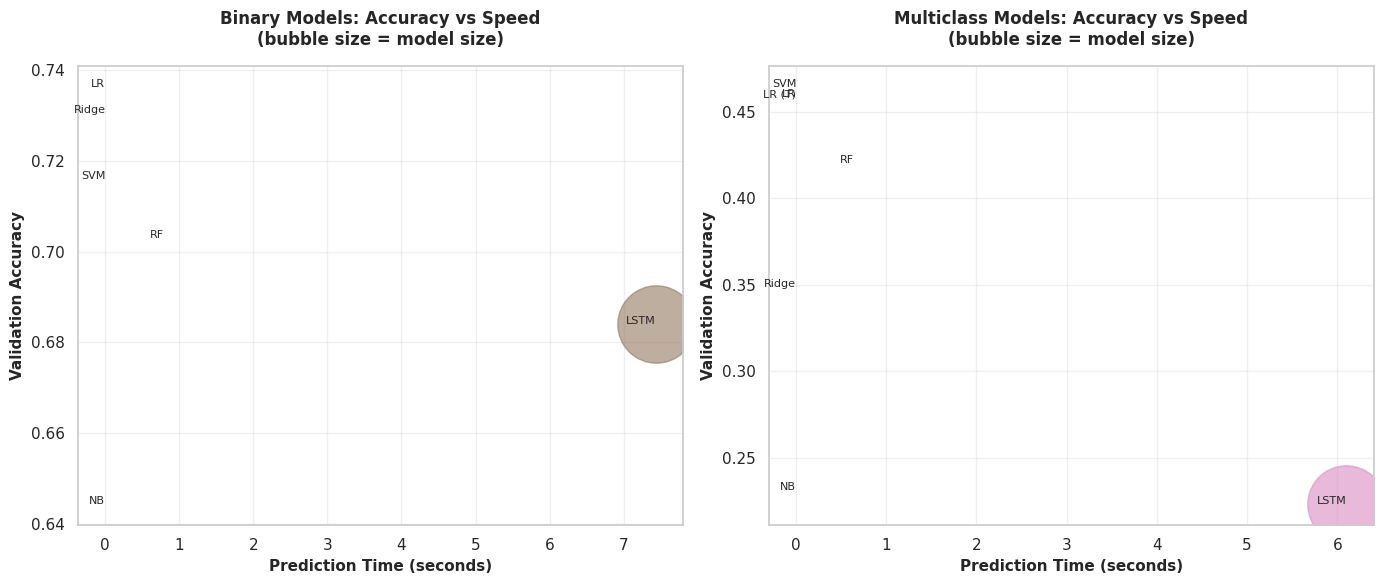


RESOURCE USAGE COMPARISON
       Model  Pred Time (s)  Model Size (MB)
   LR_Binary       0.001094          0.00000
  SVM_6Class       0.001501          0.00000
  SVM_Binary       0.001503          0.00000
   NB_6Class       0.001530          0.00000
   NB_Binary       0.001675          0.00000
   LR_6Class       0.002586          0.00000
 LR_Improved       0.002855          0.00000
Ridge_6Class       0.003243          0.00000
Ridge_Binary       0.006551          0.00000
   RF_6Class       0.641971          0.00000
   RF_Binary       0.791587          0.00000
 LSTM_6Class       6.101768         31.05294
 LSTM_Binary       7.429551         31.04213

[Section 6] Error Analysis & Confusion Matrices...


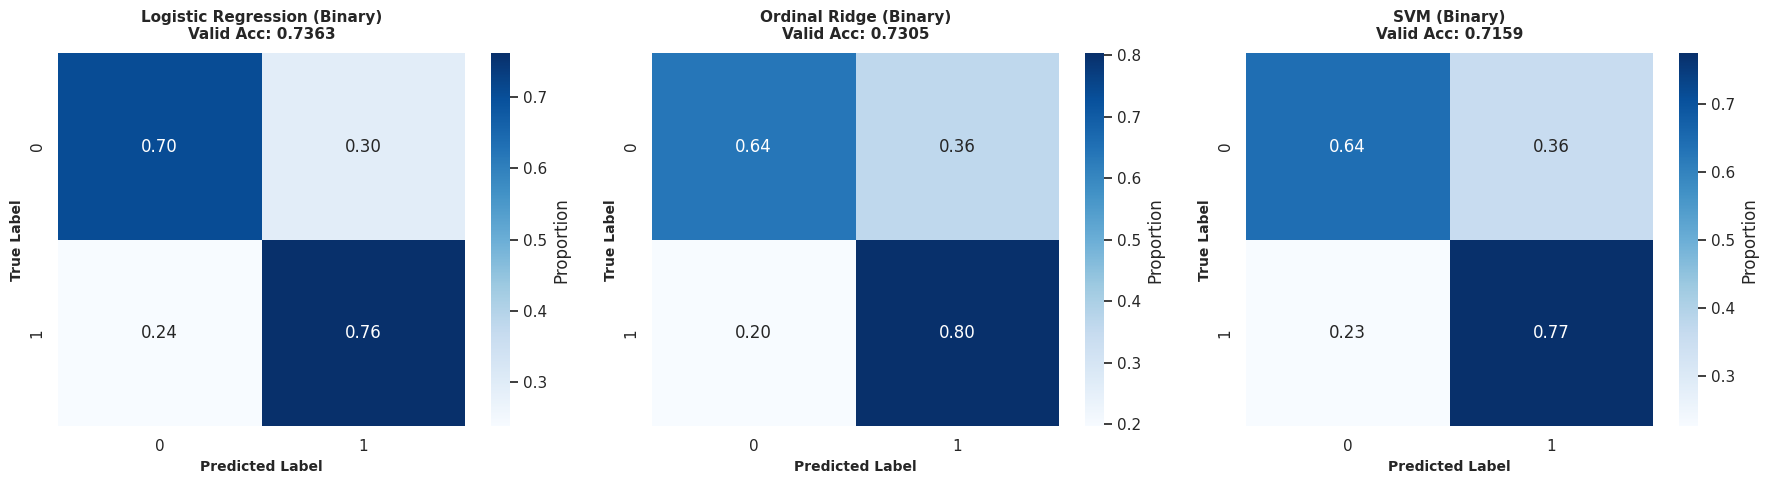


FINAL MODEL RECOMMENDATION

FINAL MODEL RANKING (by Composite Score):
       Model                   Description       Type  Valid Acc  Test Acc  F1 Score  Pred Time (s)  Composite Score
   LR_Binary  Logistic Regression (Binary)     binary   0.736292  0.736292  0.763244       0.001094         0.989914
Ridge_Binary        Ordinal Ridge (Binary)     binary   0.730548  0.746214  0.769024       0.006551         0.989102
  SVM_Binary                  SVM (Binary)     binary   0.715927  0.725849  0.752727       0.001503         0.912823
   RF_Binary        Random Forest (Binary)     binary   0.702872  0.701828  0.748564       0.791587         0.867678
   NB_Binary          Naive Bayes (Binary)     binary   0.644386  0.661097  0.645497       0.001675         0.858709
 LSTM_Binary                 LSTM (Binary)     binary   0.684073  0.690339  0.685714       7.429551         0.771944
  SVM_6Class           SVM (Tuned 6-Class) multiclass   0.464752  0.470496  0.461536       0.001501         0.

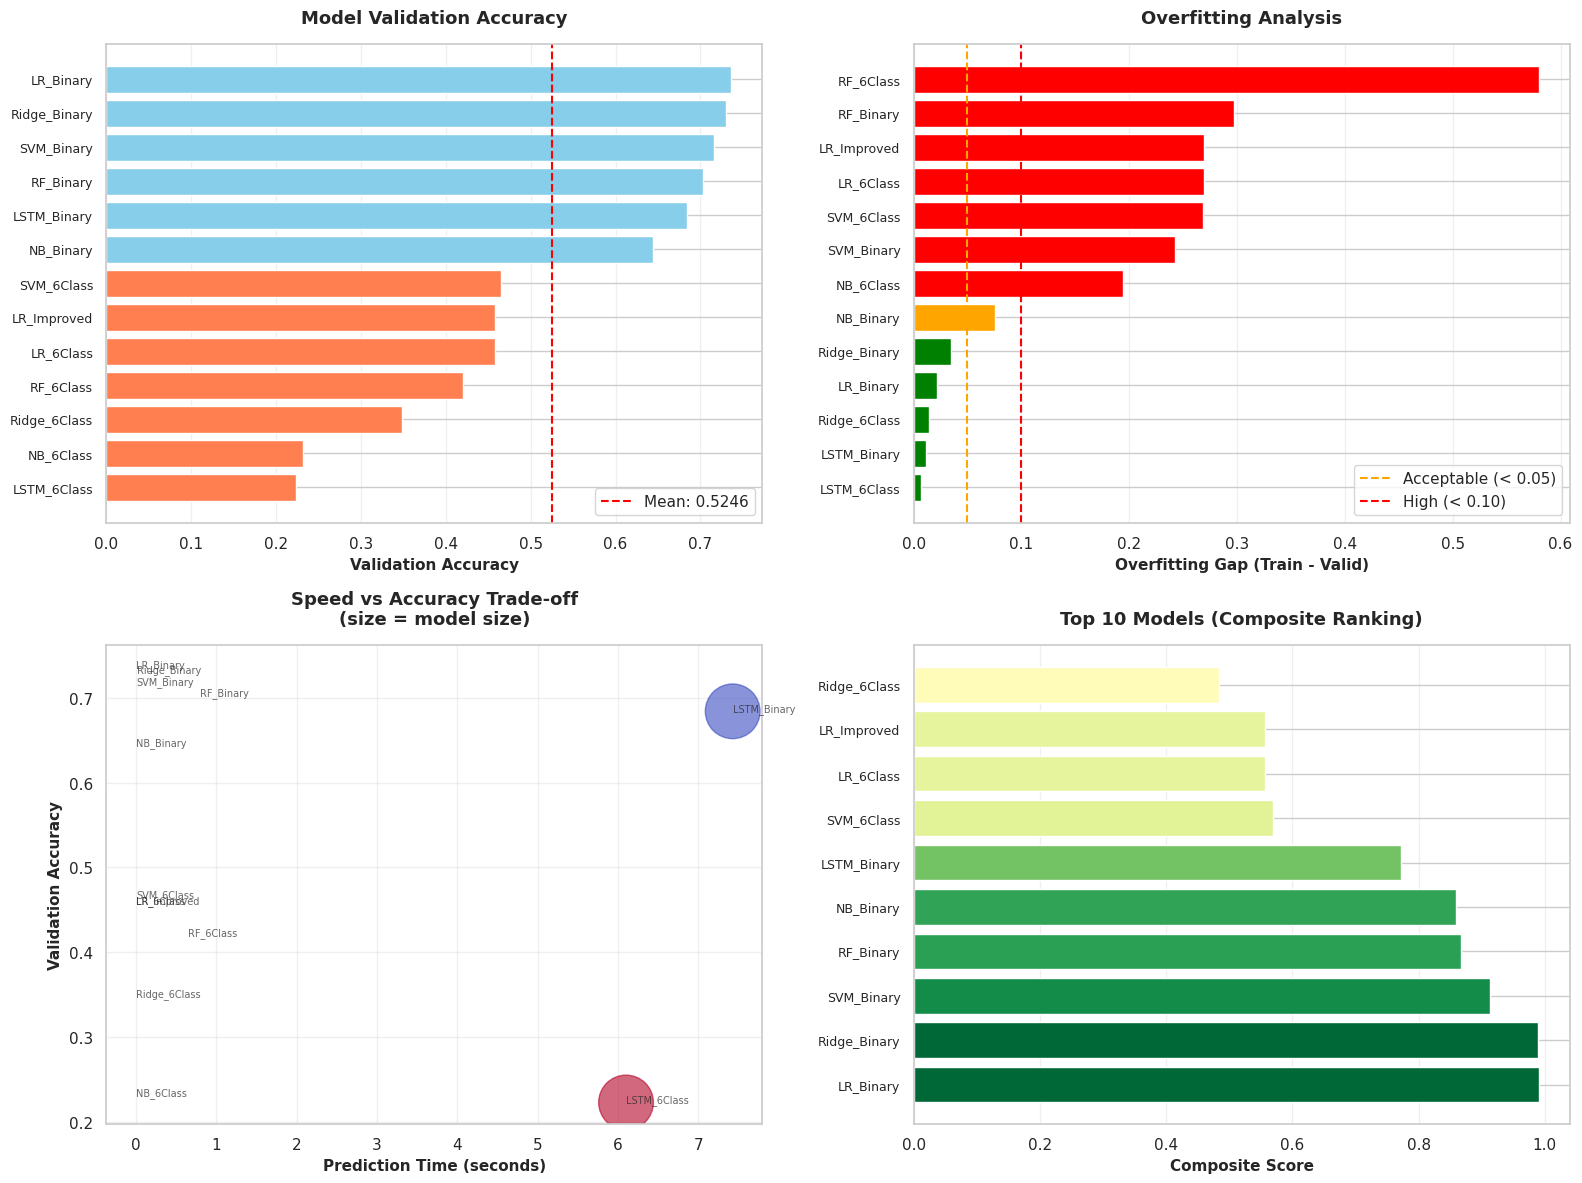


COMPARISON PIPELINE COMPLETE

Generated Files:
  ✓ comprehensive_model_metrics.csv
  ✓ final_model_ranking.csv
  ✓ comparison_binary_vs_multiclass.png
  ✓ comparison_per_class_performance.png
  ✓ comparison_efficiency_analysis.png
  ✓ comparison_confusion_matrices_top3.png
  ✓ comparison_overall_dashboard.png

KEY INSIGHTS

1. PERFORMANCE:
   - Highest validation accuracy: 0.7363 (Logistic Regression (Binary))
   - Highest test accuracy: 0.7462 (Ordinal Ridge (Binary))
   - Best F1 Score: 0.7690 (Ordinal Ridge (Binary))

2. EFFICIENCY:
   - Fastest prediction: 0.0011s (Logistic Regression (Binary))
   - Smallest model: 0.00MB (Logistic Regression (Binary))

3. GENERALIZATION:
   - Best generalization (lowest overfit): 0.0066 (LSTM (Tuned 6-Class))
   - Models with overfit > 0.10: 7

4. BINARY vs MULTICLASS:
   - Average binary accuracy: 0.7023
   - Average multiclass accuracy: 0.3722
   - Difference: 0.3302



In [86]:
"""
COMPREHENSIVE MODEL COMPARISON & EVALUATION PIPELINE
Compares all models (binary, multiclass, tuned) across:
- Performance metrics
- Training time & resource usage
- Overfitting analysis
- Per-class performance
- Error analysis
"""

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_auc_score,
                            roc_curve, mean_absolute_error)
from sklearn.model_selection import learning_curve

# Set style for all visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("\n" + "=" * 80)
print(" " * 25 + "MODEL COMPARISON PIPELINE")
print("=" * 80)

# ==================== SECTION 1: LOAD ALL MODELS AND DATA ====================
print("\n[Section 1] Loading Models and Data...")

# Load data for different model types
lr_data = joblib.load('logistic_regression_data.pkl')
rf_data = joblib.load('random_forest_data.pkl')
nb_data = joblib.load('naive_bayes_data.pkl')
ordinal_data = joblib.load('ordinal_ridge_data.pkl')
svm_data = joblib.load('svm_data.pkl')
lstm_data = joblib.load('lstm_data.pkl')

# Binary labels conversion
def to_binary(y):
    return (y >= 3).astype(int)

# Model registry with metadata
models_registry = {
    # Logistic Regression Models
    'LR_Binary': {
        'path': 'model_lr_binary.pkl',
        'type': 'binary',
        'data': lr_data,
        'description': 'Logistic Regression (Binary)'
    },
    'LR_6Class': {
        'path': 'model_lr_baseline.pkl',
        'type': 'multiclass',
        'data': lr_data,
        'description': 'Logistic Regression (6-Class)'
    },
    'LR_Improved': {
        'path': 'model_lr_improved.pkl',
        'type': 'multiclass',
        'data': lr_data,
        'description': 'Logistic Regression (Tuned)'
    },

    # Random Forest Models
    'RF_Binary': {
        'path': 'model_rf_binary.pkl',
        'type': 'binary',
        'data': rf_data,
        'description': 'Random Forest (Binary)'
    },
    'RF_6Class': {
        'path': 'model_rf_6class.pkl',
        'type': 'multiclass',
        'data': rf_data,
        'description': 'Random Forest (6-Class)'
    },

    # Naive Bayes Models
    'NB_Binary': {
        'path': 'model_nb_binary.pkl',
        'type': 'binary',
        'data': nb_data,
        'description': 'Naive Bayes (Binary)'
    },
    'NB_6Class': {
        'path': 'model_nb_best.pkl',
        'type': 'multiclass',
        'data': nb_data,
        'description': 'Naive Bayes (6-Class)'
    },

    # Ridge Models
    'Ridge_Binary': {
        'path': 'model_ordinal_ridge_binary.pkl',
        'type': 'binary',
        'data': ordinal_data,
        'description': 'Ordinal Ridge (Binary)',
        'special': 'ridge_binary'
    },
    'Ridge_6Class': {
        'path': 'model_ordinal_ridge_best.pkl',
        'type': 'multiclass',
        'data': ordinal_data,
        'description': 'Ordinal Ridge (6-Class)',
        'special': 'ridge_multiclass'
    },

    # SVM Models
    'SVM_Binary': {
        'path': 'model_svm_binary.pkl',
        'type': 'binary',
        'data': svm_data,
        'description': 'SVM (Binary)'
    },
    'SVM_6Class': {
        'path': 'model_svm_best_tuned.pkl',
        'type': 'multiclass',
        'data': svm_data,
        'description': 'SVM (Tuned 6-Class)'
    },

    # LSTM Models
    'LSTM_Binary': {
        'path': 'model_lstm_binary.h5',
        'type': 'binary',
        'data': lstm_data,
        'description': 'LSTM (Binary)',
        'special': 'lstm'
    },
    'LSTM_6Class': {
        'path': 'model_lstm_best.h5',
        'type': 'multiclass',
        'data': lstm_data,
        'description': 'LSTM (Tuned 6-Class)',
        'special': 'lstm'
    }
}

# Load all models
loaded_models = {}
for name, info in models_registry.items():
    try:
        if info.get('special') == 'lstm':
            from tensorflow.keras.models import load_model
            loaded_models[name] = load_model(info['path'])
        else:
            loaded_models[name] = joblib.load(info['path'])
        print(f"  ✓ Loaded {name}")
    except FileNotFoundError:
        print(f"  ⚠ Model not found: {name}")

print(f"\n  Total models loaded: {len(loaded_models)}")

# ==================== SECTION 2: PREDICTION FUNCTION ====================

def get_predictions(model_name, model, model_info):
    """
    Get predictions for train, validation, and test sets
    Handles different model types appropriately
    """
    data = model_info['data']
    model_type = model_info['type']
    special = model_info.get('special')

    # Get appropriate data
    if special == 'lstm':
        X_train = [data['X_train_text'], data['X_train_meta']]
        X_valid = [data['X_valid_text'], data['X_valid_meta']]
        X_test = [data['X_test_text'], data['X_test_meta']]
    else:
        X_train = data['X_train']
        X_valid = data['X_valid']
        X_test = data['X_test']

    y_train = data['y_train']
    y_valid = data['y_valid']
    y_test = data['y_test']

    # Convert to binary if needed
    if model_type == 'binary':
        y_train = to_binary(y_train)
        y_valid = to_binary(y_valid)
        y_test = to_binary(y_test)

    # Get predictions based on model type
    if special == 'lstm':
        if model_type == 'binary':
            y_train_pred = (model.predict(X_train, verbose=0) > 0.5).astype(int).squeeze()
            y_valid_pred = (model.predict(X_valid, verbose=0) > 0.5).astype(int).squeeze()
            y_test_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).squeeze()
        else:
            y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
            y_valid_pred = np.argmax(model.predict(X_valid, verbose=0), axis=1)
            y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    elif special == 'ridge_binary':
        # Load threshold for binary ridge
        meta = joblib.load('model_ordinal_ridge_binary_meta.pkl')
        threshold = meta['threshold']
        y_train_pred = (model.predict(X_train) >= threshold).astype(int)
        y_valid_pred = (model.predict(X_valid) >= threshold).astype(int)
        y_test_pred = (model.predict(X_test) >= threshold).astype(int)

    elif special == 'ridge_multiclass':
        # Round and clip for ordinal ridge
        y_train_pred = np.clip(np.round(model.predict(X_train)), 0, 5).astype(int)
        y_valid_pred = np.clip(np.round(model.predict(X_valid)), 0, 5).astype(int)
        y_test_pred = np.clip(np.round(model.predict(X_test)), 0, 5).astype(int)

    else:
        # Standard sklearn models
        y_train_pred = model.predict(X_train)
        y_valid_pred = model.predict(X_valid)
        y_test_pred = model.predict(X_test)

    return y_train, y_valid, y_test, y_train_pred, y_valid_pred, y_test_pred

# ==================== SECTION 3: COMPREHENSIVE METRICS CALCULATION ====================
print("\n[Section 2] Calculating Comprehensive Metrics...")

all_metrics = []

for model_name, model in loaded_models.items():
    print(f"\n  Evaluating {model_name}...")
    model_info = models_registry[model_name]

    # Get predictions
    y_train, y_valid, y_test, y_train_pred, y_valid_pred, y_test_pred = \
        get_predictions(model_name, model, model_info)

    # Basic metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    valid_acc = accuracy_score(y_valid, y_valid_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Overfitting gap
    overfit_gap = train_acc - valid_acc

    # Model size (approximate)
    try:
        if model_info.get('special') == 'lstm':
            model_size_mb = Path(model_info['path']).stat().st_size / (1024 * 1024)
        else:
            model_size_mb = sys.getsizeof(joblib.dumps(model)) / (1024 * 1024)
    except:
        model_size_mb = 0.0

    # Calculate precision, recall, F1 with proper average parameter
    if model_info['type'] == 'binary':
        # Binary classification - no average parameter needed
        precision = precision_score(y_valid, y_valid_pred, zero_division=0)
        recall = recall_score(y_valid, y_valid_pred, zero_division=0)
        f1 = f1_score(y_valid, y_valid_pred, zero_division=0)
    else:
        # Multiclass - use weighted average
        precision = precision_score(y_valid, y_valid_pred, average='weighted', zero_division=0)
        recall = recall_score(y_valid, y_valid_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_valid, y_valid_pred, average='weighted', zero_division=0)

    # MAE for ordinal evaluation
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    # Measure prediction time
    start_time = time.time()
    if model_info.get('special') == 'lstm':
        _ = model.predict([model_info['data']['X_test_text'], model_info['data']['X_test_meta']], verbose=0)
    else:
        _ = model.predict(model_info['data']['X_test'])
    pred_time = time.time() - start_time

    all_metrics.append({
        'Model': model_name,
        'Description': model_info['description'],
        'Type': model_info['type'],
        'Train Acc': train_acc,
        'Valid Acc': valid_acc,
        'Test Acc': test_acc,
        'Overfit Gap': overfit_gap,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'MAE Valid': mae_valid,
        'MAE Test': mae_test,
        'Pred Time (s)': pred_time,
        'Model Size (MB)': model_size_mb
    })

# Create DataFrame
metrics_df = pd.DataFrame(all_metrics)

print("\n" + "=" * 80)
print("PERFORMANCE METRICS SUMMARY")
print("=" * 80)
print(metrics_df.to_string(index=False))

# Save metrics
metrics_df.to_csv('comprehensive_model_metrics.csv', index=False)
print("\n✓ Saved metrics to: comprehensive_model_metrics.csv")

# ==================== SECTION 4: BINARY VS MULTICLASS COMPARISON ====================
print("\n[Section 3] Binary vs Multiclass Comparison...")

# Separate binary and multiclass
binary_metrics = metrics_df[metrics_df['Type'] == 'binary'].copy()
multiclass_metrics = metrics_df[metrics_df['Type'] == 'multiclass'].copy()

# Extract model family
binary_metrics['Family'] = binary_metrics['Model'].str.split('_').str[0]
multiclass_metrics['Family'] = multiclass_metrics['Model'].str.split('_').str[0]

# Compare within families
comparison_data = []
for family in binary_metrics['Family'].unique():
    bin_row = binary_metrics[binary_metrics['Family'] == family]
    multi_row = multiclass_metrics[multiclass_metrics['Family'] == family]

    if not bin_row.empty and not multi_row.empty:
        comparison_data.append({
            'Model Family': family,
            'Binary Valid Acc': bin_row['Valid Acc'].values[0],
            'Multiclass Valid Acc': multi_row['Valid Acc'].values[0],
            'Binary Test Acc': bin_row['Test Acc'].values[0],
            'Multiclass Test Acc': multi_row['Test Acc'].values[0],
            'Binary Overfit': bin_row['Overfit Gap'].values[0],
            'Multiclass Overfit': multi_row['Overfit Gap'].values[0],
            'Binary Pred Time': bin_row['Pred Time (s)'].values[0],
            'Multiclass Pred Time': multi_row['Pred Time (s)'].values[0]
        })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 80)
print("BINARY vs MULTICLASS COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Visualization: Binary vs Multiclass Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Validation Accuracy Comparison
ax = axes[0]
x = np.arange(len(comparison_df))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['Binary Valid Acc'], width, label='Binary', color='skyblue')
bars2 = ax.bar(x + width/2, comparison_df['Multiclass Valid Acc'], width, label='Multiclass', color='coral')
ax.set_xlabel('Model Family', fontsize=11, weight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=11, weight='bold')
ax.set_title('Binary vs Multiclass: Validation Accuracy', fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model Family'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Overfitting Gap Comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, comparison_df['Binary Overfit'], width, label='Binary', color='skyblue')
bars2 = ax.bar(x + width/2, comparison_df['Multiclass Overfit'], width, label='Multiclass', color='coral')
ax.set_xlabel('Model Family', fontsize=11, weight='bold')
ax.set_ylabel('Overfitting Gap (Train - Valid)', fontsize=11, weight='bold')
ax.set_title('Binary vs Multiclass: Overfitting Comparison', fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model Family'])
ax.legend()
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_binary_vs_multiclass.png', dpi=100, bbox_inches='tight')
plt.show()

# ==================== SECTION 5: PER-CLASS PERFORMANCE ANALYSIS ====================
print("\n[Section 4] Per-Class Performance Analysis (Multiclass Models)...")

# Analyze per-class performance for multiclass models
per_class_results = []

for model_name in multiclass_metrics['Model']:
    model = loaded_models[model_name]
    model_info = models_registry[model_name]

    y_train, y_valid, y_test, y_train_pred, y_valid_pred, y_test_pred = \
        get_predictions(model_name, model, model_info)

    # Classification report
    report = classification_report(y_valid, y_valid_pred, output_dict=True, zero_division=0)

    # Extract per-class metrics
    for class_label in range(6):
        class_label_str = str(class_label)
        if class_label_str in report:
            per_class_results.append({
                'Model': model_name.replace('_6Class', '').replace('_Improved', ' (Tuned)'),
                'Class': class_label,
                'Precision': report[class_label_str]['precision'],
                'Recall': report[class_label_str]['recall'],
                'F1-Score': report[class_label_str]['f1-score'],
                'Support': report[class_label_str]['support']
            })

per_class_df = pd.DataFrame(per_class_results)

# Visualization: F1-Score Heatmap
pivot_f1 = per_class_df.pivot(index='Model', columns='Class', values='F1-Score')
pivot_support = per_class_df.pivot(index='Model', columns='Class', values='Support')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-Score Heatmap
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
            cbar_kws={'label': 'F1-Score'}, vmin=0, vmax=1)
axes[0].set_title('Per-Class F1-Score Comparison', fontsize=13, weight='bold', pad=15)
axes[0].set_xlabel('Class Label (0=Pants-Fire, 5=True)', fontsize=11, weight='bold')
axes[0].set_ylabel('Model', fontsize=11, weight='bold')

# Support (sample count) Heatmap
sns.heatmap(pivot_support, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Sample Count'})
axes[1].set_title('Per-Class Sample Distribution (Validation)', fontsize=13, weight='bold', pad=15)
axes[1].set_xlabel('Class Label (0=Pants-Fire, 5=True)', fontsize=11, weight='bold')
axes[1].set_ylabel('Model', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('comparison_per_class_performance.png', dpi=100, bbox_inches='tight')
plt.show()

# Identify best performing model per class
print("\n" + "=" * 80)
print("BEST MODEL PER CLASS (by F1-Score)")
print("=" * 80)
for class_label in range(6):
    class_data = per_class_df[per_class_df['Class'] == class_label]
    best_model = class_data.loc[class_data['F1-Score'].idxmax(), 'Model']
    best_f1 = class_data['F1-Score'].max()
    print(f"  Class {class_label}: {best_model} (F1={best_f1:.4f})")

# ==================== SECTION 6: RESOURCE USAGE & EFFICIENCY ====================
print("\n[Section 5] Resource Usage & Efficiency Analysis...")

# Visualization: Efficiency Scatter Plot (Accuracy vs Speed)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Binary Models
ax = axes[0]
for idx, row in binary_metrics.iterrows():
    ax.scatter(row['Pred Time (s)'], row['Valid Acc'], s=row['Model Size (MB)']*100,
              alpha=0.6, label=row['Model'].replace('_Binary', ''))
    ax.annotate(row['Model'].replace('_Binary', ''),
               (row['Pred Time (s)'], row['Valid Acc']),
               fontsize=8, ha='right')
ax.set_xlabel('Prediction Time (seconds)', fontsize=11, weight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=11, weight='bold')
ax.set_title('Binary Models: Accuracy vs Speed\n(bubble size = model size)',
            fontsize=12, weight='bold', pad=15)
ax.grid(alpha=0.3)

# Multiclass Models
ax = axes[1]
for idx, row in multiclass_metrics.iterrows():
    ax.scatter(row['Pred Time (s)'], row['Valid Acc'], s=row['Model Size (MB)']*100,
              alpha=0.6, label=row['Model'].replace('_6Class', '').replace('_Improved', ' (T)'))
    ax.annotate(row['Model'].replace('_6Class', '').replace('_Improved', ' (T)'),
               (row['Pred Time (s)'], row['Valid Acc']),
               fontsize=8, ha='right')
ax.set_xlabel('Prediction Time (seconds)', fontsize=11, weight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=11, weight='bold')
ax.set_title('Multiclass Models: Accuracy vs Speed\n(bubble size = model size)',
            fontsize=12, weight='bold', pad=15)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_efficiency_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Resource usage table
print("\n" + "=" * 80)
print("RESOURCE USAGE COMPARISON")
print("=" * 80)
resource_df = metrics_df[['Model', 'Pred Time (s)', 'Model Size (MB)']].copy()
resource_df = resource_df.sort_values('Pred Time (s)')
print(resource_df.to_string(index=False))

# ==================== SECTION 7: ERROR ANALYSIS ====================
print("\n[Section 6] Error Analysis & Confusion Matrices...")

# Create confusion matrices for top 3 models
top_3_models = metrics_df.nlargest(3, 'Valid Acc')['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_3_models):
    model = loaded_models[model_name]
    model_info = models_registry[model_name]

    y_train, y_valid, y_test, y_train_pred, y_valid_pred, y_test_pred = \
        get_predictions(model_name, model, model_info)

    cm = confusion_matrix(y_valid, y_valid_pred)

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    ax = axes[idx]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=ax,
               cbar_kws={'label': 'Proportion'})
    ax.set_title(f'{model_info["description"]}\nValid Acc: {metrics_df[metrics_df["Model"]==model_name]["Valid Acc"].values[0]:.4f}',
                fontsize=11, weight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10, weight='bold')
    ax.set_ylabel('True Label', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('comparison_confusion_matrices_top3.png', dpi=100, bbox_inches='tight')
plt.show()

# ==================== SECTION 8: FINAL RECOMMENDATION ====================
print("\n" + "=" * 80)
print("FINAL MODEL RECOMMENDATION")
print("=" * 80)

# Define scoring criteria (weighted importance)
weights = {
    'Valid Acc': 0.30,
    'Test Acc': 0.25,
    'Overfit Gap': -0.15,  # Negative because lower is better
    'F1 Score': 0.15,
    'Pred Time (s)': -0.10,  # Negative because lower is better
    'Model Size (MB)': -0.05  # Negative because lower is better
}

# Normalize metrics for scoring
normalized_df = metrics_df.copy()
for col in weights.keys():
    if col in normalized_df.columns:
        col_data = normalized_df[col]
        # For negative weights, we want to minimize the value
        if weights[col] < 0:
            normalized_df[col + '_norm'] = (col_data.max() - col_data) / (col_data.max() - col_data.min() + 1e-10)
        else:
            normalized_df[col + '_norm'] = (col_data - col_data.min()) / (col_data.max() - col_data.min() + 1e-10)

# Calculate composite score
normalized_df['Composite Score'] = 0
for col, weight in weights.items():
    if col in metrics_df.columns:
        normalized_df['Composite Score'] += abs(weight) * normalized_df[col + '_norm']

# Rank models
final_ranking = normalized_df[['Model', 'Description', 'Type', 'Valid Acc', 'Test Acc',
                               'F1 Score', 'Pred Time (s)', 'Composite Score']].copy()
final_ranking = final_ranking.sort_values('Composite Score', ascending=False)

print("\nFINAL MODEL RANKING (by Composite Score):")
print(final_ranking.to_string(index=False))

# Best models
best_overall = final_ranking.iloc[0]
best_binary = final_ranking[final_ranking['Type'] == 'binary'].iloc[0]
best_multiclass = final_ranking[final_ranking['Type'] == 'multiclass'].iloc[0]

print("\n" + "=" * 80)
print("🏆 RECOMMENDED MODELS")
print("=" * 80)
print(f"\nBEST OVERALL:")
print(f"  Model: {best_overall['Description']}")
print(f"  Validation Accuracy: {best_overall['Valid Acc']:.4f}")
print(f"  Test Accuracy: {best_overall['Test Acc']:.4f}")
print(f"  F1 Score: {best_overall['F1 Score']:.4f}")
print(f"  Prediction Time: {best_overall['Pred Time (s)']:.4f}s")
print(f"  Composite Score: {best_overall['Composite Score']:.4f}")

print(f"\nBEST BINARY MODEL:")
print(f"  Model: {best_binary['Description']}")
print(f"  Validation Accuracy: {best_binary['Valid Acc']:.4f}")
print(f"  Test Accuracy: {best_binary['Test Acc']:.4f}")

print(f"\nBEST MULTICLASS MODEL:")
print(f"  Model: {best_multiclass['Description']}")
print(f"  Validation Accuracy: {best_multiclass['Valid Acc']:.4f}")
print(f"  Test Accuracy: {best_multiclass['Test Acc']:.4f}")

# Save final ranking
final_ranking.to_csv('final_model_ranking.csv', index=False)
print("\n✓ Saved final ranking to: final_model_ranking.csv")

# Visualization: Overall Comparison Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Validation Accuracy Comparison
ax = axes[0, 0]
sorted_metrics = metrics_df.sort_values('Valid Acc', ascending=True)
colors = ['skyblue' if t == 'binary' else 'coral' for t in sorted_metrics['Type']]
bars = ax.barh(range(len(sorted_metrics)), sorted_metrics['Valid Acc'], color=colors)
ax.set_yticks(range(len(sorted_metrics)))
ax.set_yticklabels(sorted_metrics['Model'], fontsize=9)
ax.set_xlabel('Validation Accuracy', fontsize=11, weight='bold')
ax.set_title('Model Validation Accuracy', fontsize=13, weight='bold', pad=15)
ax.axvline(x=sorted_metrics['Valid Acc'].mean(), color='red', linestyle='--',
          label=f'Mean: {sorted_metrics["Valid Acc"].mean():.4f}')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# 2. Overfitting Gap Analysis
ax = axes[0, 1]
sorted_overfit = metrics_df.sort_values('Overfit Gap')
colors = ['green' if gap < 0.05 else 'orange' if gap < 0.10 else 'red'
         for gap in sorted_overfit['Overfit Gap']]
ax.barh(range(len(sorted_overfit)), sorted_overfit['Overfit Gap'], color=colors)
ax.set_yticks(range(len(sorted_overfit)))
ax.set_yticklabels(sorted_overfit['Model'], fontsize=9)
ax.set_xlabel('Overfitting Gap (Train - Valid)', fontsize=11, weight='bold')
ax.set_title('Overfitting Analysis', fontsize=13, weight='bold', pad=15)
ax.axvline(x=0.05, color='orange', linestyle='--', label='Acceptable (< 0.05)')
ax.axvline(x=0.10, color='red', linestyle='--', label='High (< 0.10)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# 3. Speed vs Accuracy Trade-off
ax = axes[1, 0]
scatter = ax.scatter(metrics_df['Pred Time (s)'], metrics_df['Valid Acc'],
                    s=metrics_df['Model Size (MB)']*50, alpha=0.6,
                    c=metrics_df['Type'].map({'binary': 0, 'multiclass': 1}),
                    cmap='coolwarm')
for idx, row in metrics_df.iterrows():
    ax.annotate(row['Model'], (row['Pred Time (s)'], row['Valid Acc']),
               fontsize=7, alpha=0.7)
ax.set_xlabel('Prediction Time (seconds)', fontsize=11, weight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=11, weight='bold')
ax.set_title('Speed vs Accuracy Trade-off\n(size = model size)',
            fontsize=13, weight='bold', pad=15)
ax.grid(alpha=0.3)

# 4. Composite Score Ranking
ax = axes[1, 1]
top_10 = final_ranking.head(10)
colors_score = plt.cm.RdYlGn(top_10['Composite Score'] / top_10['Composite Score'].max())
bars = ax.barh(range(len(top_10)), top_10['Composite Score'], color=colors_score)
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Model'], fontsize=9)
ax.set_xlabel('Composite Score', fontsize=11, weight='bold')
ax.set_title('Top 10 Models (Composite Ranking)', fontsize=13, weight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_overall_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("COMPARISON PIPELINE COMPLETE")
print("=" * 80)
print("\nGenerated Files:")
print("  ✓ comprehensive_model_metrics.csv")
print("  ✓ final_model_ranking.csv")
print("  ✓ comparison_binary_vs_multiclass.png")
print("  ✓ comparison_per_class_performance.png")
print("  ✓ comparison_efficiency_analysis.png")
print("  ✓ comparison_confusion_matrices_top3.png")
print("  ✓ comparison_overall_dashboard.png")

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Generate insights
print(f"\n1. PERFORMANCE:")
print(f"   - Highest validation accuracy: {metrics_df['Valid Acc'].max():.4f} ({metrics_df.loc[metrics_df['Valid Acc'].idxmax(), 'Description']})")
print(f"   - Highest test accuracy: {metrics_df['Test Acc'].max():.4f} ({metrics_df.loc[metrics_df['Test Acc'].idxmax(), 'Description']})")
print(f"   - Best F1 Score: {metrics_df['F1 Score'].max():.4f} ({metrics_df.loc[metrics_df['F1 Score'].idxmax(), 'Description']})")

print(f"\n2. EFFICIENCY:")
print(f"   - Fastest prediction: {metrics_df['Pred Time (s)'].min():.4f}s ({metrics_df.loc[metrics_df['Pred Time (s)'].idxmin(), 'Description']})")
print(f"   - Smallest model: {metrics_df['Model Size (MB)'].min():.2f}MB ({metrics_df.loc[metrics_df['Model Size (MB)'].idxmin(), 'Description']})")

print(f"\n3. GENERALIZATION:")
print(f"   - Best generalization (lowest overfit): {metrics_df['Overfit Gap'].min():.4f} ({metrics_df.loc[metrics_df['Overfit Gap'].idxmin(), 'Description']})")
print(f"   - Models with overfit > 0.10: {len(metrics_df[metrics_df['Overfit Gap'] > 0.10])}")

print(f"\n4. BINARY vs MULTICLASS:")
avg_binary = binary_metrics['Valid Acc'].mean()
avg_multi = multiclass_metrics['Valid Acc'].mean()
print(f"   - Average binary accuracy: {avg_binary:.4f}")
print(f"   - Average multiclass accuracy: {avg_multi:.4f}")
print(f"   - Difference: {abs(avg_binary - avg_multi):.4f}")

print("\n" + "=" * 80)